# WildChat Exploratory Data Analysis - Part II

**Purpose:** Jupyter notebook for exploring research questions aligned with Phronos's research agenda  
**Dataset:** WildChat (4.7M conversations, April 2023 – July 2025)  
**Output:** Findings for potential DSP-002 dispatch

---

## Contents

1. **What Predicts Return?** - First-turn features that distinguish returning users from one-shot users
2. **Power User Phenotyping** - Characterizing the top 1% who generate 50% of content
3. **First-Turn Typology** - Classifying cognitive tasks being delegated to AI
4. **The One-Shot Population** - Understanding the 80% who never return
5. **Temporal Drift** - How prompting behavior has changed over time
6. **The Two-Turn Dance** - Analyzing the 80% of conversations that are exactly 2 turns

---

## Dataset Characteristics

Key skews to account for:
- **80% of conversations are 2 turns** (1 user prompt, 1 AI response)
- **Top 1% of users contribute 50% of content**
- **76 languages** (English dominant)
- **Multiple model versions** over time period

**Note:** Text-based analyses use 10 data shards (~370K conversations) sampled across the full date range. Aggregate metrics use the full 4.7M dataset.


In [1]:
# ============================================================
# Setup & Brand Configuration
# ============================================================

import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import os
import re

# Create output directory
os.makedirs('../outputs/figures', exist_ok=True)

# =============================================================================
# PHRONOS BRAND COLORS (Light Mode)
# =============================================================================
BRAND = {
    'paper': '#F2F0E9',           # Primary background
    'ink': '#1A1A1A',             # Primary text/axes
    'gold': '#B08D55',            # Accent, highlights, signal
    'gold_dim': 'rgba(176, 141, 85, 0.12)',
    'faded': 'rgba(26, 26, 26, 0.5)',      # Secondary text
    'faded_light': 'rgba(26, 26, 26, 0.08)', # Borders, dividers
    'white': '#FFFFFF',           # Card backgrounds
    'alert': '#CC5544',           # Critical, errors (used for toxic)
    'success': '#44AA77',         # Positive states
}

# Convert rgba strings to matplotlib-compatible format
def rgba_to_tuple(rgba_str):
    """Convert 'rgba(r,g,b,a)' string to matplotlib tuple."""
    match = re.match(r'rgba\((\d+),\s*(\d+),\s*(\d+),\s*([\d.]+)\)', rgba_str)
    if match:
        r, g, b, a = match.groups()
        return (int(r)/255, int(g)/255, int(b)/255, float(a))
    return rgba_str

FADED = rgba_to_tuple('rgba(26, 26, 26, 0.5)')
FADED_LIGHT = rgba_to_tuple('rgba(26, 26, 26, 0.08)')

# =============================================================================
# MATPLOTLIB CONFIGURATION
# =============================================================================
plt.rcParams.update({
    # Figure
    'figure.facecolor': BRAND['paper'],
    'figure.edgecolor': BRAND['ink'],
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.facecolor': BRAND['paper'],
    'savefig.edgecolor': 'none',
    
    # Axes
    'axes.facecolor': BRAND['paper'],
    'axes.edgecolor': BRAND['ink'],
    'axes.labelcolor': BRAND['ink'],
    'axes.titlecolor': BRAND['ink'],
    'axes.linewidth': 1.0,
    'axes.grid': True,
    'axes.axisbelow': True,
    
    # Grid
    'grid.color': FADED_LIGHT,
    'grid.linewidth': 0.5,
    'grid.alpha': 1.0,
    
    # Ticks
    'xtick.color': BRAND['ink'],
    'ytick.color': BRAND['ink'],
    'xtick.labelcolor': BRAND['ink'],
    'ytick.labelcolor': BRAND['ink'],
    
    # Text
    'text.color': BRAND['ink'],
    
    # Font - Use Fira Code for labels, fallback to monospace
    'font.family': 'monospace',
    'font.monospace': ['Fira Code', 'Consolas', 'Monaco', 'monospace'],
    'font.size': 10,
    'axes.titlesize': 14,
    'axes.labelsize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
    
    # Legend
    'legend.facecolor': BRAND['white'],
    'legend.edgecolor': BRAND['ink'],
    'legend.framealpha': 1.0,
})

# =============================================================================
# HELPER FUNCTIONS
# =============================================================================

def apply_phronos_style(ax, title=None, xlabel=None, ylabel=None):
    """Apply Phronos brand styling to an axes object."""
    ax.set_facecolor(BRAND['paper'])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color(BRAND['ink'])
    ax.spines['bottom'].set_color(BRAND['ink'])
    ax.tick_params(colors=BRAND['ink'], which='both')
    ax.grid(True, alpha=0.3, color=BRAND['ink'], linewidth=0.5)
    
    if title:
        ax.set_title(title, fontsize=13, fontweight='bold', color=BRAND['ink'])
    if xlabel:
        ax.set_xlabel(xlabel, fontsize=11, color=BRAND['ink'])
    if ylabel:
        ax.set_ylabel(ylabel, fontsize=11, color=BRAND['ink'])

def save_figure(fig, name, tight=True):
    """Save figure with Phronos styling."""
    path = f'../outputs/figures/pub_{name}.png'
    if tight:
        fig.savefig(path, dpi=300, bbox_inches='tight', 
                    facecolor=BRAND['paper'], edgecolor='none')
    else:
        fig.savefig(path, dpi=300, facecolor=BRAND['paper'], edgecolor='none')
    print(f"Saved: {path}")
    return path

print("Phronos brand configuration loaded.")
print(f"  Paper: {BRAND['paper']}")
print(f"  Ink: {BRAND['ink']}")
print(f"  Gold: {BRAND['gold']}")


Phronos brand configuration loaded.
  Paper: #F2F0E9
  Ink: #1A1A1A
  Gold: #B08D55


In [2]:
# ============================================================
# Load Data
# ============================================================

# Load preprocessed data with user IDs
PROTEST_USERS = '../outputs/data/protest_with_users/*.parquet'
RAW_DATA = '../data/wildchat-raw/data/*.parquet'

# Main dataset with user IDs
df_users = pl.scan_parquet(PROTEST_USERS).collect()
df_users = df_users.with_columns(
    pl.col('timestamp').dt.truncate('1w').alias('week'),
    pl.col('timestamp').dt.truncate('1mo').alias('month'),
    pl.col('timestamp').dt.strftime('%Y-%m').alias('year_month')
)
print(f"Loaded user data: {len(df_users):,} conversations")
print(f"Unique users: {df_users['user_id'].n_unique():,}")

# User-level statistics
user_stats = df_users.group_by('user_id').agg([
    pl.len().alias('n_conversations'),
    pl.col('n_turns').sum().alias('total_turns'),
    pl.col('n_protests').sum().alias('total_protests'),
    pl.col('has_protest').sum().alias('n_with_protest'),
    pl.col('is_toxic').sum().alias('n_toxic'),
    pl.col('timestamp').min().alias('first_conv_date'),
    pl.col('timestamp').max().alias('last_conv_date'),
])

# Identify power users (top 1%)
p99_threshold = user_stats['n_conversations'].quantile(0.99)
power_user_ids = set(user_stats.filter(pl.col('n_conversations') >= p99_threshold)['user_id'].to_list())
print(f"Top 1% threshold: {p99_threshold:.0f} conversations")
print(f"Power users (≥{p99_threshold:.0f} convos): {len(power_user_ids):,}")

# Lazy reference to raw data (for text extraction when needed)
raw = pl.scan_parquet(RAW_DATA)
print(f"\nRaw data available for text extraction")


Loaded user data: 4,743,336 conversations
Unique users: 2,462,800
Top 1% threshold: 11 conversations
Power users (≥11 convos): 25,783

Raw data available for text extraction


USER ACTIVITY DISTRIBUTION

Total users: 2,462,800
  Min conversations: 1
  Max conversations: 384,406
  Mean: 1.93
  Median: 1

Percentile breakdown:
--------------------------------------------------
  P50   : ≥     1 conversations → 2,462,800 users (100.00%)
  P75   : ≥     1 conversations → 2,462,800 users (100.00%)
  P90   : ≥     1 conversations → 2,462,800 users (100.00%)
  P95   : ≥     2 conversations → 216,032 users ( 8.77%)
  P99   : ≥    11 conversations →  25,783 users ( 1.05%)
  P99.5 : ≥    20 conversations →  12,756 users ( 0.52%)
  P99.9 : ≥    74 conversations →   2,467 users ( 0.10%)

Content contribution by user group:
--------------------------------------------------
  Top 0.1%   (≥  74 convos):  2,467 users →  27.7% of content
  Top 0.5%   (≥  20 convos): 12,756 users →  35.3% of content
  Top 1%     (≥  11 convos): 25,783 users →  39.1% of content
  Top 5%     (≥   2 convos): 216,032 users →  52.6% of content
  Top 10%    (≥   1 convos): 2,462,800 users → 100.0%

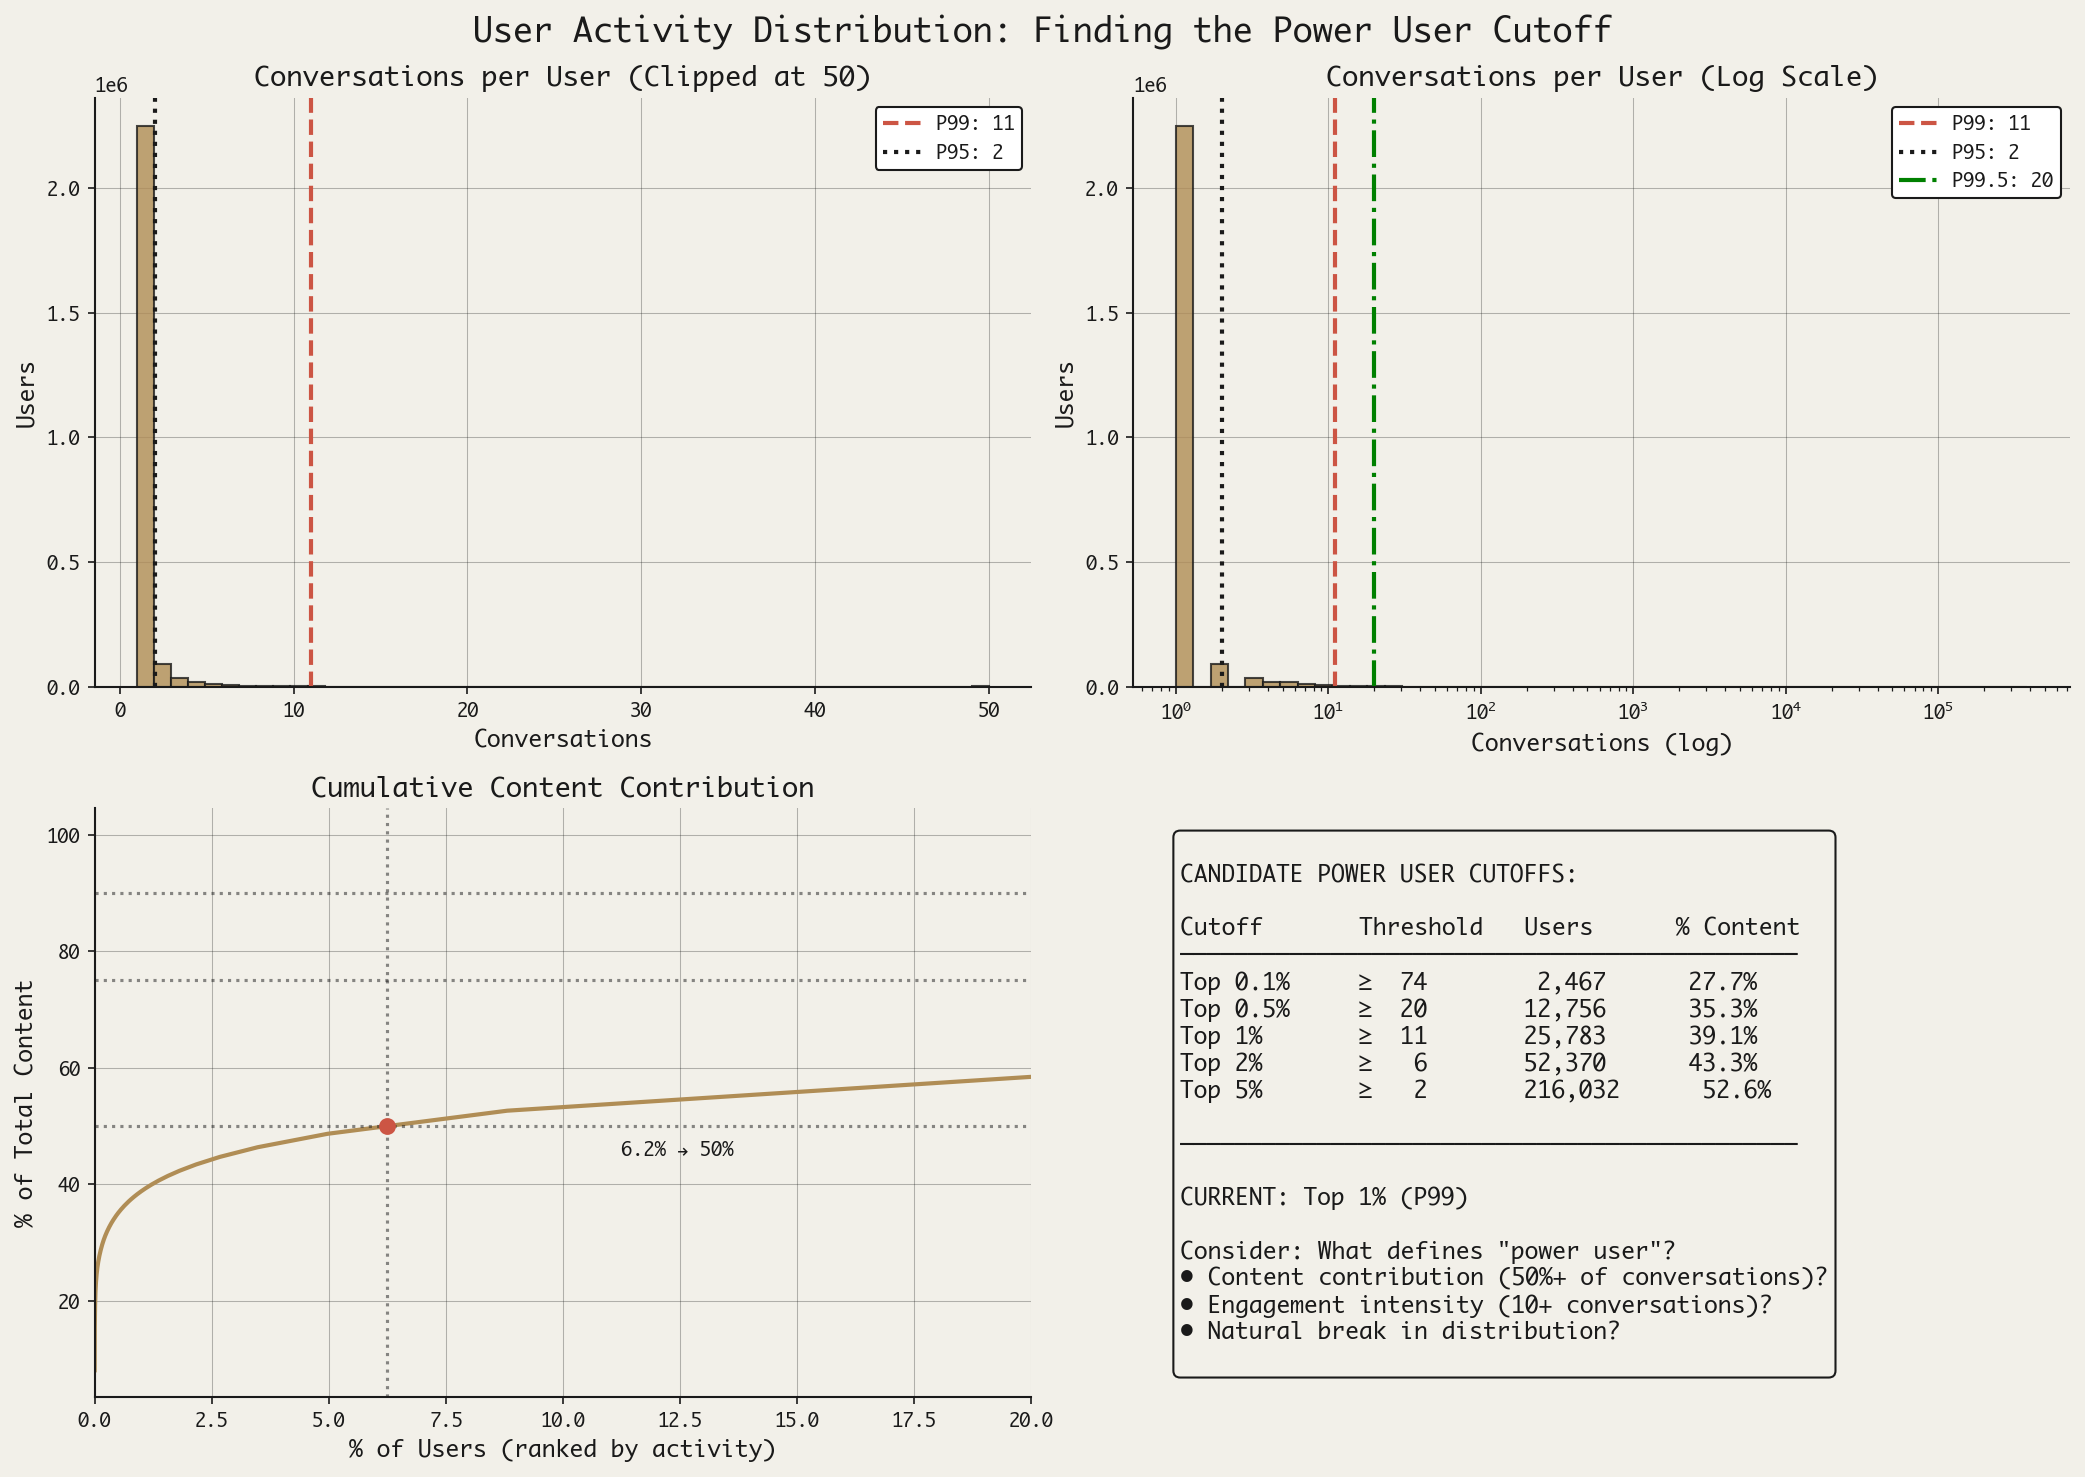


RECOMMENDATION: Review the distribution above to choose optimal cutoff


In [31]:
# ============================================================
# Examine User Activity Distribution (for Power User Cutoff)
# ============================================================
# Goal: Find natural breakpoints in user engagement

# Get conversation counts per user
conv_counts = user_stats['n_conversations'].to_numpy()

# Calculate key percentiles
percentiles = [50, 75, 90, 95, 99, 99.5, 99.9]
percentile_values = {p: np.percentile(conv_counts, p) for p in percentiles}

print("="*70)
print("USER ACTIVITY DISTRIBUTION")
print("="*70)
print(f"\nTotal users: {len(conv_counts):,}")
print(f"  Min conversations: {np.min(conv_counts)}")
print(f"  Max conversations: {np.max(conv_counts):,}")
print(f"  Mean: {np.mean(conv_counts):.2f}")
print(f"  Median: {np.median(conv_counts):.0f}")

print("\nPercentile breakdown:")
print("-"*50)
for p, v in percentile_values.items():
    n_users = (conv_counts >= v).sum()
    pct_users = 100 * n_users / len(conv_counts)
    print(f"  P{p:<5}: ≥{v:>6.0f} conversations → {n_users:>7,} users ({pct_users:>5.2f}%)")

# Calculate contribution to total conversations
print("\nContent contribution by user group:")
print("-"*50)
total_convos = conv_counts.sum()
for cutoff_name, cutoff_pct in [("Top 0.1%", 99.9), ("Top 0.5%", 99.5), ("Top 1%", 99), ("Top 5%", 95), ("Top 10%", 90)]:
    threshold = np.percentile(conv_counts, cutoff_pct)
    group_convos = conv_counts[conv_counts >= threshold].sum()
    pct_content = 100 * group_convos / total_convos
    n_users = (conv_counts >= threshold).sum()
    print(f"  {cutoff_name:<10} (≥{threshold:>4.0f} convos): {n_users:>6,} users → {pct_content:>5.1f}% of content")

# Visualize the distribution
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('User Activity Distribution: Finding the Power User Cutoff', fontsize=16, fontweight='bold', color=BRAND['ink'])

# 1. Histogram (linear scale, clipped)
ax = axes[0, 0]
ax.hist(np.clip(conv_counts, 1, 50), bins=50, color=BRAND['gold'], edgecolor=BRAND['ink'], alpha=0.8)
ax.axvline(percentile_values[99], color=BRAND['alert'], linestyle='--', linewidth=2, label=f'P99: {percentile_values[99]:.0f}')
ax.axvline(percentile_values[95], color=BRAND['ink'], linestyle=':', linewidth=2, label=f'P95: {percentile_values[95]:.0f}')
apply_phronos_style(ax, title='Conversations per User (Clipped at 50)', xlabel='Conversations', ylabel='Users')
ax.legend(facecolor=BRAND['white'], edgecolor=BRAND['ink'])

# 2. Histogram (log scale for full range)
ax = axes[0, 1]
bins_log = np.logspace(0, np.log10(max(conv_counts)), 50)
ax.hist(conv_counts, bins=bins_log, color=BRAND['gold'], edgecolor=BRAND['ink'], alpha=0.8)
ax.set_xscale('log')
ax.axvline(percentile_values[99], color=BRAND['alert'], linestyle='--', linewidth=2, label=f'P99: {percentile_values[99]:.0f}')
ax.axvline(percentile_values[95], color=BRAND['ink'], linestyle=':', linewidth=2, label=f'P95: {percentile_values[95]:.0f}')
ax.axvline(percentile_values[99.5], color='green', linestyle='-.', linewidth=2, label=f'P99.5: {percentile_values[99.5]:.0f}')
apply_phronos_style(ax, title='Conversations per User (Log Scale)', xlabel='Conversations (log)', ylabel='Users')
ax.legend(facecolor=BRAND['white'], edgecolor=BRAND['ink'])

# 3. CDF of content contribution
ax = axes[1, 0]
sorted_counts = np.sort(conv_counts)[::-1]  # Descending
cumsum_pct = 100 * np.cumsum(sorted_counts) / total_convos
user_pct = 100 * np.arange(1, len(sorted_counts) + 1) / len(sorted_counts)
ax.plot(user_pct, cumsum_pct, color=BRAND['gold'], linewidth=2)
# Mark key points
for target_content in [50, 75, 90]:
    idx = np.searchsorted(cumsum_pct, target_content)
    if idx < len(user_pct):
        ax.axhline(target_content, color=FADED, linestyle=':', alpha=0.5)
        ax.axvline(user_pct[idx], color=FADED, linestyle=':', alpha=0.5)
        ax.scatter([user_pct[idx]], [target_content], color=BRAND['alert'], s=50, zorder=5)
        ax.annotate(f'{user_pct[idx]:.1f}% → {target_content}%', 
                   xy=(user_pct[idx], target_content), 
                   xytext=(user_pct[idx]+5, target_content-5),
                   fontsize=9, color=BRAND['ink'])
apply_phronos_style(ax, title='Cumulative Content Contribution', xlabel='% of Users (ranked by activity)', ylabel='% of Total Content')
ax.set_xlim(0, 20)  # Focus on top 20% of users

# 4. Candidate cutoffs comparison
ax = axes[1, 1]
ax.axis('off')
cutoff_text = """
CANDIDATE POWER USER CUTOFFS:

Cutoff       Threshold   Users      % Content
─────────────────────────────────────────────
"""
for cutoff_name, cutoff_pct in [("Top 0.1%", 99.9), ("Top 0.5%", 99.5), ("Top 1%", 99), ("Top 2%", 98), ("Top 5%", 95)]:
    threshold = np.percentile(conv_counts, cutoff_pct)
    n_users = (conv_counts >= threshold).sum()
    group_convos = conv_counts[conv_counts >= threshold].sum()
    pct_content = 100 * group_convos / total_convos
    cutoff_text += f"{cutoff_name:<12} ≥{threshold:>4.0f}       {n_users:>6,}     {pct_content:>5.1f}%\n"

cutoff_text += """
─────────────────────────────────────────────

CURRENT: Top 1% (P99)

Consider: What defines "power user"?
• Content contribution (50%+ of conversations)?
• Engagement intensity (10+ conversations)?
• Natural break in distribution?
"""
ax.text(0.05, 0.95, cutoff_text, transform=ax.transAxes, fontsize=11,
        verticalalignment='top', fontfamily='monospace',
        bbox=dict(boxstyle='round', facecolor=BRAND['paper'], edgecolor=BRAND['ink']))

plt.tight_layout()
save_figure(fig, 'power_user_cutoff_analysis')
plt.show()

print("\n" + "="*70)
print("RECOMMENDATION: Review the distribution above to choose optimal cutoff")
print("="*70)


In [3]:
# ============================================================
# Data Preparation: Extract First-Turn Features
# ============================================================

# Strategy: Load a SINGLE shard of raw data (much faster than scanning all 127 shards)
# Each shard has ~37K conversations, giving us a good sample for text analysis

import glob
import gc
import json

# #region agent log - debug instrumentation
LOG_PATH = '/Users/vishal/Documents/GitHub/phronos-research/.cursor/debug.log'
def debug_log(hyp, loc, msg, data=None):
    try:
        import psutil
        mem_mb = psutil.Process().memory_info().rss / 1024 / 1024
        data = data or {}
        data['mem_mb'] = round(mem_mb, 1)
    except: pass
    with open(LOG_PATH, 'a') as f:
        f.write(json.dumps({'hypothesisId': hyp, 'location': loc, 'message': msg, 'data': data, 'timestamp': __import__('time').time()}) + '\n')
# #endregion

debug_log('H1', 'cell3:start', 'Starting data preparation')

# Get list of raw data shards
raw_shards = sorted(glob.glob('../data/wildchat-raw/data/*.parquet'))
print(f"Found {len(raw_shards)} raw data shards")

# Load 10 shards for better temporal coverage (~370K conversations)
N_SHARDS = 10
# Sample shards evenly across the dataset for temporal diversity
shard_indices = [int(i * len(raw_shards) / N_SHARDS) for i in range(N_SHARDS)]
print(f"Loading {N_SHARDS} shards: {shard_indices}")

debug_log('H1', 'cell3:before_load', 'About to load shards', {'n_shards': N_SHARDS})

# Load shards one at a time and concatenate
all_shards = []
for idx in shard_indices:
    shard = pl.read_parquet(
        raw_shards[idx],
        columns=['conversation_hash', 'conversation']
    )
    all_shards.append(shard)
    print(f"  Loaded shard {idx}: {len(shard):,} rows")

single_shard = pl.concat(all_shards)
del all_shards
gc.collect()

debug_log('H1,H3', 'cell3:after_load', 'Loaded shards', {'n_rows': len(single_shard), 'cols': single_shard.columns})
print(f"\nTotal loaded: {len(single_shard):,} conversations from {N_SHARDS} shards")

# Functions to extract text from conversations
def extract_first_turn(conversation):
    """Extract the first user message from a conversation."""
    if conversation is None:
        return ""
    for msg in conversation:
        if msg.get('role') == 'user':
            content = msg.get('content', '')
            return (content[:1500] if content else "") or ""
    return ""

def extract_first_assistant_turn(conversation):
    """Extract the first assistant message from a conversation."""
    if conversation is None:
        return ""
    for msg in conversation:
        if msg.get('role') == 'assistant':
            content = msg.get('content', '')
            return (content[:1500] if content else "") or ""
    return ""

# Extract text from conversations
print("Extracting first turns...")
debug_log('H4', 'cell3:before_iter', 'About to iterate over shard')

all_results = []
n_rows = len(single_shard)
for i, row in enumerate(single_shard.iter_rows(named=True)):
    first_turn = extract_first_turn(row['conversation'])
    first_ai_turn = extract_first_assistant_turn(row['conversation'])
    all_results.append({
        'conversation_hash': row['conversation_hash'],
        'first_turn': first_turn,
        'first_ai_turn': first_ai_turn,
        'first_turn_words': len(first_turn.split()) if first_turn else 0,
        'first_turn_chars': len(first_turn) if first_turn else 0,
        'first_ai_words': len(first_ai_turn.split()) if first_ai_turn else 0,
        'first_ai_chars': len(first_ai_turn) if first_ai_turn else 0,
    })
    # #region agent log - progress check
    if i == 1000:
        debug_log('H4,H5', 'cell3:iter_1k', 'Processed 1000 rows', {'i': i})
    if i == 5000:
        debug_log('H4,H5', 'cell3:iter_5k', 'Processed 5000 rows', {'i': i})
    if i == 10000:
        debug_log('H4,H5', 'cell3:iter_10k', 'Processed 10000 rows', {'i': i})
    # #endregion

debug_log('H4,H5', 'cell3:after_iter', 'Finished iteration', {'n_results': len(all_results)})

# Clear the heavy shard from memory
del single_shard
gc.collect()
debug_log('H2', 'cell3:after_del_shard', 'Deleted shard and ran GC')

# Create DataFrame from results
raw_sample = pl.DataFrame(all_results)
del all_results  # Free memory
gc.collect()
debug_log('H2', 'cell3:after_create_df', 'Created raw_sample DataFrame', {'n_rows': len(raw_sample)})

print(f"\nExtracted first-turn features for {len(raw_sample):,} conversations")
print(f"  Avg first-turn words: {raw_sample['first_turn_words'].mean():.1f}")
print(f"  Avg first-turn chars: {raw_sample['first_turn_chars'].mean():.0f}")


Found 127 raw data shards
Loading 10 shards: [0, 12, 25, 38, 50, 63, 76, 88, 101, 114]
  Loaded shard 0: 37,350 rows
  Loaded shard 12: 37,350 rows
  Loaded shard 25: 37,349 rows
  Loaded shard 38: 37,349 rows
  Loaded shard 50: 37,349 rows
  Loaded shard 63: 37,349 rows
  Loaded shard 76: 37,349 rows
  Loaded shard 88: 37,349 rows
  Loaded shard 101: 37,349 rows
  Loaded shard 114: 37,349 rows

Total loaded: 373,492 conversations from 10 shards
Extracting first turns...

Extracted first-turn features for 373,492 conversations
  Avg first-turn words: 130.1
  Avg first-turn chars: 922


In [4]:
# ============================================================
# User Segmentation
# ============================================================

def assign_segment(count):
    """Assign user segment based on conversation count."""
    if count == 1:
        return 'one_shot'
    elif count <= 5:
        return 'light'
    elif count <= 20:
        return 'moderate'
    elif count <= 100:
        return 'heavy'
    else:
        return 'power'

# Add segment to user stats
user_stats = user_stats.with_columns([
    pl.col('n_conversations').map_elements(assign_segment, return_dtype=pl.Utf8).alias('user_segment'),
    (pl.col('n_conversations') >= p99_threshold).alias('is_top_1pct'),
    (pl.col('n_conversations') > 1).alias('returned'),
    (pl.col('n_conversations') >= 3).alias('returned_3plus'),
])

# Summary of user segments
segment_summary = user_stats.group_by('user_segment').agg([
    pl.len().alias('n_users'),
    pl.col('n_conversations').sum().alias('total_conversations'),
]).sort('n_users', descending=True)

print("User Segment Distribution:")
print("="*60)
for row in segment_summary.iter_rows(named=True):
    pct_users = 100 * row['n_users'] / len(user_stats)
    pct_convos = 100 * row['total_conversations'] / len(df_users)
    print(f"  {row['user_segment']:<12}: {row['n_users']:>10,} users ({pct_users:>5.1f}%) | {row['total_conversations']:>12,} convos ({pct_convos:>5.1f}%)")

# Return behavior summary
n_returned = user_stats.filter(pl.col('returned'))['user_id'].count()
n_returned_3plus = user_stats.filter(pl.col('returned_3plus'))['user_id'].count()
print(f"\nReturn Behavior:")
print(f"  Users who returned (2+ convos): {n_returned:,} ({100*n_returned/len(user_stats):.1f}%)")
print(f"  Users with 3+ conversations: {n_returned_3plus:,} ({100*n_returned_3plus/len(user_stats):.1f}%)")


User Segment Distribution:
  one_shot    :  2,246,768 users ( 91.2%) |    2,246,768 convos ( 47.4%)
  light       :    163,662 users (  6.6%) |      441,580 convos (  9.3%)
  moderate    :     40,333 users (  1.6%) |      396,485 convos (  8.4%)
  heavy       :     10,347 users (  0.4%) |      409,121 convos (  8.6%)
  power       :      1,690 users (  0.1%) |    1,249,382 convos ( 26.3%)

Return Behavior:
  Users who returned (2+ convos): 216,032 (8.8%)
  Users with 3+ conversations: 121,603 (4.9%)


---

# Analysis 1: What Predicts Return?

**Question:** What distinguishes a first interaction that leads to return visits from one that doesn't?


In [ ]:
# ============================================================
# Extract First-Turn Features for Return Prediction
# ============================================================

# #region agent log
debug_log('H9', 'cell6:start', 'Starting join', {'raw_sample_rows': len(raw_sample)})
# #endregion

# FIX: df_users has multiple rows per conversation_hash (one per turn)
# Deduplicate to get one row per conversation before joining
df_users_unique = df_users.select(['conversation_hash', 'user_id', 'model_family', 'timestamp']).unique(subset=['conversation_hash'])

# #region agent log
debug_log('H9', 'cell6:after_dedup', 'After dedup', {'df_users_unique_rows': len(df_users_unique), 'df_users_rows': len(df_users)})
# #endregion

# Join raw_sample with deduplicated df_users
sample_with_users = raw_sample.join(
    df_users_unique,
    on='conversation_hash',
    how='left'
)

# Clean up
del df_users_unique
gc.collect()

# #region agent log
debug_log('H9', 'cell6:after_join', 'After join', {'sample_with_users_rows': len(sample_with_users), 'expected': len(raw_sample)})
# #endregion

# Get each user's first conversation (by timestamp)
first_convs = sample_with_users.sort('timestamp').group_by('user_id').first()

# Join with user stats to get return behavior
first_convs = first_convs.join(
    user_stats.select(['user_id', 'n_conversations', 'returned', 'user_segment']),
    on='user_id',
    how='left'
)

print(f"First conversations for {len(first_convs):,} users")

# Extract linguistic features
def has_question(text):
    return '?' in str(text)

def count_questions(text):
    return str(text).count('?')

def politeness_score(text):
    text_lower = str(text).lower()
    politeness_words = ['please', 'thank', 'could you', 'would you', 'kindly']
    return sum(1 for w in politeness_words if w in text_lower)

def is_imperative(text):
    imperative_starters = ['write', 'create', 'make', 'give', 'tell', 'explain', 
                          'show', 'help', 'find', 'list', 'generate', 'summarize']
    first_word = str(text).lower().split()[0] if str(text).split() else ''
    return first_word in imperative_starters

def avg_word_length(text):
    words = str(text).split()
    if not words:
        return 0.0
    return np.mean([len(w) for w in words])

def first_person_count(text):
    import re
    return len(re.findall(r'\b(i|me|my|mine)\b', str(text).lower()))

def second_person_count(text):
    import re
    return len(re.findall(r'\b(you|your|yours|yourself|yourselves|u)\b', str(text).lower()))

# Apply feature extraction
first_turn_features = first_convs.with_columns([
    pl.col('first_turn').map_elements(has_question, return_dtype=pl.Boolean).alias('has_question'),
    pl.col('first_turn').map_elements(count_questions, return_dtype=pl.Int64).alias('question_count'),
    pl.col('first_turn').map_elements(politeness_score, return_dtype=pl.Int64).alias('politeness_score'),
    pl.col('first_turn').map_elements(is_imperative, return_dtype=pl.Boolean).alias('is_imperative'),
    pl.col('first_turn').map_elements(avg_word_length, return_dtype=pl.Float64).alias('avg_word_length'),
    pl.col('first_turn').map_elements(first_person_count, return_dtype=pl.Int64).alias('first_person_count'),
    pl.col('first_turn').map_elements(second_person_count, return_dtype=pl.Int64).alias('second_person_count'),
])

print(f"Extracted features for {len(first_turn_features):,} users")
print(f"  Returned: {first_turn_features.filter(pl.col('returned'))['user_id'].count():,}")
print(f"  One-shot: {first_turn_features.filter(~pl.col('returned'))['user_id'].count():,}")


First conversations for 194,324 users


/var/folders/c2/g0c1jz_n4zx8d5xdtn4t9xy00000gn/T/ipykernel_74768/3594580921.py:74: PolarsInefficientMapWarning: 
Expr.map_elements is significantly slower than the native expressions API.
Only use if you absolutely CANNOT implement your logic otherwise.
Replace this expression...
  - pl.col("first_turn").map_elements(has_question)
with this one instead:
  + '?'.is_in(pl.col("first_turn").cast(pl.String))

  pl.col('first_turn').map_elements(has_question, return_dtype=pl.Boolean).alias('has_question'),


Extracted features for 194,324 users
  Returned: 28,052
  One-shot: 166,272


/var/folders/c2/g0c1jz_n4zx8d5xdtn4t9xy00000gn/T/ipykernel_74768/3165571511.py:24: DeprecationWarning: the argument `columns` for `DataFrame.pivot` is deprecated. It was renamed to `on` in version 1.0.0.
  question_pct = question_data.pivot(index='has_question', columns='returned', values='count').fill_null(0)
/var/folders/c2/g0c1jz_n4zx8d5xdtn4t9xy00000gn/T/ipykernel_74768/3165571511.py:57: DeprecationWarning: the argument `columns` for `DataFrame.pivot` is deprecated. It was renamed to `on` in version 1.0.0.
  imperative_pct = imperative_data.pivot(index='is_imperative', columns='returned', values='count').fill_null(0)


Saved: ../outputs/figures/pub_return_predictors.png


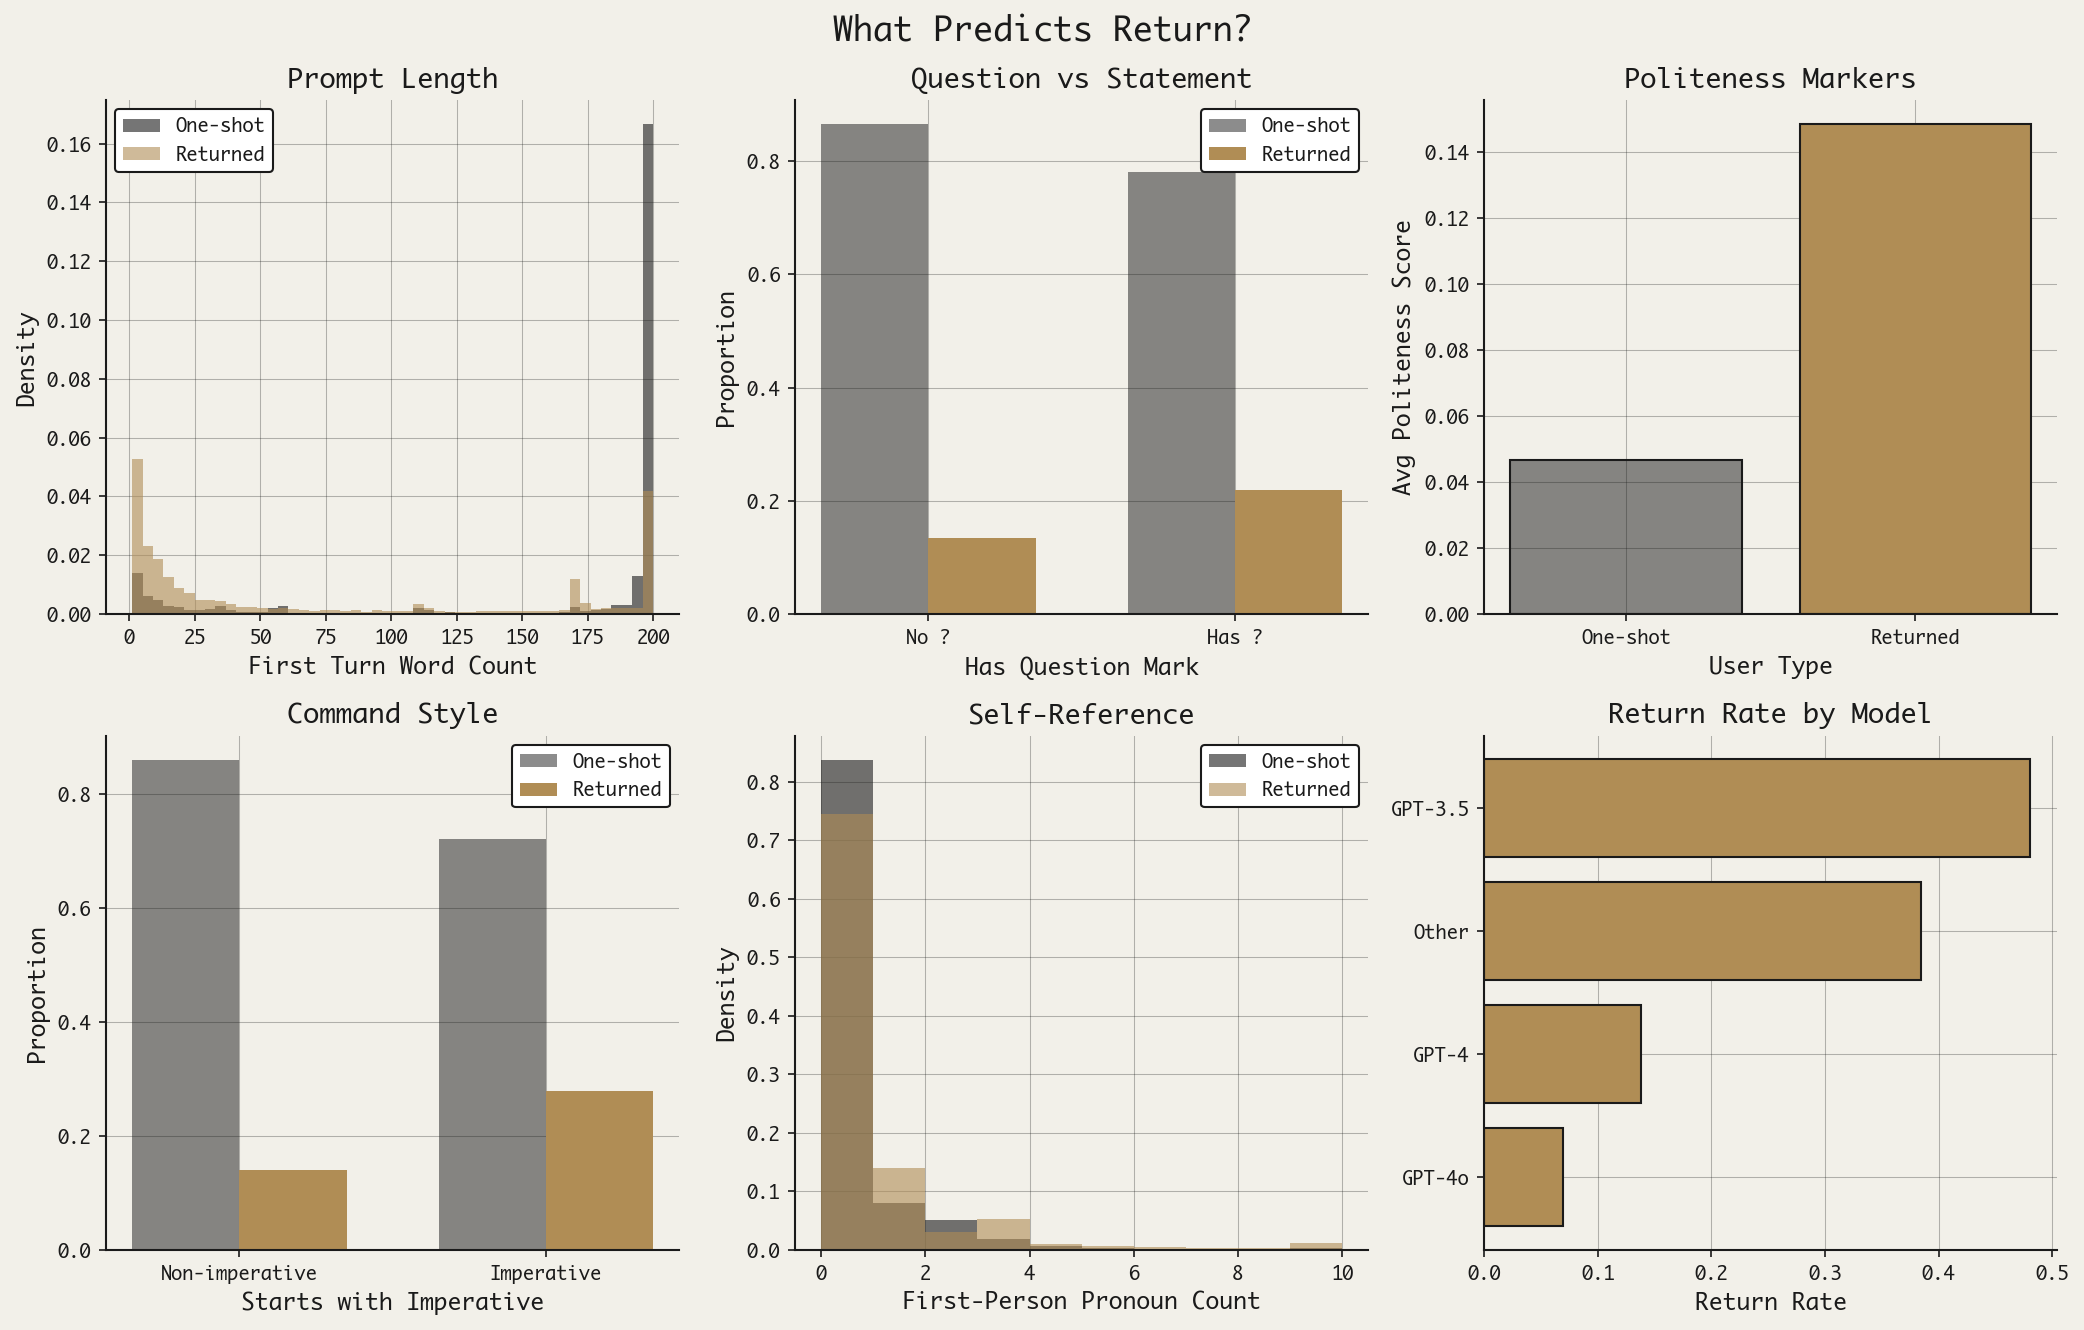

In [6]:
# ============================================================
# Visualize Return Predictors (6-panel figure)
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(14, 9))
fig.suptitle('What Predicts Return?', fontsize=16, fontweight='bold', color=BRAND['ink'])

# Convert to numpy for plotting
returned_df = first_turn_features.filter(pl.col('returned'))
one_shot_df = first_turn_features.filter(~pl.col('returned'))

# 1. Word count distribution by return status
ax = axes[0, 0]
returned_words = returned_df['first_turn_words'].clip(1, 200).to_numpy()
one_shot_words = one_shot_df['first_turn_words'].clip(1, 200).to_numpy()
ax.hist(one_shot_words, bins=50, alpha=0.6, label='One-shot', color=FADED, density=True)
ax.hist(returned_words, bins=50, alpha=0.6, label='Returned', color=BRAND['gold'], density=True)
apply_phronos_style(ax, title='Prompt Length', xlabel='First Turn Word Count', ylabel='Density')
ax.legend(facecolor=BRAND['white'], edgecolor=BRAND['ink'])

# 2. Question presence
ax = axes[0, 1]
question_data = first_turn_features.group_by(['has_question', 'returned']).agg(pl.len().alias('count'))
question_pct = question_data.pivot(index='has_question', columns='returned', values='count').fill_null(0)
question_pct = question_pct.with_columns([
    (pl.col('false') / (pl.col('false') + pl.col('true'))).alias('one_shot_pct'),
    (pl.col('true') / (pl.col('false') + pl.col('true'))).alias('returned_pct'),
])
x_labels = ['No ?', 'Has ?']
x_pos = np.arange(len(x_labels))
width = 0.35
bars1 = ax.bar(x_pos - width/2, [question_pct.filter(pl.col('has_question') == False)['one_shot_pct'][0],
                                  question_pct.filter(pl.col('has_question') == True)['one_shot_pct'][0]], 
               width, label='One-shot', color=FADED)
bars2 = ax.bar(x_pos + width/2, [question_pct.filter(pl.col('has_question') == False)['returned_pct'][0],
                                  question_pct.filter(pl.col('has_question') == True)['returned_pct'][0]], 
               width, label='Returned', color=BRAND['gold'])
ax.set_xticks(x_pos)
ax.set_xticklabels(x_labels)
apply_phronos_style(ax, title='Question vs Statement', xlabel='Has Question Mark', ylabel='Proportion')
ax.legend(facecolor=BRAND['white'], edgecolor=BRAND['ink'])

# 3. Politeness score
ax = axes[0, 2]
politeness_by_return = first_turn_features.group_by('returned').agg(
    pl.col('politeness_score').mean().alias('avg_politeness')
).sort('returned')
x_labels = ['One-shot', 'Returned']
values = politeness_by_return['avg_politeness'].to_list()
colors = [FADED, BRAND['gold']]
ax.bar(x_labels, values, color=colors, edgecolor=BRAND['ink'])
apply_phronos_style(ax, title='Politeness Markers', xlabel='User Type', ylabel='Avg Politeness Score')

# 4. Imperative commands
ax = axes[1, 0]
imperative_data = first_turn_features.group_by(['is_imperative', 'returned']).agg(pl.len().alias('count'))
imperative_pct = imperative_data.pivot(index='is_imperative', columns='returned', values='count').fill_null(0)
imperative_pct = imperative_pct.with_columns([
    (pl.col('false') / (pl.col('false') + pl.col('true'))).alias('one_shot_pct'),
    (pl.col('true') / (pl.col('false') + pl.col('true'))).alias('returned_pct'),
])
x_labels = ['Non-imperative', 'Imperative']
x_pos = np.arange(len(x_labels))
bars1 = ax.bar(x_pos - width/2, [imperative_pct.filter(pl.col('is_imperative') == False)['one_shot_pct'][0],
                                  imperative_pct.filter(pl.col('is_imperative') == True)['one_shot_pct'][0]], 
               width, label='One-shot', color=FADED)
bars2 = ax.bar(x_pos + width/2, [imperative_pct.filter(pl.col('is_imperative') == False)['returned_pct'][0],
                                  imperative_pct.filter(pl.col('is_imperative') == True)['returned_pct'][0]], 
               width, label='Returned', color=BRAND['gold'])
ax.set_xticks(x_pos)
ax.set_xticklabels(x_labels)
apply_phronos_style(ax, title='Command Style', xlabel='Starts with Imperative', ylabel='Proportion')
ax.legend(facecolor=BRAND['white'], edgecolor=BRAND['ink'])

# 5. First-person pronoun usage
ax = axes[1, 1]
returned_pronouns = returned_df['first_person_count'].clip(0, 10).to_numpy()
one_shot_pronouns = one_shot_df['first_person_count'].clip(0, 10).to_numpy()
ax.hist(one_shot_pronouns, bins=10, alpha=0.6, label='One-shot', color=FADED, density=True)
ax.hist(returned_pronouns, bins=10, alpha=0.6, label='Returned', color=BRAND['gold'], density=True)
apply_phronos_style(ax, title='Self-Reference', xlabel='First-Person Pronoun Count', ylabel='Density')
ax.legend(facecolor=BRAND['white'], edgecolor=BRAND['ink'])

# 6. Return rate by model
ax = axes[1, 2]
model_return = first_turn_features.filter(pl.col('model_family').is_not_null()).group_by('model_family').agg([
    pl.col('returned').mean().alias('return_rate'),
    pl.len().alias('n')
]).filter(pl.col('n') >= 100).sort('return_rate', descending=True).head(10)
y_pos = np.arange(len(model_return))
ax.barh(y_pos, model_return['return_rate'].to_numpy(), color=BRAND['gold'], edgecolor=BRAND['ink'])
ax.set_yticks(y_pos)
ax.set_yticklabels(model_return['model_family'].to_list())
ax.invert_yaxis()
apply_phronos_style(ax, title='Return Rate by Model', xlabel='Return Rate')

plt.tight_layout()
save_figure(fig, 'return_predictors')
plt.show()


In [56]:
# ============================================================
# Return Predictor Summary Table (with Power Users)
# ============================================================

returned = first_turn_features.filter(pl.col('returned'))
one_shot = first_turn_features.filter(~pl.col('returned'))

# Ensure second_person_count exists (in case earlier cell wasn't re-run)
if 'second_person_count' not in first_turn_features.columns:
    if 'second_person_count' not in globals():
        import re
        def second_person_count(text):
            return len(re.findall(r'\b(you|your|yours|yourself|yourselves|u)\b', str(text).lower()))
    first_turn_features = first_turn_features.with_columns([
        pl.col('first_turn').map_elements(second_person_count, return_dtype=pl.Int64).alias('second_person_count')
    ])
    returned = first_turn_features.filter(pl.col('returned'))
    one_shot = first_turn_features.filter(~pl.col('returned'))

# Add power users as a third comparator group
power_users = first_turn_features.filter(pl.col('user_id').is_in(power_user_ids))

print(f"Group sizes: One-shot={len(one_shot):,}, Returning={len(returned):,}, Power Users={len(power_users):,}")

metrics = {
    'Metric': [
        'Avg word count',
        'Has question (%)',
        'Avg politeness score',
        'Imperative start (%)',
        'Avg first-person pronouns',
        'Avg second-person pronouns',
        'Avg word length (complexity)'
    ],
    'One-Shot': [
        f"{one_shot['first_turn_words'].mean():.1f}",
        f"{100 * one_shot['has_question'].mean():.1f}%",
        f"{one_shot['politeness_score'].mean():.2f}",
        f"{100 * one_shot['is_imperative'].mean():.1f}%",
        f"{one_shot['first_person_count'].mean():.2f}",
        f"{one_shot['second_person_count'].mean():.2f}",
        f"{one_shot['avg_word_length'].mean():.2f}"
    ],
    'Returning': [
        f"{returned['first_turn_words'].mean():.1f}",
        f"{100 * returned['has_question'].mean():.1f}%",
        f"{returned['politeness_score'].mean():.2f}",
        f"{100 * returned['is_imperative'].mean():.1f}%",
        f"{returned['first_person_count'].mean():.2f}",
        f"{returned['second_person_count'].mean():.2f}",
        f"{returned['avg_word_length'].mean():.2f}"
    ],
    'Power Users': [
        f"{power_users['first_turn_words'].mean():.1f}" if len(power_users) > 0 else "N/A",
        f"{100 * power_users['has_question'].mean():.1f}%" if len(power_users) > 0 else "N/A",
        f"{power_users['politeness_score'].mean():.2f}" if len(power_users) > 0 else "N/A",
        f"{100 * power_users['is_imperative'].mean():.1f}%" if len(power_users) > 0 else "N/A",
        f"{power_users['first_person_count'].mean():.2f}" if len(power_users) > 0 else "N/A",
        f"{power_users['second_person_count'].mean():.2f}" if len(power_users) > 0 else "N/A",
        f"{power_users['avg_word_length'].mean():.2f}" if len(power_users) > 0 else "N/A"
    ]
}

summary_table = pl.DataFrame(metrics)

print("\n" + "="*90)
print("TABLE: Return Predictor Comparison (One-Shot vs Returning vs Power Users)")
print("="*90)
print(f"\n{'Metric':<30} {'One-Shot':<18} {'Returning':<18} {'Power Users':<18}")
print("-"*90)
for i in range(len(metrics['Metric'])):
    print(f"{metrics['Metric'][i]:<30} {metrics['One-Shot'][i]:<18} {metrics['Returning'][i]:<18} {metrics['Power Users'][i]:<18}")


Group sizes: One-shot=166,272, Returning=28,052, Power Users=5,472

TABLE: Return Predictor Comparison (One-Shot vs Returning vs Power Users)

Metric                         One-Shot           Returning          Power Users       
------------------------------------------------------------------------------------------
Avg word count                 169.6              78.0               75.3              
Has question (%)               10.0%              16.6%              21.5%             
Avg politeness score           0.05               0.15               0.11              
Imperative start (%)           2.9%               6.6%               9.4%              
Avg first-person pronouns      0.33               0.63               0.63              
Avg second-person pronouns     0.85               0.61               0.80              
Avg word length (complexity)   6.72               7.95               7.66              


---

# Analysis 2: Power User Phenotyping

**Question:** What characterizes the top 1% who generate 50% of content?


In [8]:
# ============================================================
# Identify and Profile Power Users
# ============================================================

# #region agent log
debug_log('H6', 'cell10:start', 'Starting power user analysis')
# #endregion

# Power user conversations
power_user_convs = df_users.filter(pl.col('user_id').is_in(power_user_ids))
general_pop_convs = df_users.filter(~pl.col('user_id').is_in(power_user_ids))

print(f"Power users (top 1%): {len(power_user_ids):,}")
print(f"Power user conversations: {len(power_user_convs):,} ({100*len(power_user_convs)/len(df_users):.1f}%)")
print(f"General population conversations: {len(general_pop_convs):,} ({100*len(general_pop_convs)/len(df_users):.1f}%)")

# Calculate activity span for each user
user_stats_with_span = user_stats.with_columns([
    ((pl.col('last_conv_date') - pl.col('first_conv_date')).dt.total_days()).alias('activity_span_days')
])

power_user_stats = user_stats_with_span.filter(pl.col('user_id').is_in(power_user_ids))
general_user_stats = user_stats_with_span.filter(~pl.col('user_id').is_in(power_user_ids))

# Build comparison profile
profile = {
    'Metric': [],
    'General Population': [],
    'Power Users (Top 1%)': []
}

# Avg turns per conversation
profile['Metric'].append('Avg turns per conversation')
profile['General Population'].append(f"{general_pop_convs['n_turns'].mean():.1f}")
profile['Power Users (Top 1%)'].append(f"{power_user_convs['n_turns'].mean():.1f}")

# Multi-turn rate
profile['Metric'].append('Multi-turn rate (>2 turns)')
profile['General Population'].append(f"{100*(general_pop_convs['n_turns'] > 2).mean():.1f}%")
profile['Power Users (Top 1%)'].append(f"{100*(power_user_convs['n_turns'] > 2).mean():.1f}%")

# Toxicity rate
profile['Metric'].append('Toxicity rate')
profile['General Population'].append(f"{100*general_pop_convs['is_toxic'].mean():.1f}%")
profile['Power Users (Top 1%)'].append(f"{100*power_user_convs['is_toxic'].mean():.1f}%")

# Protest rate
profile['Metric'].append('Protest rate')
profile['General Population'].append(f"{100*general_pop_convs['has_protest'].mean():.1f}%")
profile['Power Users (Top 1%)'].append(f"{100*power_user_convs['has_protest'].mean():.1f}%")

# Activity span
profile['Metric'].append('Avg activity span (days)')
profile['General Population'].append(f"{general_user_stats['activity_span_days'].mean():.0f}")
profile['Power Users (Top 1%)'].append(f"{power_user_stats['activity_span_days'].mean():.0f}")

# Avg conversations per user
profile['Metric'].append('Avg conversations per user')
profile['General Population'].append(f"{general_user_stats['n_conversations'].mean():.1f}")
profile['Power Users (Top 1%)'].append(f"{power_user_stats['n_conversations'].mean():.0f}")

# #region agent log
debug_log('H6', 'cell10:end', 'Finished power user profiling')
# #endregion

print("\n" + "="*70)
print("TABLE: Power User Profile vs General Population")
print("="*70)
print(f"\n{'Metric':<30} {'General Pop':<20} {'Power Users':<20}")
print("-"*70)
for i in range(len(profile['Metric'])):
    print(f"{profile['Metric'][i]:<30} {profile['General Population'][i]:<20} {profile['Power Users (Top 1%)'][i]:<20}")


Power users (top 1%): 25,783
Power user conversations: 1,855,942 (39.1%)
General population conversations: 2,887,394 (60.9%)

TABLE: Power User Profile vs General Population

Metric                         General Pop          Power Users         
----------------------------------------------------------------------
Avg turns per conversation     3.1                  3.7                 
Multi-turn rate (>2 turns)     12.5%                18.1%               
Toxicity rate                  30.4%                35.8%               
Protest rate                   4.8%                 1.9%                
Avg activity span (days)       0                    20                  
Avg conversations per user     1.2                  72                  


In [9]:
# ============================================================
# Power User Topic Clustering
# ============================================================

# #region agent log
debug_log('H7', 'cell11:start', 'Starting topic clustering')
# #endregion

# Get power user first turns from sample
power_user_sample = sample_with_users.filter(pl.col('user_id').is_in(power_user_ids))
debug_log('H7', 'cell11:filtered', 'Filtered power users', {'n_rows': len(power_user_sample)})
print(f"Power user conversations in sample: {len(power_user_sample):,}")

# Topic keywords for clustering
topic_keywords = {
    'coding': ['code', 'python', 'javascript', 'function', 'error', 'debug', 'api', 'programming', 'script'],
    'writing': ['write', 'story', 'essay', 'article', 'blog', 'creative', 'character', 'plot', 'novel'],
    'roleplay': ['roleplay', 'character', 'scenario', 'act as', 'pretend', 'you are', 'imagine'],
    'emotional': ['feel', 'anxious', 'depressed', 'lonely', 'help me', 'advice', 'relationship', 'stress'],
    'factual': ['what is', 'who is', 'when did', 'how does', 'explain', 'define', 'tell me about'],
    'productivity': ['summarize', 'email', 'meeting', 'schedule', 'organize', 'plan', 'list']
}

def score_topics(text):
    """Score text against topic keywords."""
    text_lower = str(text).lower()
    scores = {}
    for topic, keywords in topic_keywords.items():
        scores[topic] = sum(1 for kw in keywords if kw in text_lower)
    return scores

def get_dominant_topic(text):
    """Get dominant topic for a text."""
    scores = score_topics(text)
    max_score = max(scores.values())
    if max_score == 0:
        return 'other'
    for topic, score in scores.items():
        if score == max_score:
            return topic
    return 'other'

# Apply topic classification
power_user_sample = power_user_sample.with_columns([
    pl.col('first_turn').map_elements(get_dominant_topic, return_dtype=pl.Utf8).alias('dominant_topic')
])

# Aggregate by user - get their most common topic
user_topics = power_user_sample.group_by('user_id').agg([
    pl.col('dominant_topic').mode().first().alias('user_dominant_topic'),
    pl.len().alias('n_convos_in_sample')
])

debug_log('H7', 'cell11:before_print', 'About to print topic distribution')

print("\nPower User Topic Distribution:")
topic_dist = user_topics['user_dominant_topic'].value_counts().sort('count', descending=True)
for row in topic_dist.iter_rows(named=True):
    pct = 100 * row['count'] / len(user_topics)
    print(f"  {row['user_dominant_topic']:<15}: {row['count']:>6,} ({pct:>5.1f}%)")

# #region agent log
debug_log('H7', 'cell11:end', 'Finished topic clustering')
# #endregion


Power user conversations in sample: 138,990

Power User Topic Distribution:
  other          :  3,343 ( 61.1%)
  coding         :  1,099 ( 20.1%)
  writing        :    619 ( 11.3%)
  productivity   :    170 (  3.1%)
  roleplay       :    116 (  2.1%)
  factual        :     91 (  1.7%)
  emotional      :     34 (  0.6%)


Saved: ../outputs/figures/pub_power_user_phenotypes.png


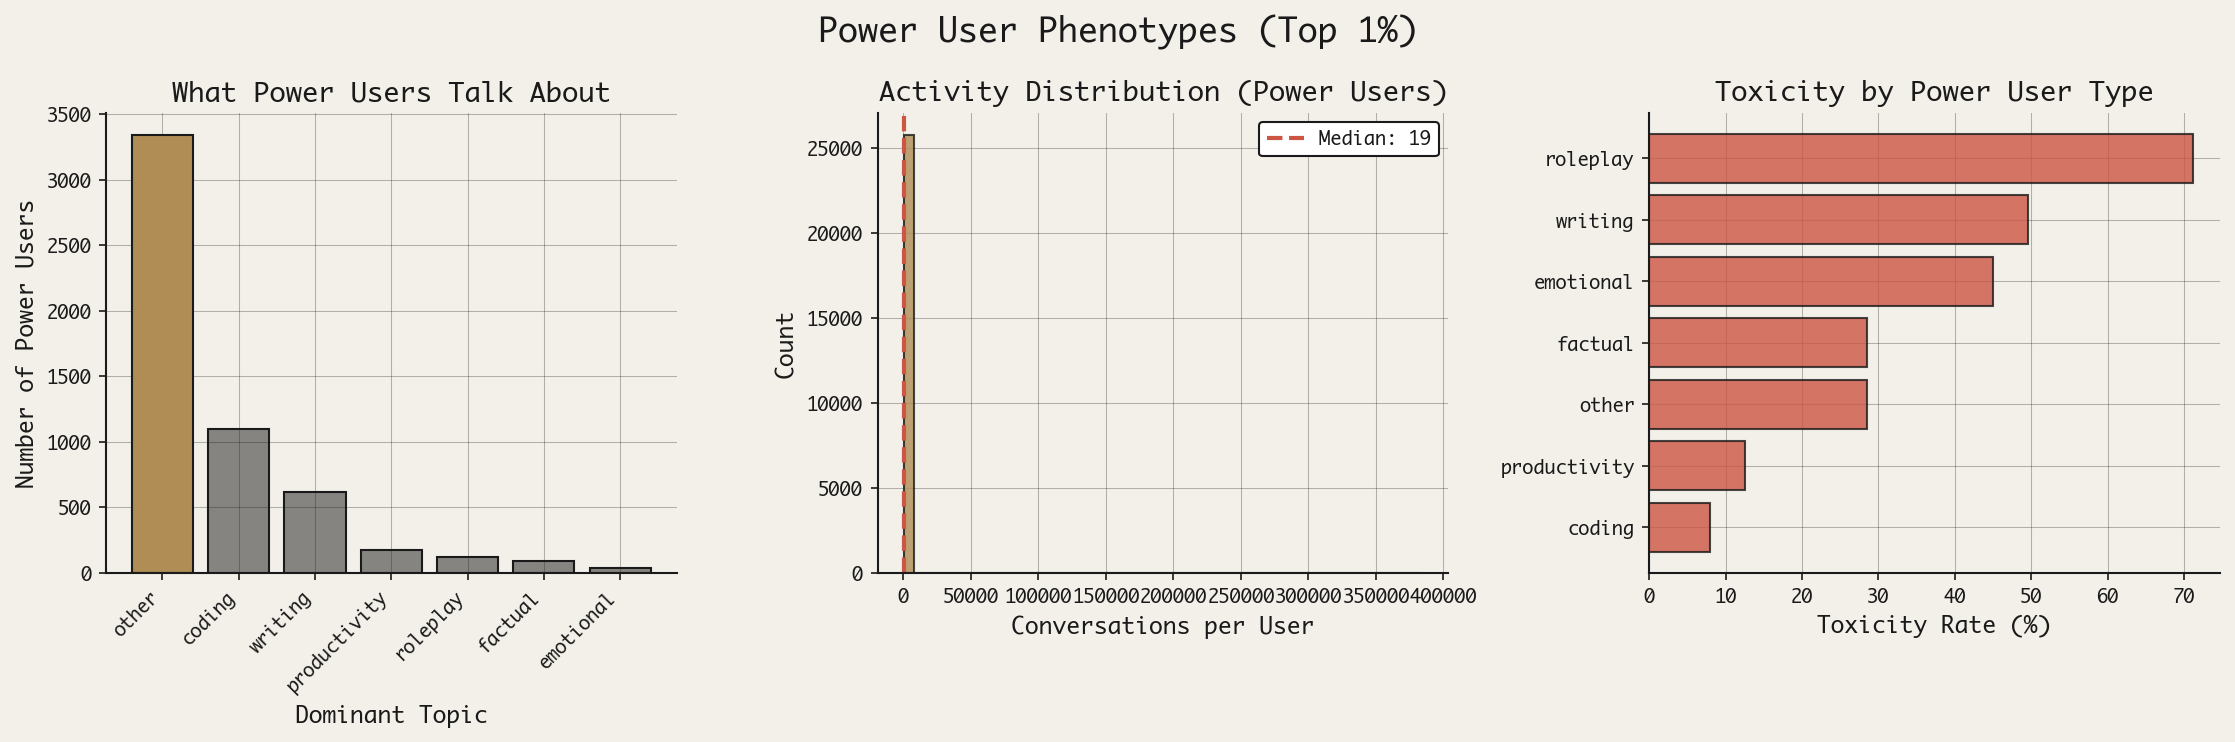

In [10]:
# ============================================================
# Visualize Power User Phenotypes (3-panel figure)
# ============================================================

# #region agent log
debug_log('H10', 'cell12:start', 'Starting power user visualization')
# #endregion

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Power User Phenotypes (Top 1%)', fontsize=16, fontweight='bold', color=BRAND['ink'])

# 1. Dominant topic distribution
ax = axes[0]
topic_counts = topic_dist.sort('count', descending=True)
topics = topic_counts['user_dominant_topic'].to_list()
counts = topic_counts['count'].to_list()
colors = [BRAND['gold'] if i == 0 else FADED for i in range(len(topics))]
bars = ax.bar(topics, counts, color=colors, edgecolor=BRAND['ink'])
apply_phronos_style(ax, title='What Power Users Talk About', xlabel='Dominant Topic', ylabel='Number of Power Users')
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

# 2. Conversation count distribution among power users
ax = axes[1]
conv_counts = power_user_stats['n_conversations'].to_numpy()
ax.hist(conv_counts, bins=50, color=BRAND['gold'], edgecolor=BRAND['ink'], alpha=0.8)
median_val = np.median(conv_counts)
ax.axvline(median_val, color=BRAND['alert'], linestyle='--', linewidth=2, label=f'Median: {median_val:.0f}')
apply_phronos_style(ax, title='Activity Distribution (Power Users)', xlabel='Conversations per User', ylabel='Count')
ax.legend(facecolor=BRAND['white'], edgecolor=BRAND['ink'])

# 3. Toxicity rate by dominant topic
ax = axes[2]
# Merge topic back to conversations
debug_log('H10', 'cell12:before_topic_map', 'Creating topic map', {'n_users': len(user_topics)})
topic_map = dict(zip(user_topics['user_id'].to_list(), user_topics['user_dominant_topic'].to_list()))
power_user_sample_with_topic = power_user_sample.with_columns([
    pl.col('user_id').map_elements(lambda x: topic_map.get(x, 'unknown'), return_dtype=pl.Utf8).alias('user_topic')
])
debug_log('H10', 'cell12:after_topic_map', 'Applied topic map', {'n_rows': len(power_user_sample_with_topic)})

# Join with toxicity from df_users (deduplicated to avoid row explosion)
debug_log('H10', 'cell12:before_toxic_join', 'About to join with df_users for toxicity')
df_users_toxic = df_users.select(['conversation_hash', 'is_toxic']).unique(subset=['conversation_hash'])
power_convos_with_toxic = power_user_sample_with_topic.join(
    df_users_toxic,
    on='conversation_hash',
    how='left'
)
del df_users_toxic
gc.collect()
debug_log('H10', 'cell12:after_toxic_join', 'After toxic join', {'n_rows': len(power_convos_with_toxic)})

toxic_by_topic = power_convos_with_toxic.group_by('user_topic').agg([
    pl.col('is_toxic').mean().alias('toxicity_rate')
]).sort('toxicity_rate', descending=True)

topics = toxic_by_topic['user_topic'].to_list()
rates = [r * 100 for r in toxic_by_topic['toxicity_rate'].to_list()]
ax.barh(topics, rates, color=BRAND['alert'], edgecolor=BRAND['ink'], alpha=0.8)
ax.invert_yaxis()
apply_phronos_style(ax, title='Toxicity by Power User Type', xlabel='Toxicity Rate (%)', ylabel='')

plt.tight_layout()
save_figure(fig, 'power_user_phenotypes')
plt.show()

# #region agent log
debug_log('H10', 'cell12:end', 'Finished power user visualization')
# #endregion


---

# Analysis 3: First-Turn Typology

**Question:** What cognitive tasks are humans delegating to AI?


In [11]:
# ============================================================
# Intent Classification
# ============================================================

# #region agent log
debug_log('H8', 'cell14:start', 'Starting intent classification')
# #endregion

def classify_intent(text):
    """
    Classify first-turn intent using keyword patterns.
    Expanded to reduce 'other' category. For production, use LLM-based classification.
    """
    text_lower = str(text).lower()
    
    # Intent patterns (order matters - first match wins, more specific first)
    patterns = [
        # Conversational/Social
        ('greeting', [r'^hi\b', r'^hello', r'^hey\b', r'^good morning', r'^good evening', r"^what's up"]),
        ('roleplay', [r'act as', r'you are a', r'pretend', r'roleplay', r'scenario', r'imagine you', r'play the role']),
        ('emotional_support', [r'i feel', r"i'm feeling", r'anxious', r'depressed', r'lonely', r'stressed', 
                               r'advice', r'help me cope', r'i am sad', r'i am worried', r'relationship']),
        ('chat', [r'how are you', r'tell me about yourself', r"what's your name", r'are you ai', r'who made you']),
        
        # Creative
        ('creative_writing', [r'write a story', r'write a poem', r'creative', r'fiction', r'write me a', 
                              r'compose', r'short story', r'lyrics', r'screenplay', r'novel']),
        ('humor', [r'joke', r'funny', r'make me laugh', r'pun', r'riddle']),
        
        # Technical
        ('coding', [r'code', r'python', r'javascript', r'java\b', r'function', r'error', r'debug', 
                   r'programming', r'script', r'algorithm', r'api', r'sql', r'html', r'css', r'react',
                   r'bug', r'compile', r'syntax', r'variable', r'array', r'loop']),
        ('math', [r'calculate', r'solve', r'equation', r'math', r'\d+\s*[\+\-\*\/\^]\s*\d+', r'derivative',
                 r'integral', r'probability', r'statistics', r'percentage']),
        
        # Information
        ('explain', [r'explain', r'how does', r'what is', r'why does', r'help me understand', r'tell me about',
                    r'what are', r'describe', r'define', r'meaning of']),
        ('factual', [r'who is', r'when did', r'where is', r'what year', r'how many', r'how much', r'how old',
                    r'capital of', r'population', r'distance', r'history of']),
        ('how_to', [r'how to', r'how do i', r'how can i', r'steps to', r'tutorial', r'guide', r'instructions']),
        
        # Tasks
        ('summarize', [r'summarize', r'tldr', r'summary', r'key points', r'main ideas', r'brief']),
        ('translate', [r'translate', r'in spanish', r'in french', r'to english', r'in german', r'in chinese',
                      r'in japanese', r'in korean', r'in portuguese', r'in italian', r'in russian']),
        ('rewrite', [r'rewrite', r'paraphrase', r'rephrase', r'improve', r'make it better', r'fix my',
                    r'correct', r'proofread', r'edit this', r'grammar']),
        ('brainstorm', [r'ideas for', r'brainstorm', r'suggestions', r'what are some', r'list of', r'give me',
                       r'recommend', r'options', r'alternatives']),
        ('task_completion', [r'write an email', r'draft', r'create a', r'make a', r'generate', r'write a letter',
                            r'write a resume', r'cover letter', r'essay', r'report', r'presentation']),
        
        # Analysis
        ('compare', [r'compare', r'difference between', r'versus', r' vs ', r'better than', r'pros and cons']),
        ('opinion', [r'what do you think', r'your opinion', r'should i', r'is it worth', r'recommend']),
        
        # Commands (short/direct)
        ('command', [r'^list\b', r'^name\b', r'^show\b', r'^find\b', r'^search\b', r'^get\b']),
        
        # Content (text provided)
        ('analyze_text', [r'analyze', r'review', r'feedback', r'critique', r'evaluate']),
        ('continue', [r'continue', r'finish', r'complete this', r'what happens next']),
    ]
    
    for intent, keywords in patterns:
        for kw in keywords:
            if re.search(kw, text_lower):
                return intent
    
    # Check text length for remaining - very short prompts are often simple queries
    if len(text_lower) < 20:
        return 'short_query'
    
    return 'other'

# Apply intent classification to sample
sample_with_users = sample_with_users.with_columns([
    pl.col('first_turn').map_elements(classify_intent, return_dtype=pl.Utf8).alias('intent')
])

# Join with user stats for segment info
sample_with_segment = sample_with_users.join(
    user_stats.select(['user_id', 'user_segment', 'returned']),
    on='user_id',
    how='left'
)

# Overall distribution
intent_dist = sample_with_segment['intent'].value_counts().sort('count', descending=True)
print("Overall Intent Distribution:")
print("="*50)
for row in intent_dist.iter_rows(named=True):
    pct = 100 * row['count'] / len(sample_with_segment)
    print(f"  {row['intent']:<20}: {row['count']:>8,} ({pct:>5.1f}%)")

# #region agent log
debug_log('H8', 'cell14:end', 'Finished intent classification', {'n_rows': len(sample_with_segment)})
# #endregion


Overall Intent Distribution:
  coding              :  148,720 ( 39.8%)
  other               :  108,688 ( 29.1%)
  roleplay            :   21,169 (  5.7%)
  short_query         :   17,376 (  4.7%)
  math                :   16,749 (  4.5%)
  explain             :   11,392 (  3.1%)
  greeting            :    7,839 (  2.1%)
  creative_writing    :    7,224 (  1.9%)
  humor               :    5,754 (  1.5%)
  task_completion     :    4,561 (  1.2%)
  analyze_text        :    3,748 (  1.0%)
  how_to              :    3,422 (  0.9%)
  chat                :    2,972 (  0.8%)
  rewrite             :    2,577 (  0.7%)
  brainstorm          :    2,527 (  0.7%)
  factual             :    2,309 (  0.6%)
  translate           :    2,040 (  0.5%)
  emotional_support   :    1,916 (  0.5%)
  summarize           :      823 (  0.2%)
  continue            :      634 (  0.2%)
  compare             :      441 (  0.1%)
  command             :      347 (  0.1%)
  opinion             :      264 (  0.1%)


'Other' conversations: 108,688 (29.1%)

RANDOM SAMPLE OF 'OTHER' FIRST TURNS (10 examples)

[1] Если текст имеет в себе явные маты, оскорбления в чью-то сторону, политику, расизм, плохих людей в истории (Гитлер, Сталин, Путин и т.д.) или опасные действия (наркотики, секс и т.д.) на любом языке (...

[2] irqbalance01 出现 Heuristic: Detected 0 irq-cpu pairs have been dissallowed 的原因...

[3] fais moi un slogan espagnol contre la discrimination de la trisomie 21...

[4] Traduis moi ce terme en anglais. Ne traduis pas ce qui a entre parentèse. Donne moi la traduction seul sans explication. Retourne dans un json {data: <traduction>} Voici le terme: jarret(viandes Boeuf...

[5] Plastic polymer made of CHNOPS...

[6] crie 30 dicionários como esse {
    "pergunta": "Que cientista propôs a lei da gravitação universal?",
    "alternativas": {"a": "Albert Einstein", "b": "Isaac Newton", "c": "Galileo Galilei", "d": "J...

[7] клиническая характеристика пареза при поражении внутренней капсулы...

[8

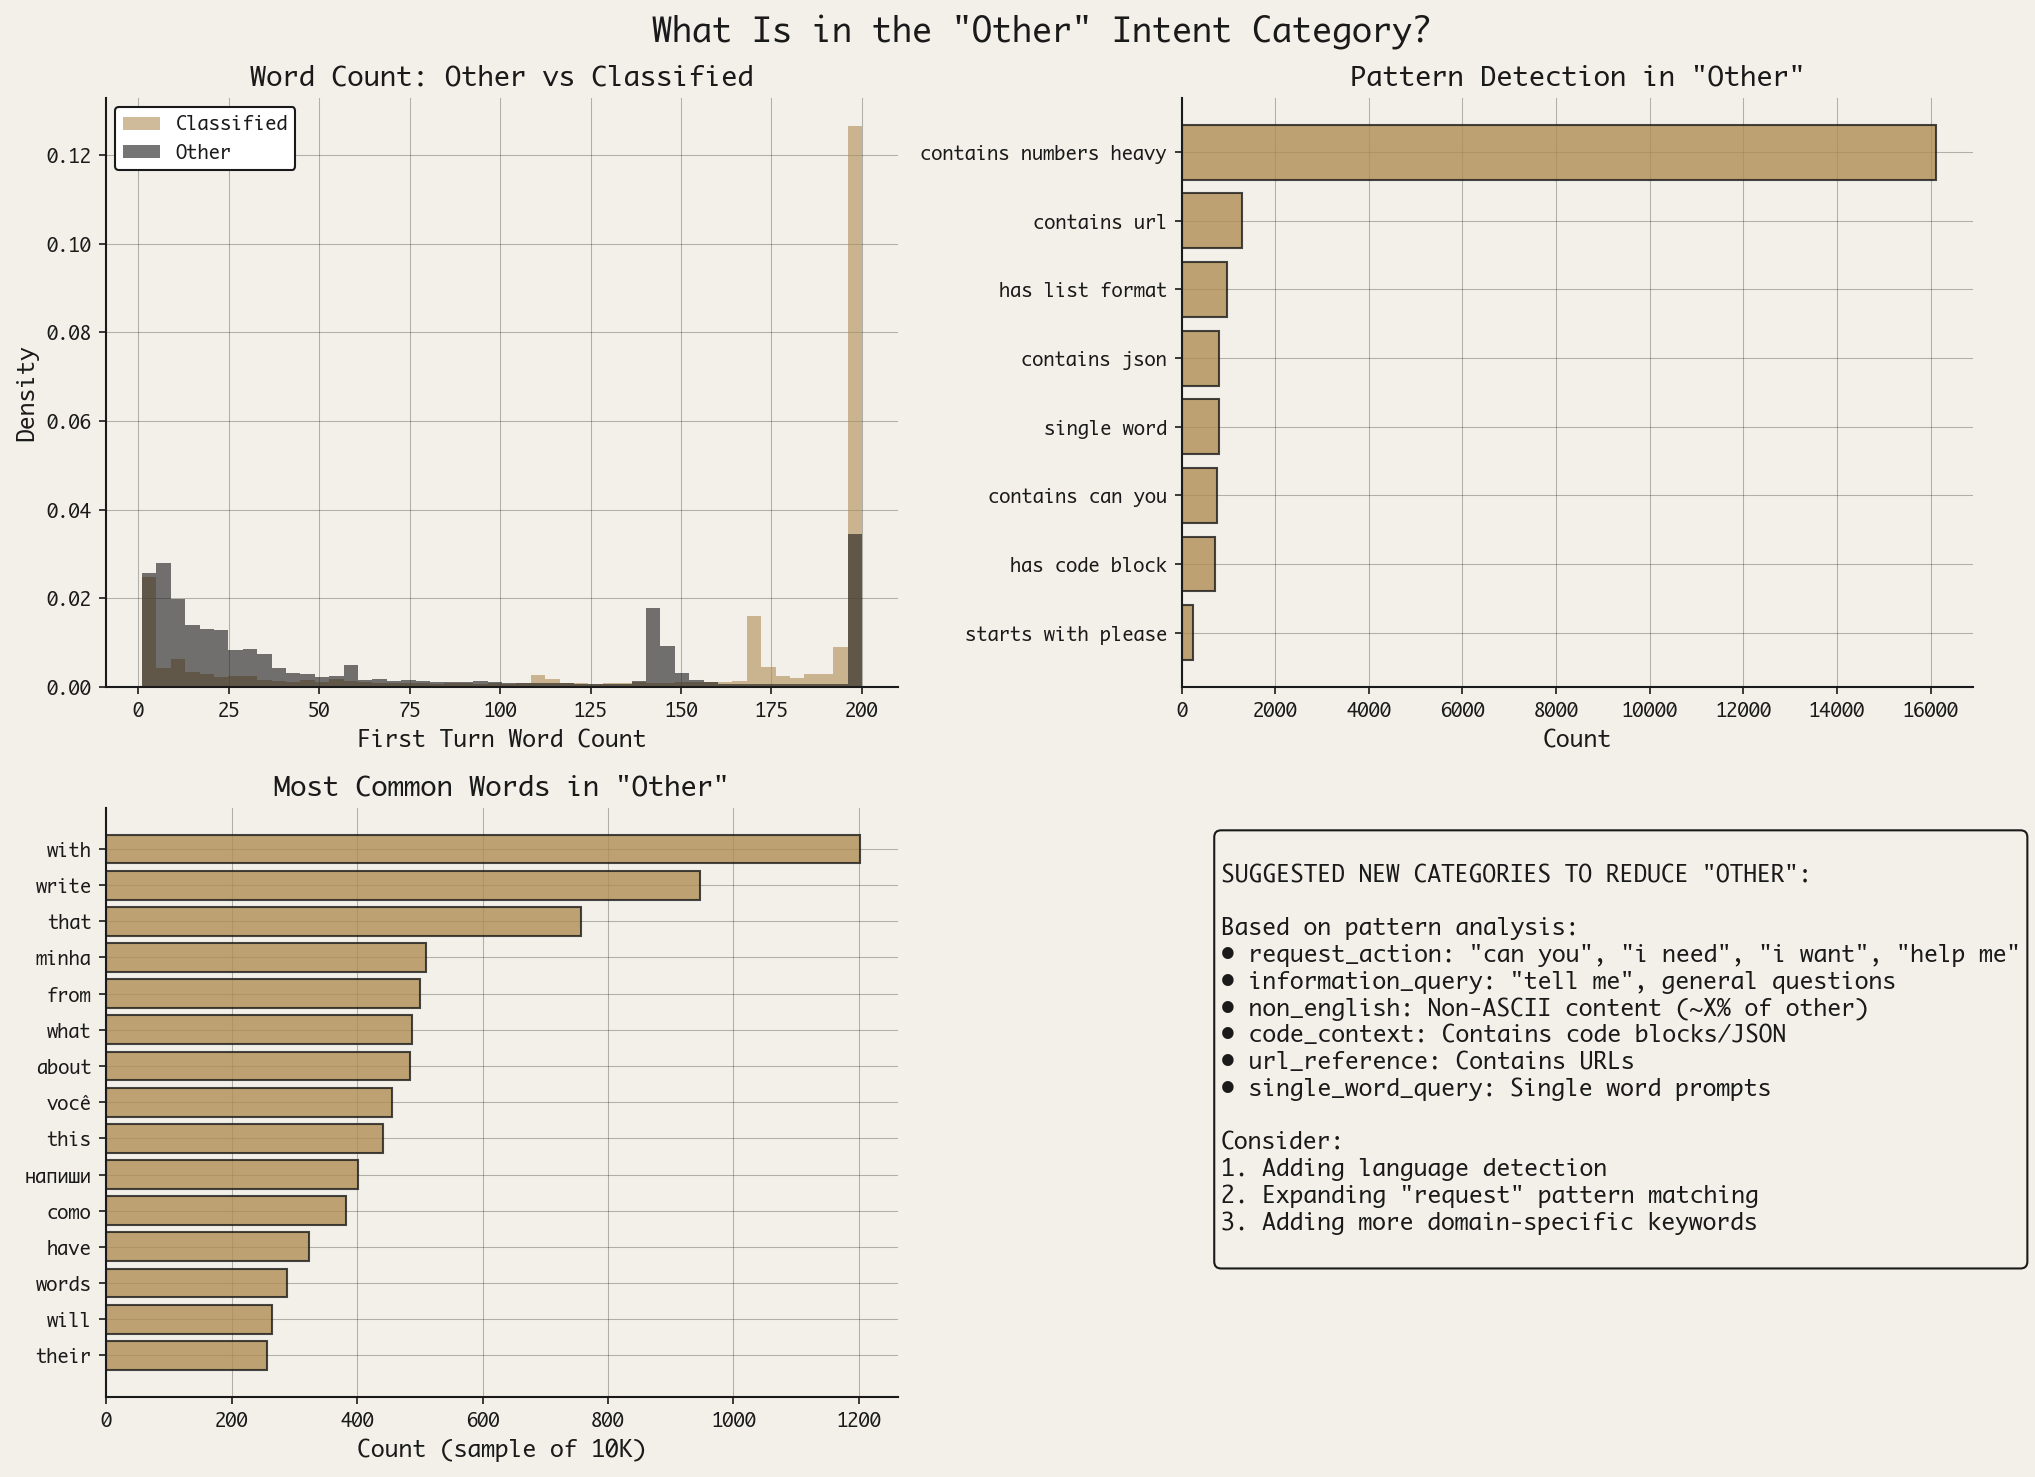


RECOMMENDATION: Review patterns above to identify subcategories worth adding


In [12]:
# ============================================================
# Analyze "Other" Intent Category
# ============================================================
# Goal: Identify subcategories to reduce the "other" bucket

# Get all "other" conversations
other_convos = sample_with_segment.filter(pl.col('intent') == 'other')
print(f"'Other' conversations: {len(other_convos):,} ({100*len(other_convos)/len(sample_with_segment):.1f}%)")

# Sample random examples to understand the content
print("\n" + "="*80)
print("RANDOM SAMPLE OF 'OTHER' FIRST TURNS (10 examples)")
print("="*80)
import random
random.seed(42)
sample_indices = random.sample(range(len(other_convos)), min(10, len(other_convos)))
for i, idx in enumerate(sample_indices):
    text = other_convos['first_turn'][idx][:200]  # First 200 chars
    print(f"\n[{i+1}] {text}...")

# Analyze linguistic patterns in "other"
print("\n" + "="*80)
print("LINGUISTIC ANALYSIS OF 'OTHER' CATEGORY")
print("="*80)

# Length distribution
other_lengths = other_convos['first_turn_words'].to_numpy()
print(f"\nWord count distribution:")
print(f"  Mean: {np.mean(other_lengths):.1f}")
print(f"  Median: {np.median(other_lengths):.1f}")
print(f"  Min: {np.min(other_lengths)}")
print(f"  Max: {np.max(other_lengths)}")

# Language detection heuristics
other_texts = other_convos['first_turn'].to_list()

# Check for non-English content (common non-ASCII patterns)
non_ascii_count = sum(1 for t in other_texts if any(ord(c) > 127 for c in str(t)[:100]))
print(f"\nNon-ASCII content (likely non-English): {non_ascii_count:,} ({100*non_ascii_count/len(other_texts):.1f}%)")

# Check for common patterns we might be missing
pattern_checks = [
    ('contains_url', r'https?://|www\.'),
    ('has_code_block', r'```|`[^`]+`'),
    ('has_list_format', r'^\d+\.|^-\s|^\*\s'),
    ('contains_json', r'\{["\']|[\'"]\}'),
    ('contains_numbers_heavy', r'\d{3,}'),  # 3+ digit numbers
    ('single_word', r'^\s*\w+\s*$'),
    ('starts_with_please', r'^please\b'),
    ('contains_can_you', r'\bcan you\b'),
    ('contains_i_need', r'\bi need\b'),
    ('contains_i_want', r'\bi want\b'),
    ('contains_help_me', r'\bhelp me\b'),
    ('contains_tell_me', r'\btell me\b'),
]

print("\nPattern detection in 'other' category:")
print("-"*50)
for name, pattern in pattern_checks:
    matches = sum(1 for t in other_texts if re.search(pattern, str(t).lower()))
    pct = 100 * matches / len(other_texts)
    print(f"  {name:<25}: {matches:>6,} ({pct:>5.1f}%)")

# Word frequency analysis for "other"
from collections import Counter
all_words = []
for text in other_texts[:10000]:  # Sample for speed
    words = str(text).lower().split()
    all_words.extend(w for w in words if len(w) > 3 and w.isalpha())

word_freq = Counter(all_words).most_common(30)
print("\n" + "="*80)
print("TOP 30 WORDS IN 'OTHER' CATEGORY")
print("="*80)
for word, count in word_freq:
    print(f"  {word:<20}: {count:>6,}")

# Visualize "other" analysis
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('What Is in the "Other" Intent Category?', fontsize=16, fontweight='bold', color=BRAND['ink'])

# 1. Length distribution comparison
ax = axes[0, 0]
classified = sample_with_segment.filter(pl.col('intent') != 'other')['first_turn_words'].clip(1, 200).to_numpy()
other_words = other_convos['first_turn_words'].clip(1, 200).to_numpy()
ax.hist(classified, bins=50, alpha=0.6, label='Classified', color=BRAND['gold'], density=True)
ax.hist(other_words, bins=50, alpha=0.6, label='Other', color=FADED, density=True)
apply_phronos_style(ax, title='Word Count: Other vs Classified', xlabel='First Turn Word Count', ylabel='Density')
ax.legend(facecolor=BRAND['white'], edgecolor=BRAND['ink'])

# 2. Pattern breakdown
ax = axes[0, 1]
pattern_counts = {}
for name, pattern in pattern_checks[:8]:  # Top 8 patterns
    pattern_counts[name] = sum(1 for t in other_texts if re.search(pattern, str(t).lower()))
sorted_patterns = sorted(pattern_counts.items(), key=lambda x: x[1], reverse=True)
names = [p[0].replace('_', ' ') for p in sorted_patterns]
counts = [p[1] for p in sorted_patterns]
ax.barh(names, counts, color=BRAND['gold'], edgecolor=BRAND['ink'], alpha=0.8)
ax.invert_yaxis()
apply_phronos_style(ax, title='Pattern Detection in "Other"', xlabel='Count', ylabel='')

# 3. Top words bar chart
ax = axes[1, 0]
top_words = [w[0] for w in word_freq[:15]]
top_counts = [w[1] for w in word_freq[:15]]
ax.barh(top_words, top_counts, color=BRAND['gold'], edgecolor=BRAND['ink'], alpha=0.8)
ax.invert_yaxis()
apply_phronos_style(ax, title='Most Common Words in "Other"', xlabel='Count (sample of 10K)', ylabel='')

# 4. Suggested new categories
ax = axes[1, 1]
ax.axis('off')
suggested = """
SUGGESTED NEW CATEGORIES TO REDUCE "OTHER":

Based on pattern analysis:
• request_action: "can you", "i need", "i want", "help me"
• information_query: "tell me", general questions
• non_english: Non-ASCII content (~X% of other)
• code_context: Contains code blocks/JSON
• url_reference: Contains URLs
• single_word_query: Single word prompts

Consider:
1. Adding language detection
2. Expanding "request" pattern matching
3. Adding more domain-specific keywords
"""
ax.text(0.05, 0.95, suggested, transform=ax.transAxes, fontsize=11,
        verticalalignment='top', fontfamily='monospace',
        bbox=dict(boxstyle='round', facecolor=BRAND['paper'], edgecolor=BRAND['ink']))

plt.tight_layout()
save_figure(fig, 'other_intent_analysis')
plt.show()

print("\n" + "="*80)
print("RECOMMENDATION: Review patterns above to identify subcategories worth adding")
print("="*80)


Saved: ../outputs/figures/pub_intent_analysis.png


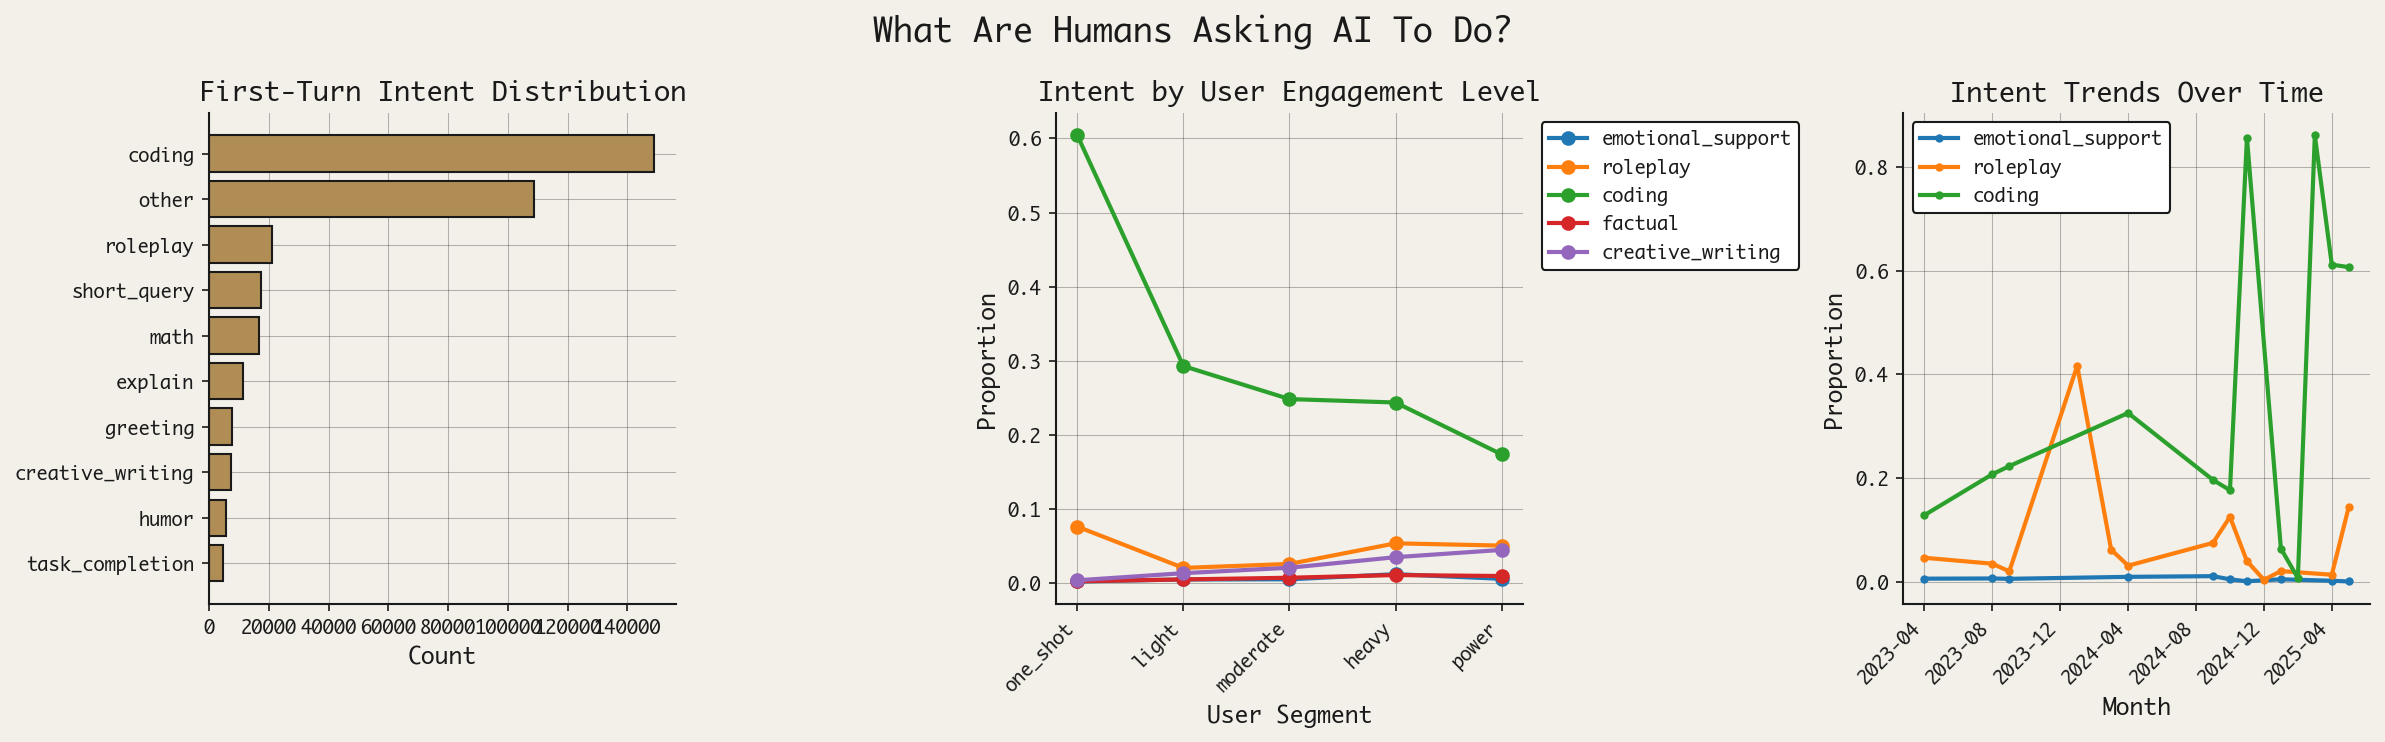

In [26]:
# ============================================================
# Visualize Intent Distribution (3-panel figure)
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('What Are Humans Asking AI To Do?', fontsize=16, fontweight='bold', color=BRAND['ink'])

# 1. Overall distribution
ax = axes[0]
intent_top10 = intent_dist.head(10)
intents = intent_top10['intent'].to_list()
counts = intent_top10['count'].to_list()
y_pos = np.arange(len(intents))
ax.barh(y_pos, counts, color=BRAND['gold'], edgecolor=BRAND['ink'])
ax.set_yticks(y_pos)
ax.set_yticklabels(intents)
ax.invert_yaxis()
apply_phronos_style(ax, title='First-Turn Intent Distribution', xlabel='Count')

# 2. Intent by user segment
ax = axes[1]
segment_order = ['one_shot', 'light', 'moderate', 'heavy', 'power']
key_intents = ['emotional_support', 'roleplay', 'coding', 'factual', 'creative_writing']

# Calculate intent proportions by segment
intent_by_segment = sample_with_segment.filter(
    pl.col('user_segment').is_in(segment_order)
).group_by(['user_segment', 'intent']).agg(
    pl.len().alias('count')
)

segment_totals = sample_with_segment.filter(
    pl.col('user_segment').is_in(segment_order)
).group_by('user_segment').agg(
    pl.len().alias('total')
)

intent_by_segment = intent_by_segment.join(segment_totals, on='user_segment').with_columns([
    (pl.col('count') / pl.col('total')).alias('proportion')
])

# Plot lines for key intents
for intent in key_intents:
    intent_data = intent_by_segment.filter(pl.col('intent') == intent)
    values = []
    for seg in segment_order:
        seg_data = intent_data.filter(pl.col('user_segment') == seg)
        if len(seg_data) > 0:
            values.append(seg_data['proportion'][0])
        else:
            values.append(0)
    ax.plot(segment_order, values, marker='o', label=intent, linewidth=2, markersize=6)

apply_phronos_style(ax, title='Intent by User Engagement Level', xlabel='User Segment', ylabel='Proportion')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', facecolor=BRAND['white'], edgecolor=BRAND['ink'])
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

# 3. Intent over time
ax = axes[2]
# Get year_month from the sample (deduplicated to avoid row explosion)
df_users_time = df_users.select(['conversation_hash', 'year_month']).unique(subset=['conversation_hash'])
sample_with_time = sample_with_segment.join(
    df_users_time,
    on='conversation_hash',
    how='left'
)
del df_users_time

intent_by_month = sample_with_time.group_by(['year_month', 'intent']).agg(
    pl.len().alias('count')
)
month_totals = sample_with_time.group_by('year_month').agg(
    pl.len().alias('total')
)
intent_by_month = intent_by_month.join(month_totals, on='year_month').with_columns([
    (pl.col('count') / pl.col('total')).alias('proportion')
]).sort('year_month')

# Get sorted unique months for proper x-axis ordering
all_months = sorted(sample_with_time['year_month'].unique().drop_nulls().to_list())
month_to_idx = {m: i for i, m in enumerate(all_months)}

# Plot trends for key intents with proper x-axis ordering
for intent in ['emotional_support', 'roleplay', 'coding']:
    intent_data = intent_by_month.filter(pl.col('intent') == intent).sort('year_month')
    if len(intent_data) > 0:
        months = intent_data['year_month'].to_list()
        props = intent_data['proportion'].to_list()
        x_positions = [month_to_idx[m] for m in months if m in month_to_idx]
        y_values = [p for m, p in zip(months, props) if m in month_to_idx]
        ax.plot(x_positions, y_values, label=intent, linewidth=2, marker='o', markersize=3)

# Set proper x-axis labels
ax.set_xticks(range(len(all_months)))
ax.set_xticklabels(all_months)
apply_phronos_style(ax, title='Intent Trends Over Time', xlabel='Month', ylabel='Proportion')
ax.legend(facecolor=BRAND['white'], edgecolor=BRAND['ink'])
# Reduce x-tick density for readability
if len(all_months) > 8:
    tick_step = max(1, len(all_months) // 6)
    tick_indices = list(range(0, len(all_months), tick_step))
    ax.set_xticks(tick_indices)
    ax.set_xticklabels([all_months[i] for i in tick_indices])
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.tight_layout()
save_figure(fig, 'intent_analysis')
plt.show()


---

# Analysis 4: The One-Shot Population

**Question:** Who are the ~80% who never return?


In [32]:
# ============================================================
# One-Shot vs Returner Intent Comparison
# ============================================================
# INTERPRETATION:
# - "returned" = user has MORE THAN 1 conversation total (across full dataset)
# - Positive difference = intent is MORE common among users who return
# - Negative difference = intent is MORE common among one-shot users

# Get first conversations per user with intent
first_convos_with_intent = sample_with_segment.sort('timestamp').group_by('user_id').first()

# Split by return status  
one_shot_users = first_convos_with_intent.filter(~pl.col('returned'))
returning_users = first_convos_with_intent.filter(pl.col('returned'))

print(f"One-shot users: {len(one_shot_users):,} ({100*len(one_shot_users)/len(first_convos_with_intent):.1f}%)")
print(f"Returning users: {len(returning_users):,} ({100*len(returning_users)/len(first_convos_with_intent):.1f}%)")

# SANITY CHECK: Verify the 'returned' field is based on user's full history
print("\n--- SANITY CHECK ---")
# Sample a few users and verify their return status
sample_check = first_convos_with_intent.head(5).select(['user_id', 'returned'])
for row in sample_check.iter_rows(named=True):
    user_full_count = user_stats.filter(pl.col('user_id') == row['user_id'])['n_conversations'][0]
    expected_returned = user_full_count > 1
    status = "✓" if row['returned'] == expected_returned else "✗ BUG"
    print(f"  User {row['user_id'][:8]}...: returned={row['returned']}, n_convos={user_full_count} {status}")
print("--- END SANITY CHECK ---\n")

# Intent distribution comparison
one_shot_intents = one_shot_users['intent'].value_counts().with_columns([
    (pl.col('count') / pl.col('count').sum()).alias('one_shot_pct')
]).rename({'count': 'one_shot_count'})

returner_intents = returning_users['intent'].value_counts().with_columns([
    (pl.col('count') / pl.col('count').sum()).alias('returner_pct')
]).rename({'count': 'returner_count'})

# Merge for comparison
intent_comparison = one_shot_intents.join(returner_intents, on='intent', how='outer').fill_null(0)
intent_comparison = intent_comparison.with_columns([
    (pl.col('returner_pct') - pl.col('one_shot_pct')).alias('difference')
]).sort('difference', descending=True)

print("\nIntent Comparison (Returners - One-Shot):")
print("="*70)
print(f"{'Intent':<20} {'One-Shot %':<15} {'Returner %':<15} {'Difference':<15}")
print("-"*70)
for row in intent_comparison.iter_rows(named=True):
    print(f"{row['intent']:<20} {100*row['one_shot_pct']:>10.1f}%     {100*row['returner_pct']:>10.1f}%     {100*row['difference']:>+10.1f}%")


One-shot users: 166,272 (85.6%)
Returning users: 28,052 (14.4%)

--- SANITY CHECK ---
  User 2e834562...: returned=False, n_convos=1 ✓
  User 27822c9e...: returned=False, n_convos=1 ✓
  User 3d2a6b42...: returned=False, n_convos=1 ✓
  User c55f5403...: returned=False, n_convos=1 ✓
  User 583f33b1...: returned=False, n_convos=1 ✓
--- END SANITY CHECK ---


Intent Comparison (Returners - One-Shot):
Intent               One-Shot %      Returner %      Difference     
----------------------------------------------------------------------
other                      13.8%           36.1%          +22.3%
short_query                 2.9%           11.2%           +8.3%
greeting                    0.9%            3.6%           +2.7%
creative_writing            0.4%            1.9%           +1.4%
how_to                      0.5%            1.5%           +1.0%
math                        3.3%            4.3%           +0.9%
brainstorm                  0.2%            0.9%           +0.7%
rewri

/var/folders/c2/g0c1jz_n4zx8d5xdtn4t9xy00000gn/T/ipykernel_74768/3645150995.py:40: DeprecationWarning: use of `how='outer'` should be replaced with `how='full'`.
(Deprecated in version 0.20.29)
  intent_comparison = one_shot_intents.join(returner_intents, on='intent', how='outer').fill_null(0)


Saved: ../outputs/figures/pub_one_shot_analysis.png


/var/folders/c2/g0c1jz_n4zx8d5xdtn4t9xy00000gn/T/ipykernel_74768/3462599860.py:43: UserWarning: Glyph 8592 (\N{LEFTWARDS ARROW}) missing from font(s) Monaco.
  plt.tight_layout()
/var/folders/c2/g0c1jz_n4zx8d5xdtn4t9xy00000gn/T/ipykernel_74768/2969407601.py:120: UserWarning: Glyph 8592 (\N{LEFTWARDS ARROW}) missing from font(s) Monaco.
  fig.savefig(path, dpi=300, bbox_inches='tight',
/Users/vishal/Library/Python/3.11/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8592 (\N{LEFTWARDS ARROW}) missing from font(s) Monaco.
  fig.canvas.print_figure(bytes_io, **kw)


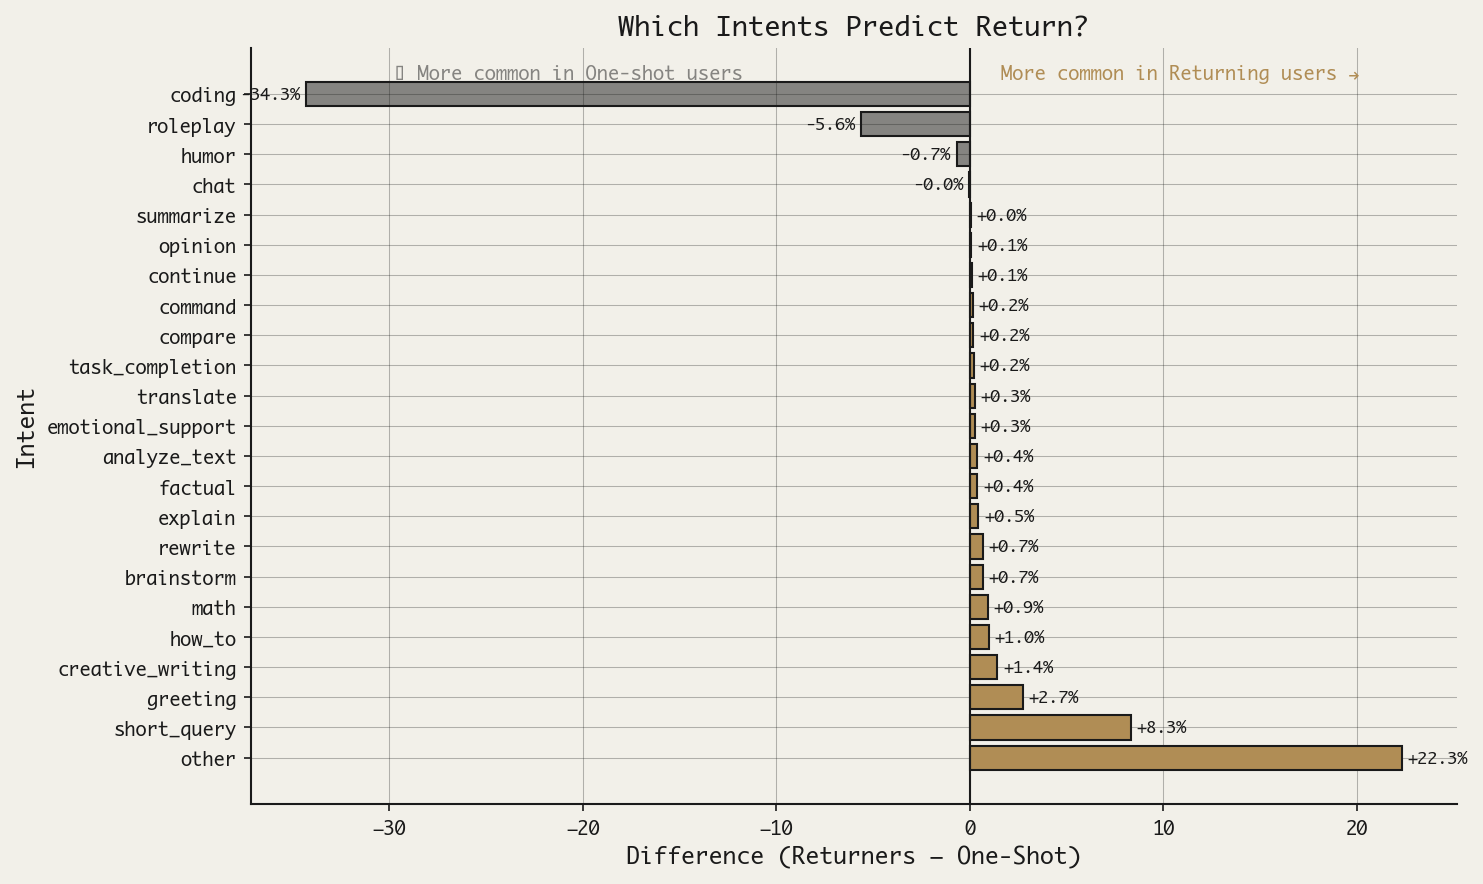

In [23]:
# ============================================================
# Visualize One-Shot Analysis (Diverging Bar Chart)
# ============================================================

fig, ax = plt.subplots(figsize=(10, 6))

# Prepare data
intents = intent_comparison['intent'].to_list()
differences = intent_comparison['difference'].to_list()

# Colors based on direction
colors = [BRAND['gold'] if d > 0 else FADED for d in differences]

# Create horizontal bar chart
y_pos = np.arange(len(intents))
bars = ax.barh(y_pos, [d * 100 for d in differences], color=colors, edgecolor=BRAND['ink'])

ax.set_yticks(y_pos)
ax.set_yticklabels(intents)
ax.axvline(0, color=BRAND['ink'], linewidth=1)

# Add annotations
for i, (intent, diff) in enumerate(zip(intents, differences)):
    label = 'More in returners' if diff > 0 else 'More in one-shot'
    x_pos = diff * 100
    ha = 'left' if diff > 0 else 'right'
    offset = 0.3 if diff > 0 else -0.3
    ax.text(x_pos + offset, i, f'{diff*100:+.1f}%', va='center', ha=ha, fontsize=8, color=BRAND['ink'])

apply_phronos_style(ax, 
                    title='Which Intents Predict Return?', 
                    xlabel='Difference (Returners − One-Shot)', 
                    ylabel='Intent')

# Add legend annotation
ax.annotate('← More common in One-shot users', 
            xy=(ax.get_xlim()[0] * 0.8, len(intents) - 0.5),
            fontsize=9, color=FADED, ha='left')
ax.annotate('More common in Returning users →', 
            xy=(ax.get_xlim()[1] * 0.8, len(intents) - 0.5),
            fontsize=9, color=BRAND['gold'], ha='right')

plt.tight_layout()
save_figure(fig, 'one_shot_analysis')
plt.show()


---

# Analysis 5: Temporal Drift

**Question:** How has the way humans initiate AI conversations changed over time?


In [16]:
# ============================================================
# Calculate Monthly Temporal Metrics
# ============================================================

# Add text features to sample_with_time
sample_temporal = sample_with_time.with_columns([
    pl.col('first_turn').str.contains(r'\?').alias('has_question_mark'),
])

# Calculate politeness for temporal analysis
sample_temporal = sample_temporal.with_columns([
    pl.col('first_turn').map_elements(
        lambda x: any(w in str(x).lower() for w in ['please', 'thank', 'could you', 'would you']),
        return_dtype=pl.Boolean
    ).alias('has_politeness')
])

# Monthly aggregations
monthly_metrics = sample_temporal.group_by('year_month').agg([
    pl.col('first_turn_words').mean().alias('avg_words'),
    pl.col('first_turn_chars').mean().alias('avg_chars'),
    pl.col('has_question_mark').mean().alias('question_rate'),
    pl.col('has_politeness').mean().alias('politeness_rate'),
    pl.len().alias('total_conversations'),
    pl.col('user_id').n_unique().alias('unique_users'),
]).sort('year_month')

print("Monthly Metrics Calculated:")
print(f"  Months covered: {len(monthly_metrics)}")
print(f"  Date range: {monthly_metrics['year_month'][0]} to {monthly_metrics['year_month'][-1]}")
print(f"\nSample metrics (latest month):")
latest = monthly_metrics.row(-1, named=True)  # Get last row as dict with scalar values
print(f"  Avg words: {latest['avg_words']:.1f}")
print(f"  Question rate: {100*latest['question_rate']:.1f}%")
print(f"  Politeness rate: {100*latest['politeness_rate']:.1f}%")


Monthly Metrics Calculated:
  Months covered: 26
  Date range: 2023-04 to 2025-05

Sample metrics (latest month):
  Avg words: 179.4
  Question rate: 7.3%
  Politeness rate: 12.2%


Saved: ../outputs/figures/pub_temporal_trends.png


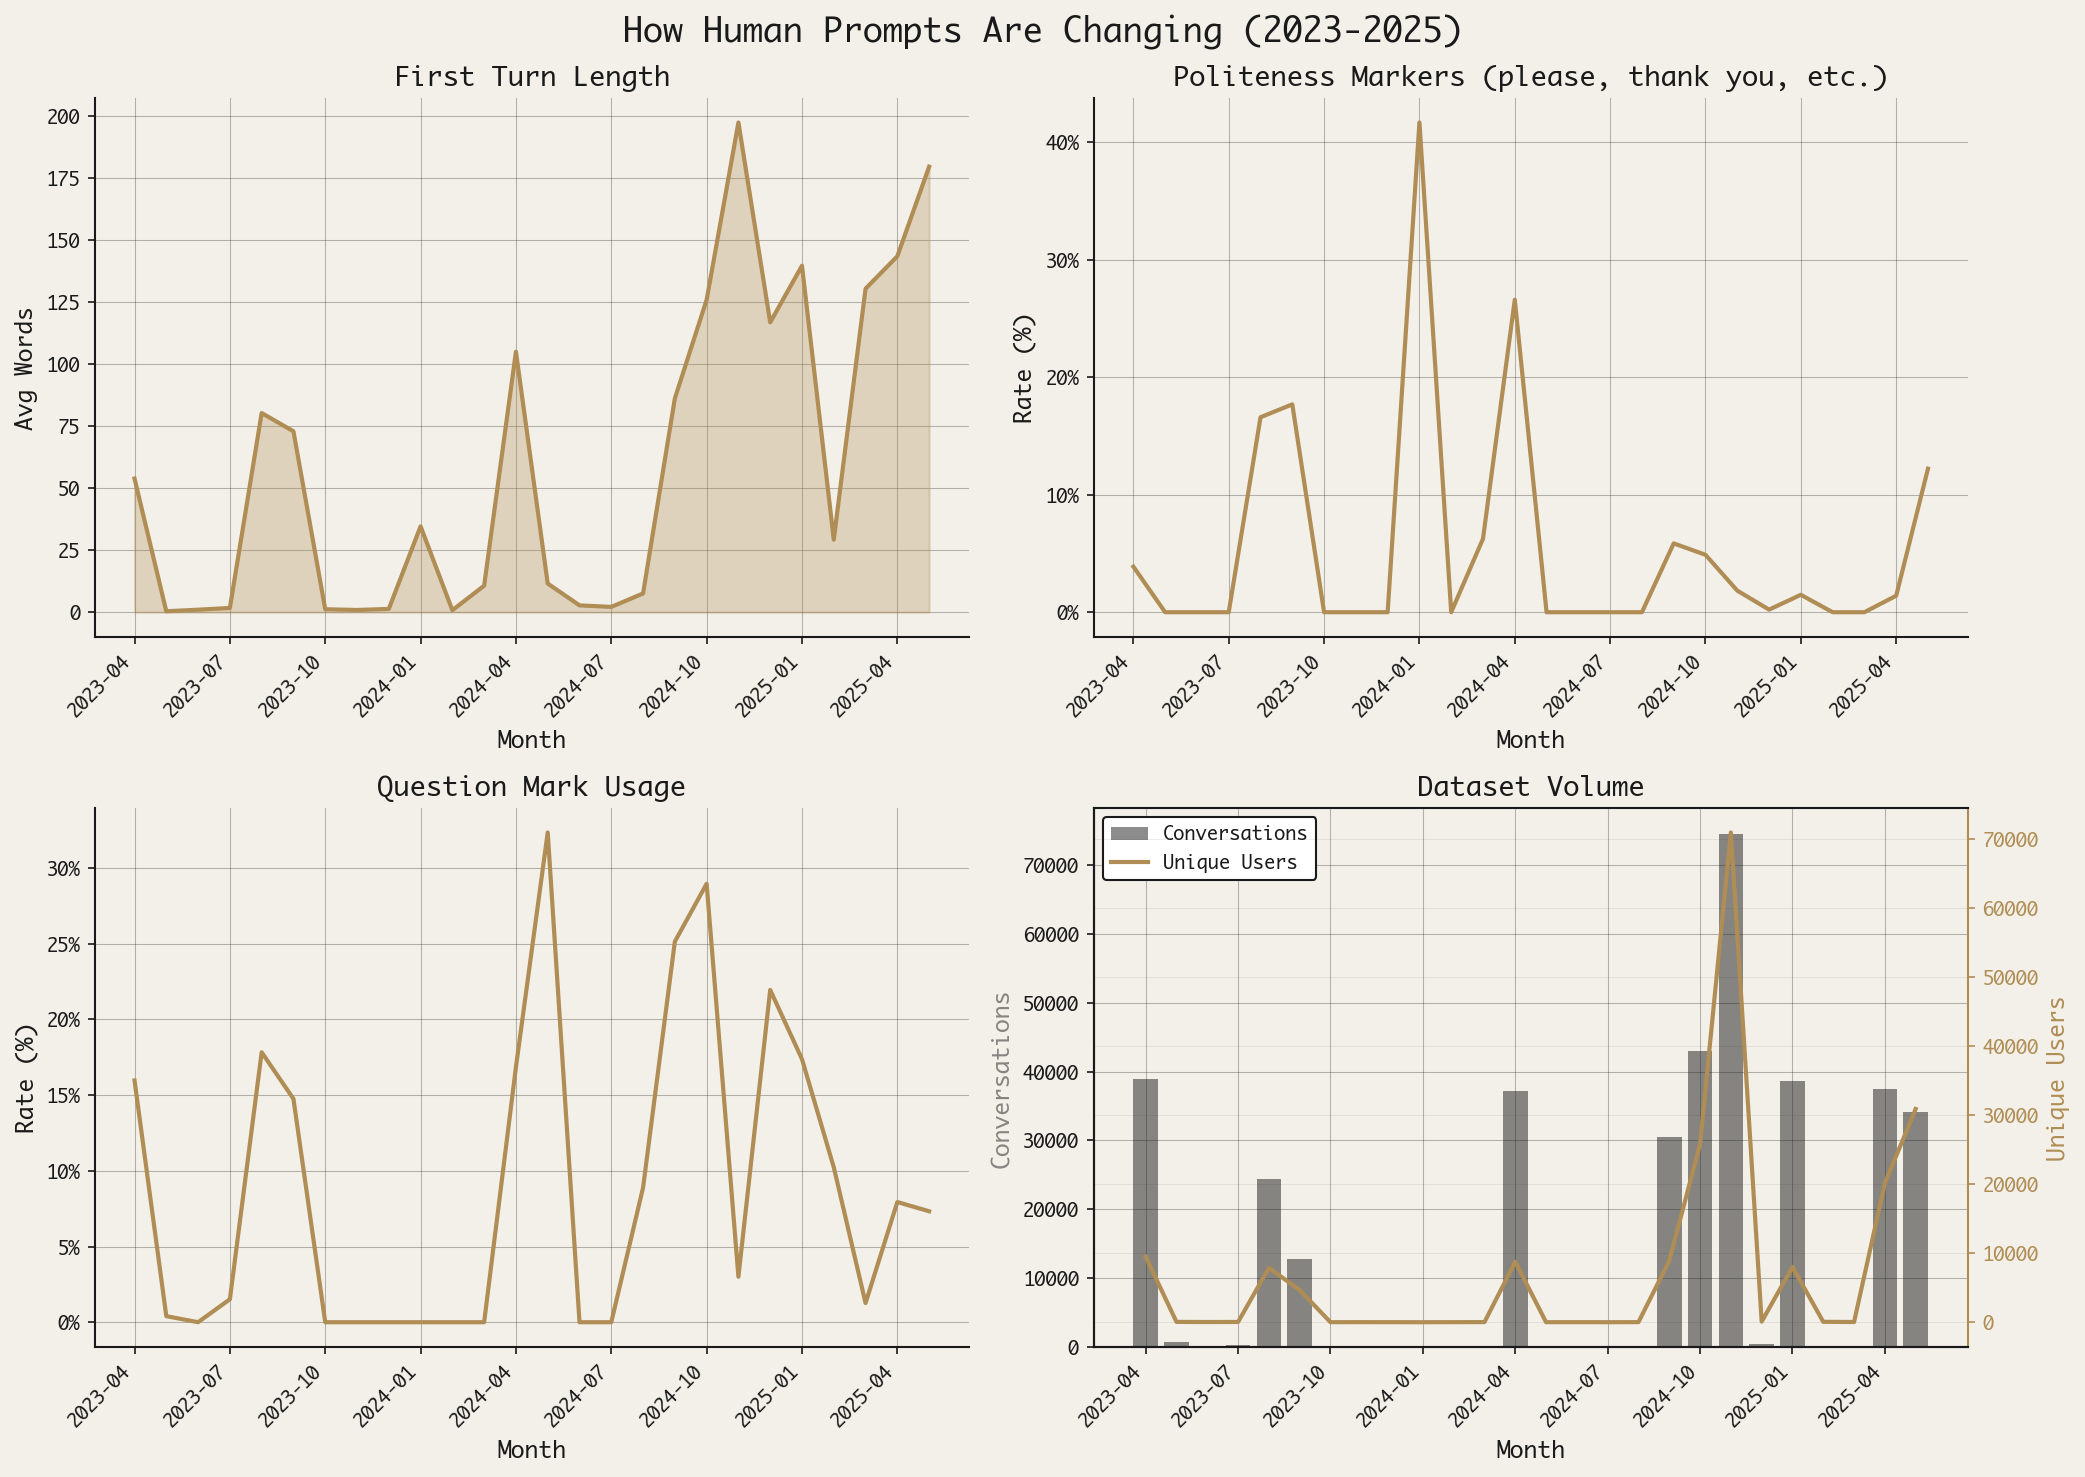

In [24]:
# ============================================================
# Visualize Temporal Trends (4-panel figure)
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('How Human Prompts Are Changing (2023-2025)', fontsize=16, fontweight='bold', color=BRAND['ink'])

months = monthly_metrics['year_month'].to_list()

# 1. Average prompt length
ax = axes[0, 0]
ax.plot(months, monthly_metrics['avg_words'].to_list(), color=BRAND['gold'], linewidth=2)
ax.fill_between(months, monthly_metrics['avg_words'].to_list(), alpha=0.3, color=BRAND['gold'])
apply_phronos_style(ax, title='First Turn Length', xlabel='Month', ylabel='Avg Words')
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
# Reduce x-tick density
ax.set_xticks(ax.get_xticks()[::3])

# 2. Politeness rate
ax = axes[0, 1]
politeness_pct = [r * 100 for r in monthly_metrics['politeness_rate'].to_list()]
ax.plot(months, politeness_pct, color=BRAND['gold'], linewidth=2)
apply_phronos_style(ax, title='Politeness Markers (please, thank you, etc.)', xlabel='Month', ylabel='Rate (%)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0f}%'))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
ax.set_xticks(ax.get_xticks()[::3])

# 3. Question rate
ax = axes[1, 0]
question_pct = [r * 100 for r in monthly_metrics['question_rate'].to_list()]
ax.plot(months, question_pct, color=BRAND['gold'], linewidth=2)
apply_phronos_style(ax, title='Question Mark Usage', xlabel='Month', ylabel='Rate (%)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0f}%'))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
ax.set_xticks(ax.get_xticks()[::3])

# 4. Volume (conversations and unique users)
ax = axes[1, 1]
ax.bar(months, monthly_metrics['total_conversations'].to_list(), alpha=0.5, color=FADED, label='Conversations')
ax2 = ax.twinx()
ax2.plot(months, monthly_metrics['unique_users'].to_list(), color=BRAND['gold'], linewidth=2, label='Unique Users')
ax.set_ylabel('Conversations', color=FADED)
ax2.set_ylabel('Unique Users', color=BRAND['gold'])
apply_phronos_style(ax, title='Dataset Volume', xlabel='Month')
ax2.spines['right'].set_color(BRAND['gold'])
ax2.tick_params(axis='y', colors=BRAND['gold'])
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
ax.set_xticks(ax.get_xticks()[::3])

# Combined legend
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc='upper left', facecolor=BRAND['white'], edgecolor=BRAND['ink'])

plt.tight_layout()
save_figure(fig, 'temporal_trends')
plt.show()


---

# Analysis 6: The Two-Turn Dance

**Question:** What happens in the ~80% of conversations that are exactly 2 turns?


In [25]:
# ============================================================
# Analyze Two-Turn Conversations
# ============================================================

# Get two-turn conversations from sample (deduplicated to avoid row explosion)
df_users_turns = df_users.select(['conversation_hash', 'n_turns']).unique(subset=['conversation_hash'])
two_turn_sample = raw_sample.join(
    df_users_turns,
    on='conversation_hash',
    how='left'
).filter(pl.col('n_turns') == 2)
del df_users_turns

print(f"Two-turn conversations: {len(two_turn_sample):,} ({100*len(two_turn_sample)/len(raw_sample):.1f}% of sample)")

# Calculate response ratio
two_turn_sample = two_turn_sample.with_columns([
    (pl.col('first_ai_words') / pl.col('first_turn_words').clip(1, None)).alias('response_ratio')
])

# Classify two-turn patterns
def classify_two_turn_pattern(row):
    """Classify the interaction pattern of a 2-turn exchange."""
    user_words = row['first_turn_words'] or 0
    ai_words = row['first_ai_words'] or 0
    ratio = row['response_ratio'] or 0
    
    # Quick question → Long answer
    if user_words < 20 and ai_words > 100:
        return 'question_answer'
    
    # Long prompt → Execution
    if user_words > 100 and ratio < 2:
        return 'task_completion'
    
    # Short both ways (greeting, simple exchange)
    if user_words < 20 and ai_words < 50:
        return 'brief_exchange'
    
    # Long both ways (detailed request, detailed response)
    if user_words > 50 and ai_words > 200:
        return 'detailed_exchange'
    
    return 'other'

# Apply pattern classification
two_turn_patterns = []
for row in two_turn_sample.iter_rows(named=True):
    two_turn_patterns.append(classify_two_turn_pattern(row))

two_turn_sample = two_turn_sample.with_columns([
    pl.Series('pattern', two_turn_patterns)
])

# Pattern distribution
pattern_dist = two_turn_sample['pattern'].value_counts().sort('count', descending=True)
print("\nTwo-Turn Patterns:")
print("="*50)
for row in pattern_dist.iter_rows(named=True):
    pct = 100 * row['count'] / len(two_turn_sample)
    print(f"  {row['pattern']:<20}: {row['count']:>8,} ({pct:>5.1f}%)")


Two-turn conversations: 305,590 (81.8% of sample)

Two-Turn Patterns:
  task_completion     :  212,857 ( 69.7%)
  other               :   42,357 ( 13.9%)
  brief_exchange      :   23,977 (  7.8%)
  question_answer     :   18,258 (  6.0%)
  detailed_exchange   :    8,141 (  2.7%)


Saved: ../outputs/figures/pub_two_turn_analysis.png


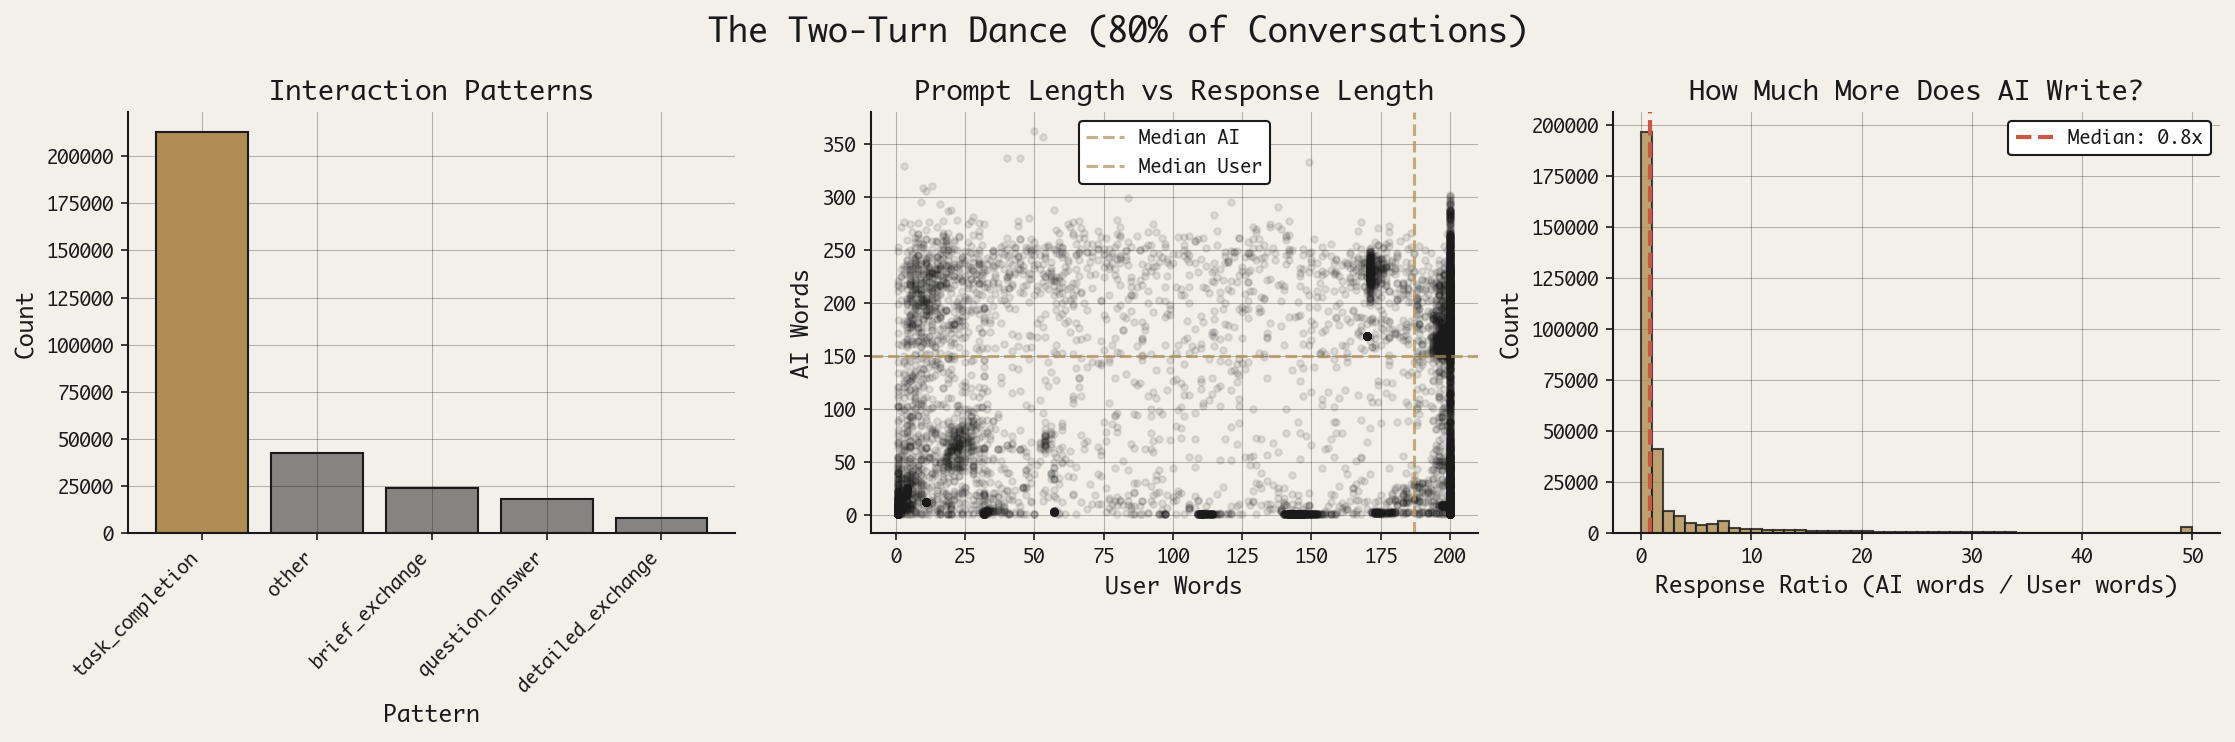

In [19]:
# ============================================================
# Visualize Two-Turn Patterns (3-panel figure)
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('The Two-Turn Dance (80% of Conversations)', fontsize=16, fontweight='bold', color=BRAND['ink'])

# 1. Pattern distribution
ax = axes[0]
patterns = pattern_dist['pattern'].to_list()
counts = pattern_dist['count'].to_list()
colors = [BRAND['gold'] if i == 0 else FADED for i in range(len(patterns))]
ax.bar(patterns, counts, color=colors, edgecolor=BRAND['ink'])
apply_phronos_style(ax, title='Interaction Patterns', xlabel='Pattern', ylabel='Count')
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

# 2. User vs AI word count scatter
ax = axes[1]
# Sample for performance
scatter_sample = two_turn_sample.sample(n=min(10000, len(two_turn_sample)), seed=42)
user_words = scatter_sample['first_turn_words'].clip(1, 200).to_numpy()
ai_words = scatter_sample['first_ai_words'].clip(1, 1000).to_numpy()
ax.scatter(user_words, ai_words, alpha=0.1, s=10, color=BRAND['ink'])
ax.axhline(y=np.median(scatter_sample['first_ai_words'].to_numpy()), color=BRAND['gold'], linestyle='--', alpha=0.7, label='Median AI')
ax.axvline(x=np.median(scatter_sample['first_turn_words'].to_numpy()), color=BRAND['gold'], linestyle='--', alpha=0.7, label='Median User')
apply_phronos_style(ax, title='Prompt Length vs Response Length', xlabel='User Words', ylabel='AI Words')
ax.legend(facecolor=BRAND['white'], edgecolor=BRAND['ink'])

# 3. Response ratio distribution
ax = axes[2]
ratios = two_turn_sample['response_ratio'].clip(0, 50).to_numpy()
ax.hist(ratios, bins=50, color=BRAND['gold'], edgecolor=BRAND['ink'], alpha=0.8)
median_ratio = np.median(two_turn_sample['response_ratio'].to_numpy())
ax.axvline(x=median_ratio, color=BRAND['alert'], linestyle='--', linewidth=2, 
           label=f'Median: {median_ratio:.1f}x')
apply_phronos_style(ax, title='How Much More Does AI Write?', xlabel='Response Ratio (AI words / User words)', ylabel='Count')
ax.legend(facecolor=BRAND['white'], edgecolor=BRAND['ink'])

plt.tight_layout()
save_figure(fig, 'two_turn_analysis')
plt.show()


In [27]:
# ============================================================
# Two-Turn Summary Statistics
# ============================================================

# Calculate summary stats
user_words_median = two_turn_sample['first_turn_words'].median()
ai_words_median = two_turn_sample['first_ai_words'].median()
ratio_median = two_turn_sample['response_ratio'].median()
most_common_pattern = pattern_dist['pattern'][0]
question_rate = two_turn_sample['first_turn'].str.contains(r'\?').mean()

summary = {
    'Metric': [
        'Median user words',
        'Median AI words',
        'Median response ratio',
        'Most common pattern',
        'Question mark rate',
    ],
    'Value': [
        f"{user_words_median:.0f}",
        f"{ai_words_median:.0f}",
        f"{ratio_median:.1f}x",
        most_common_pattern,
        f"{100*question_rate:.1f}%",
    ]
}

print("="*50)
print("TABLE: Two-Turn Conversation Summary")
print("="*50)
print(f"\n{'Metric':<30} {'Value':<20}")
print("-"*50)
for i in range(len(summary['Metric'])):
    print(f"{summary['Metric'][i]:<30} {summary['Value'][i]:<20}")


TABLE: Two-Turn Conversation Summary

Metric                         Value               
--------------------------------------------------
Median user words              188                 
Median AI words                152                 
Median response ratio          0.8x                
Most common pattern            task_completion     
Question mark rate             13.4%               


---

# Summary Dashboard


Saved: ../outputs/figures/pub_summary_dashboard.png


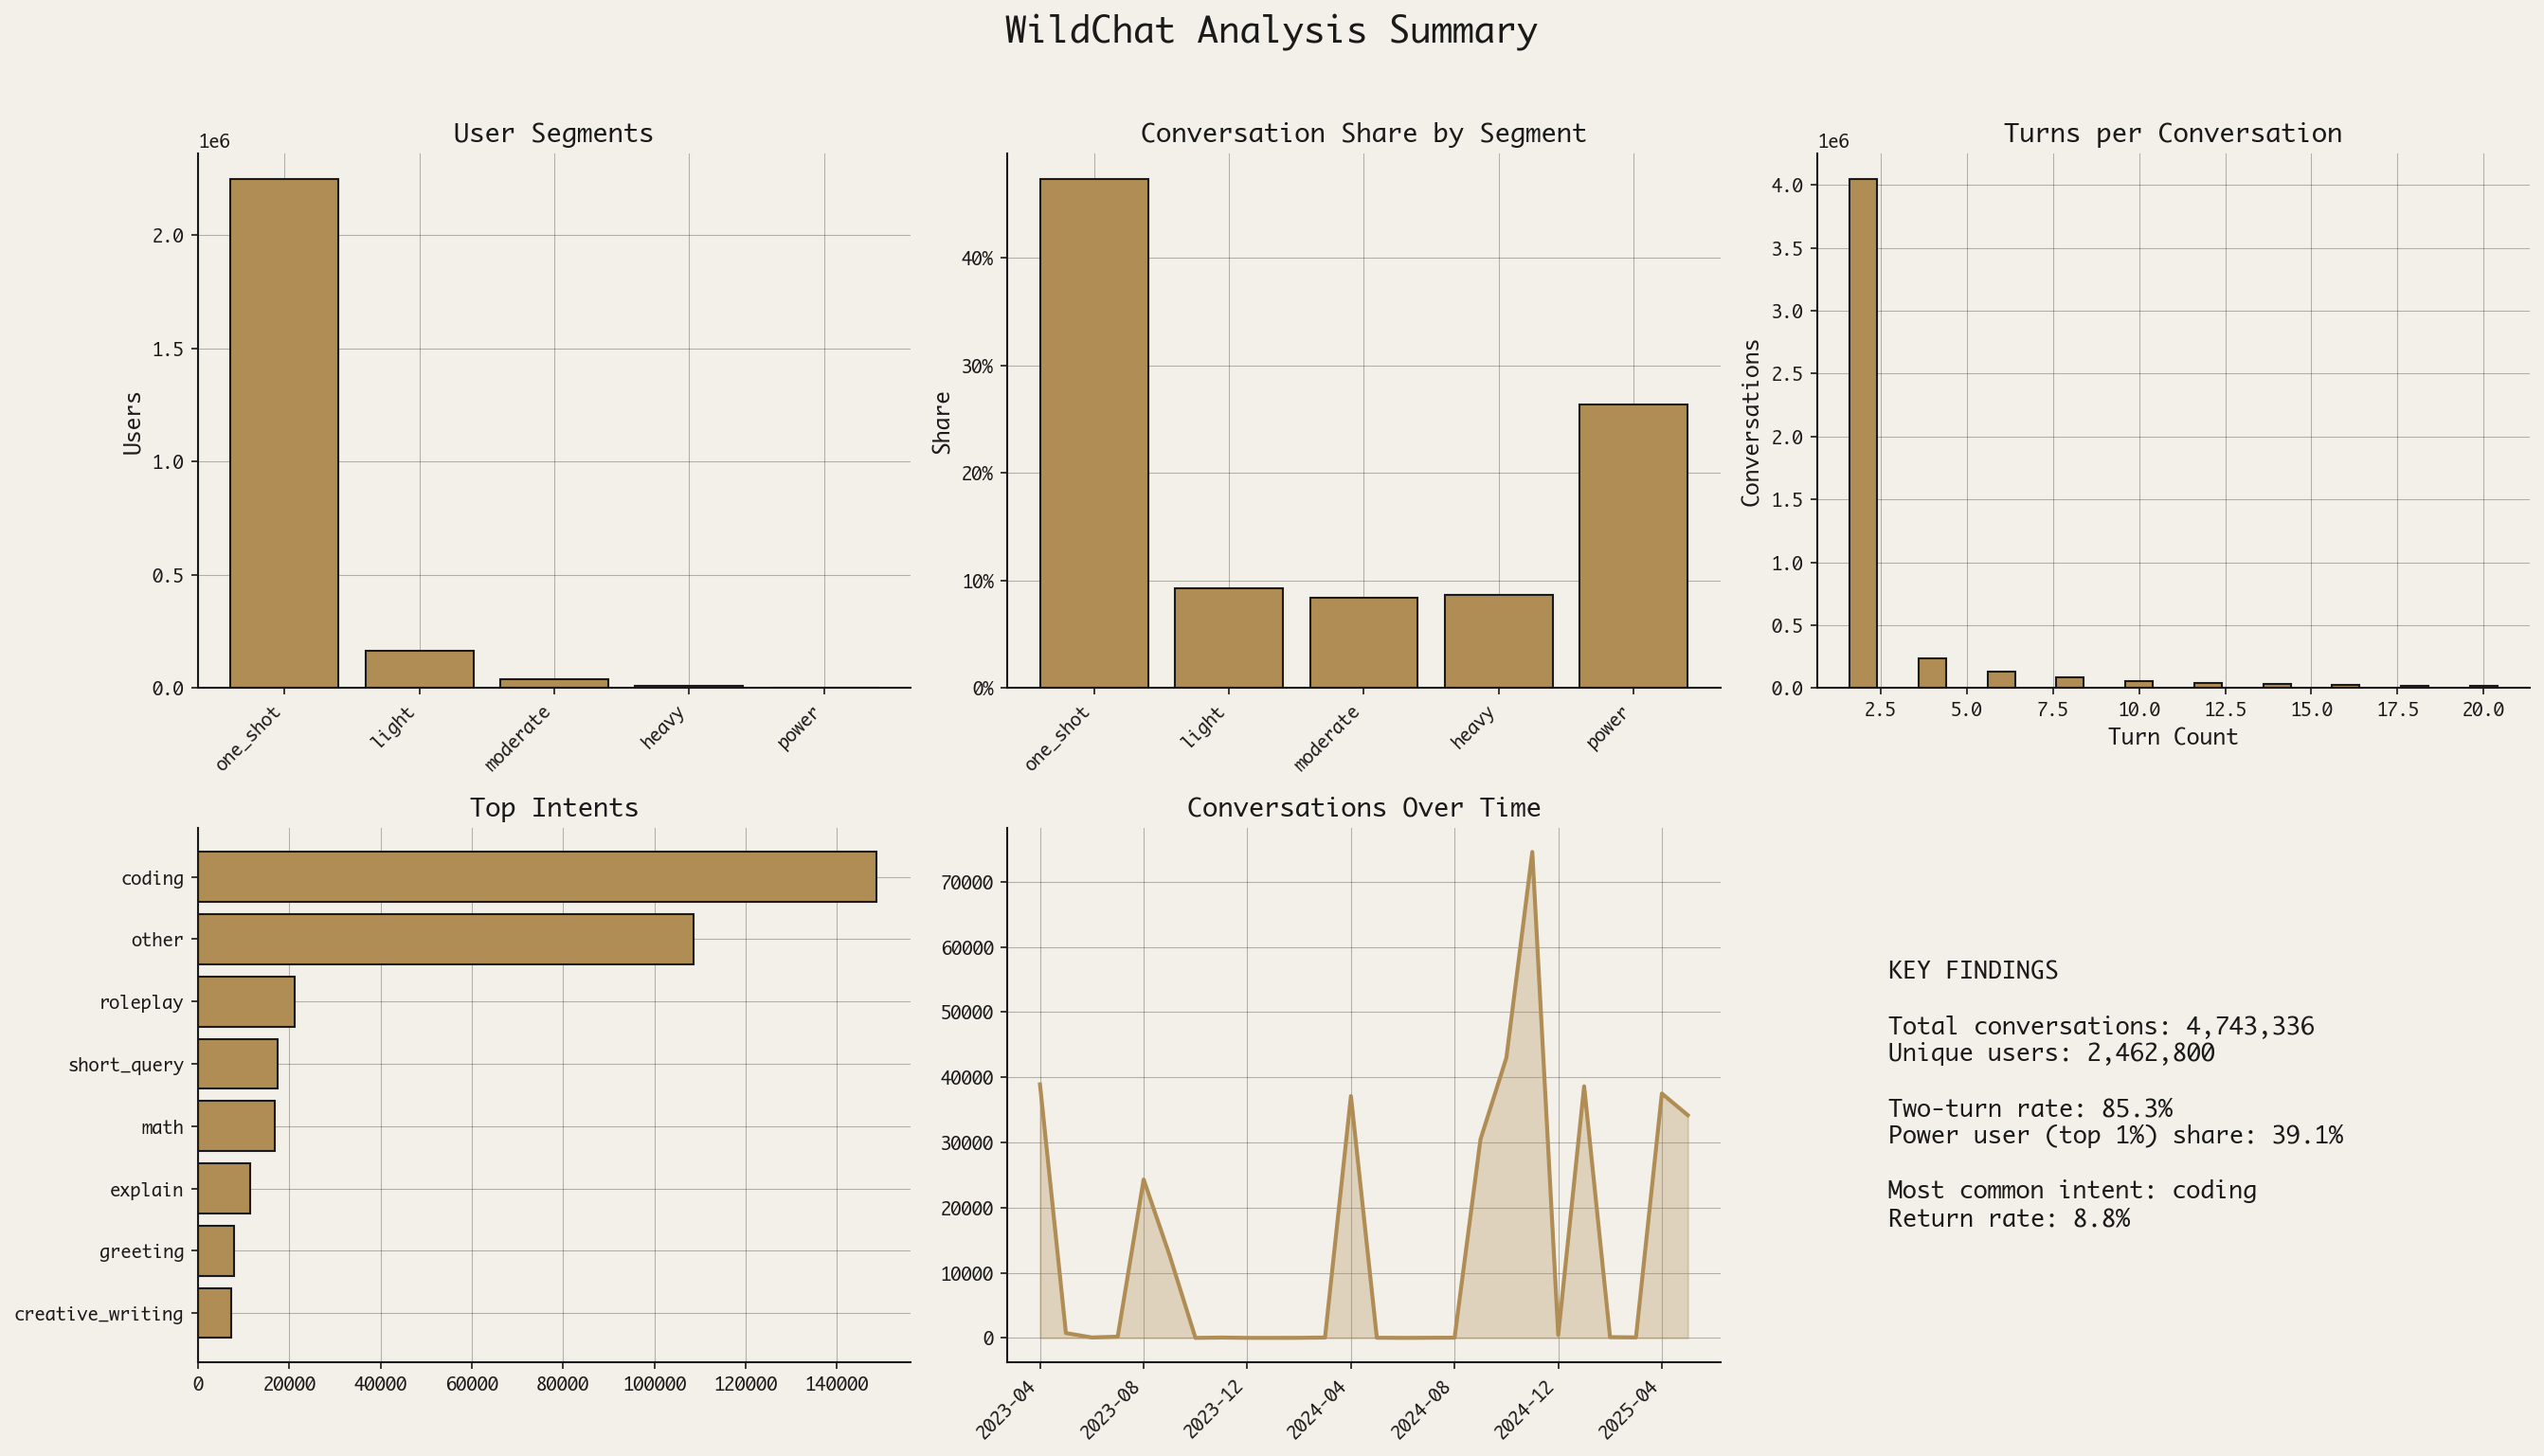

In [29]:
# ============================================================
# Summary Dashboard (6-panel overview)
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('WildChat Analysis Summary', fontsize=18, fontweight='bold', color=BRAND['ink'], y=1.02)

# 1. User segments
ax = axes[0, 0]
segment_order = ['one_shot', 'light', 'moderate', 'heavy', 'power']
segment_counts = segment_summary.filter(pl.col('user_segment').is_in(segment_order))
# Reorder
segment_dict = {row['user_segment']: row['n_users'] for row in segment_counts.iter_rows(named=True)}
ordered_counts = [segment_dict.get(s, 0) for s in segment_order]
ax.bar(segment_order, ordered_counts, color=BRAND['gold'], edgecolor=BRAND['ink'])
apply_phronos_style(ax, title='User Segments', ylabel='Users')
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

# 2. Conversation contribution by segment
ax = axes[0, 1]
conv_dict = {row['user_segment']: row['total_conversations'] for row in segment_counts.iter_rows(named=True)}
ordered_convos = [conv_dict.get(s, 0) for s in segment_order]
total_convos = sum(ordered_convos)
ordered_pct = [c / total_convos for c in ordered_convos]
ax.bar(segment_order, ordered_pct, color=BRAND['gold'], edgecolor=BRAND['ink'])
apply_phronos_style(ax, title='Conversation Share by Segment', ylabel='Share')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

# 3. Turn count distribution
ax = axes[0, 2]
turn_dist = df_users['n_turns'].value_counts().sort('n_turns').head(10)
ax.bar(turn_dist['n_turns'].to_list(), turn_dist['count'].to_list(), color=BRAND['gold'], edgecolor=BRAND['ink'])
apply_phronos_style(ax, title='Turns per Conversation', xlabel='Turn Count', ylabel='Conversations')

# 4. Top intents
ax = axes[1, 0]
intent_top8 = intent_dist.head(8)
y_pos = np.arange(len(intent_top8))
ax.barh(y_pos, intent_top8['count'].to_list(), color=BRAND['gold'], edgecolor=BRAND['ink'])
ax.set_yticks(y_pos)
ax.set_yticklabels(intent_top8['intent'].to_list())
ax.invert_yaxis()
apply_phronos_style(ax, title='Top Intents')

# 5. Monthly volume trend
ax = axes[1, 1]
summary_months = monthly_metrics['year_month'].to_list()
summary_convos = monthly_metrics['total_conversations'].to_list()
x_positions = range(len(summary_months))
ax.plot(x_positions, summary_convos, color=BRAND['gold'], linewidth=2)
ax.fill_between(x_positions, summary_convos, alpha=0.3, color=BRAND['gold'])
ax.set_xticks(x_positions)
ax.set_xticklabels(summary_months)
apply_phronos_style(ax, title='Conversations Over Time')
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
# Reduce tick density
if len(summary_months) > 8:
    tick_step = max(1, len(summary_months) // 6)
    tick_indices = list(range(0, len(summary_months), tick_step))
    ax.set_xticks(tick_indices)
    ax.set_xticklabels([summary_months[i] for i in tick_indices])

# 6. Key stats text box
ax = axes[1, 2]
ax.axis('off')

# Calculate key metrics
total_conversations = len(df_users)
unique_users = df_users['user_id'].n_unique()
two_turn_rate = (df_users['n_turns'] == 2).mean()
power_user_share = len(power_user_convs) / len(df_users)
top_intent = intent_dist['intent'][0]
return_rate = user_stats['returned'].mean()

stats_text = f"""
KEY FINDINGS

Total conversations: {total_conversations:,}
Unique users: {unique_users:,}

Two-turn rate: {100*two_turn_rate:.1f}%
Power user (top 1%) share: {100*power_user_share:.1f}%

Most common intent: {top_intent}
Return rate: {100*return_rate:.1f}%
"""

ax.text(0.1, 0.5, stats_text, fontsize=12, fontfamily='monospace',
        verticalalignment='center', transform=ax.transAxes, color=BRAND['ink'])

plt.tight_layout()
save_figure(fig, 'summary_dashboard')
plt.show()


In [34]:
# ============================================================
# Output Checklist
# ============================================================

import os

pub_figures = [
    'pub_return_predictors.png',
    'pub_power_user_phenotypes.png',
    'pub_intent_analysis.png',
    'pub_one_shot_analysis.png',
    'pub_temporal_trends.png',
    'pub_two_turn_analysis.png',
    'pub_summary_dashboard.png',
]

print("="*70)
print("OUTPUT CHECKLIST - WILDCHAT EDA PART II")
print("="*70)

print("\n### Figures ###")
for fig_name in pub_figures:
    path = f'../outputs/figures/{fig_name}'
    if os.path.exists(path):
        size = os.path.getsize(path) / 1024
        print(f"  [x] {fig_name} ({size:.0f} KB)")
    else:
        print(f"  [ ] {fig_name} (not generated)")

print("\n### Tables Generated ###")
print("  [x] Return predictor comparison table")
print("  [x] Power user profile table (vs general population)")
print("  [x] Power user topic distribution")
print("  [x] Intent distribution (overall)")
print("  [x] Intent comparison (one-shot vs returners)")
print("  [x] Two-turn summary statistics")

print("\n### Key Metrics ###")
print(f"  - Total conversations: {len(df_users):,}")
print(f"  - Unique users: {df_users['user_id'].n_unique():,}")
print(f"  - Return rate: {100*user_stats['returned'].mean():.1f}%")
print(f"  - Top 1% threshold: {p99_threshold:.0f} conversations")
print(f"  - Power user content share: {100*len(power_user_convs)/len(df_users):.1f}%")
print(f"  - Two-turn conversation rate: {100*(df_users['n_turns'] == 2).mean():.1f}%")
print(f"  - Top 3 intents: {', '.join(intent_dist.head(3)['intent'].to_list())}")

print("\n" + "-"*70)
print("Brand styling applied:")
print(f"  Paper background: {BRAND['paper']}")
print(f"  Ink (text/axes): {BRAND['ink']}")
print(f"  Gold (signal/accent): {BRAND['gold']}")
print(f"  Typography: Fira Code (monospace)")
print("-"*70)
print("\nAll figures saved to: outputs/figures/pub_*.png")


OUTPUT CHECKLIST - WILDCHAT EDA PART II

### Figures ###
  [x] pub_return_predictors.png (351 KB)
  [x] pub_power_user_phenotypes.png (289 KB)
  [x] pub_intent_analysis.png (372 KB)
  [x] pub_one_shot_analysis.png (250 KB)
  [x] pub_temporal_trends.png (593 KB)
  [x] pub_two_turn_analysis.png (922 KB)
  [x] pub_summary_dashboard.png (488 KB)

### Tables Generated ###
  [x] Return predictor comparison table
  [x] Power user profile table (vs general population)
  [x] Power user topic distribution
  [x] Intent distribution (overall)
  [x] Intent comparison (one-shot vs returners)
  [x] Two-turn summary statistics

### Key Metrics ###
  - Total conversations: 4,743,336
  - Unique users: 2,462,800
  - Return rate: 8.8%
  - Top 1% threshold: 11 conversations
  - Power user content share: 39.1%
  - Two-turn conversation rate: 85.3%
  - Top 3 intents: coding, other, roleplay

----------------------------------------------------------------------
Brand styling applied:
  Paper background: #F2F

---

# Analysis 7: Identity Shift Analysis Pipeline

**Research Question:** How do humans linguistically signal their relationship with AI systems?

This section operationalizes constructs from:
- IT Identity literature (Carter et al., 2020)
- Cognitive offloading research (Fisher et al., 2015)

**Components:**
1. Proxy dictionaries (LIWC-style linguistic markers)
2. Within-user longitudinal extraction
3. Classifier training pipeline
4. Validity testing framework
5. Stratified labeling sample generation


In [35]:
# ============================================================
# 7.1 Proxy Dictionaries (LIWC-style)
# ============================================================
# These dictionaries operationalize linguistic markers for identity constructs

from typing import Dict, List, Callable
import re

# ------------------------------
# PRONOUN DICTIONARIES
# ------------------------------
PRONOUNS = {
    'first_singular': ['i', 'me', 'my', 'mine', 'myself'],
    'first_plural': ['we', 'us', 'our', 'ours', 'ourselves'],
    'second_person': ['you', 'your', 'yours', 'yourself', 'yourselves'],
    'third_person': ['he', 'she', 'it', 'they', 'him', 'her', 'them', 'his', 'hers', 'its', 'their', 'theirs'],
}

# ------------------------------
# COGNITIVE PROCESS DICTIONARIES
# ------------------------------
COGNITIVE = {
    'insight': ['think', 'know', 'consider', 'realize', 'understand', 'recognize', 
                'notice', 'see', 'find', 'believe', 'feel', 'sense', 'wonder', 'guess'],
    'causation': ['because', 'cause', 'effect', 'hence', 'therefore', 'thus', 
                  'consequently', 'since', 'reason', 'result', 'due to', 'leads to'],
    'certainty': ['definitely', 'certainly', 'clearly', 'obviously', 'always', 
                  'never', 'absolutely', 'sure', 'certain', 'positive', 'exact'],
    'hedge': ['maybe', 'perhaps', 'possibly', 'probably', 'might', 'could', 
              'seem', 'appear', 'likely', 'unlikely', 'somewhat', 'sort of', 'kind of'],
    'discrepancy': ['should', 'would', 'could', 'ought', 'need', 'want', 
                    'wish', 'hope', 'expect', 'supposed to'],
}

# ------------------------------
# EMOTION DICTIONARIES
# ------------------------------
EMOTION = {
    'positive': ['love', 'like', 'enjoy', 'appreciate', 'thank', 'thanks', 'grateful', 
                 'happy', 'glad', 'great', 'amazing', 'wonderful', 'excellent', 'awesome',
                 'fantastic', 'perfect', 'beautiful', 'nice', 'good', 'helpful'],
    'negative': ['hate', 'dislike', 'frustrate', 'frustrating', 'annoying', 'angry', 
                 'upset', 'disappointed', 'terrible', 'awful', 'horrible', 'bad', 
                 'wrong', 'stupid', 'useless', 'fail', 'failed', 'error', 'problem'],
    'anxiety': ['worry', 'worried', 'anxious', 'nervous', 'afraid', 'fear', 'scared',
                'stress', 'stressed', 'concern', 'concerned', 'uncertain'],
}

# ------------------------------
# SOCIAL PROCESS DICTIONARIES
# ------------------------------
SOCIAL = {
    'affiliation': ['friend', 'team', 'group', 'together', 'share', 'join', 'belong',
                    'community', 'partner', 'collaborate', 'help', 'support'],
    'achievement': ['work', 'win', 'success', 'better', 'best', 'achieve', 'goal',
                    'accomplish', 'complete', 'finish', 'improve', 'progress'],
    'power': ['control', 'force', 'command', 'order', 'must', 'require', 'demand',
              'authority', 'boss', 'lead', 'superior', 'inferior'],
}

# ------------------------------
# AI-SPECIFIC DICTIONARIES (Novel)
# ------------------------------
AI_IDENTITY = {
    'ai_personification': ['you understand', 'you know', 'you think', 'you feel', 
                           'your opinion', 'your thoughts', 'as an ai', 'you are'],
    'tool_framing': ['help me', 'assist me', 'i need you to', 'generate', 'create for me',
                     'give me', 'provide', 'make me', 'write for me', 'do this'],
    'collaborative': ['let\'s', 'we can', 'together', 'our', 'us', 'with you',
                      'work together', 'collaborate', 'both of us'],
    'dependency': ['i can\'t', 'without you', 'i don\'t know how', 'you\'re better',
                   'only you can', 'need your help', 'depend on'],
    'boundary_markers': ['but you\'re', 'since you\'re', 'as an ai', 'you\'re just',
                         'you can\'t really', 'you don\'t actually', 'remember you\'re'],
}

def count_dictionary_matches(text: str, word_list: List[str]) -> int:
    """Count occurrences of words from a dictionary in text."""
    if not text or not isinstance(text, str):
        return 0
    text_lower = text.lower()
    count = 0
    for word in word_list:
        # Use word boundaries for single words, simple contains for phrases
        if ' ' in word:
            count += text_lower.count(word)
        else:
            count += len(re.findall(rf'\b{re.escape(word)}\b', text_lower))
    return count

def compute_proxy_features(text: str) -> Dict[str, float]:
    """
    Compute all proxy features for a single text.
    Returns proportions (count / total_words) for each category.
    """
    if not text or not isinstance(text, str):
        return {k: 0.0 for k in ['we_ratio', 'i_count', 'we_count', 
                                  'insight', 'causation', 'certainty', 'hedge',
                                  'positive_emotion', 'negative_emotion',
                                  'ai_personification', 'tool_framing', 'collaborative',
                                  'dependency', 'boundary_markers', 'word_count']}
    
    words = text.split()
    word_count = len(words)
    if word_count == 0:
        word_count = 1  # Avoid division by zero
    
    # Pronoun counts
    i_count = count_dictionary_matches(text, PRONOUNS['first_singular'])
    we_count = count_dictionary_matches(text, PRONOUNS['first_plural'])
    
    # We-ratio: proportion of first-person pronouns that are plural
    we_ratio = we_count / (i_count + we_count) if (i_count + we_count) > 0 else 0.0
    
    features = {
        'word_count': word_count,
        'i_count': i_count,
        'we_count': we_count,
        'we_ratio': we_ratio,
        # Cognitive (proportions)
        'insight': count_dictionary_matches(text, COGNITIVE['insight']) / word_count,
        'causation': count_dictionary_matches(text, COGNITIVE['causation']) / word_count,
        'certainty': count_dictionary_matches(text, COGNITIVE['certainty']) / word_count,
        'hedge': count_dictionary_matches(text, COGNITIVE['hedge']) / word_count,
        # Emotion (proportions)
        'positive_emotion': count_dictionary_matches(text, EMOTION['positive']) / word_count,
        'negative_emotion': count_dictionary_matches(text, EMOTION['negative']) / word_count,
        # AI Identity (proportions)
        'ai_personification': count_dictionary_matches(text, AI_IDENTITY['ai_personification']) / word_count,
        'tool_framing': count_dictionary_matches(text, AI_IDENTITY['tool_framing']) / word_count,
        'collaborative': count_dictionary_matches(text, AI_IDENTITY['collaborative']) / word_count,
        'dependency': count_dictionary_matches(text, AI_IDENTITY['dependency']) / word_count,
        'boundary_markers': count_dictionary_matches(text, AI_IDENTITY['boundary_markers']) / word_count,
    }
    
    return features

# Test on a sample
test_text = "I think we should work together on this. Can you help me understand the problem? I really appreciate your assistance."
test_features = compute_proxy_features(test_text)

print("="*70)
print("PROXY DICTIONARIES LOADED")
print("="*70)
print(f"\nDictionary categories:")
print(f"  Pronouns: {len(PRONOUNS)} categories, {sum(len(v) for v in PRONOUNS.values())} words")
print(f"  Cognitive: {len(COGNITIVE)} categories, {sum(len(v) for v in COGNITIVE.values())} words")
print(f"  Emotion: {len(EMOTION)} categories, {sum(len(v) for v in EMOTION.values())} words")
print(f"  AI Identity: {len(AI_IDENTITY)} categories, {sum(len(v) for v in AI_IDENTITY.values())} words")

print(f"\nTest features for sample text:")
for k, v in test_features.items():
    if isinstance(v, float):
        print(f"  {k:<20}: {v:.4f}")
    else:
        print(f"  {k:<20}: {v}")


PROXY DICTIONARIES LOADED

Dictionary categories:
  Pronouns: 4 categories, 27 words
  Cognitive: 5 categories, 60 words
  Emotion: 3 categories, 51 words
  AI Identity: 5 categories, 41 words

Test features for sample text:
  word_count          : 20
  i_count             : 3
  we_count            : 1
  we_ratio            : 0.2500
  insight             : 0.1000
  causation           : 0.0000
  certainty           : 0.0000
  hedge               : 0.0000
  positive_emotion    : 0.0500
  negative_emotion    : 0.0500
  ai_personification  : 0.0000
  tool_framing        : 0.0500
  collaborative       : 0.1000
  dependency          : 0.0000
  boundary_markers    : 0.0000


In [36]:
# ============================================================
# 7.2 Within-User Longitudinal Extraction
# ============================================================
# Extract first N and last N conversations for power users to analyze change

from typing import Tuple
import pandas as pd

def extract_longitudinal_windows(
    df: pl.DataFrame,
    user_id_col: str = 'user_id',
    timestamp_col: str = 'timestamp',
    text_col: str = 'first_turn',
    n_early: int = 10,
    n_late: int = 10,
    min_conversations: int = 20
) -> Tuple[pl.DataFrame, pl.DataFrame]:
    """
    Extract early and late conversation windows for longitudinal analysis.
    
    Args:
        df: DataFrame with user conversations
        user_id_col: Column name for user identifier
        timestamp_col: Column name for timestamp
        text_col: Column name for text content
        n_early: Number of earliest conversations to include
        n_late: Number of latest conversations to include
        min_conversations: Minimum conversations required per user
        
    Returns:
        Tuple of (early_window_df, late_window_df)
    """
    # Get users with sufficient conversations
    user_counts = df.group_by(user_id_col).agg(pl.len().alias('n_convos'))
    qualified_users = user_counts.filter(pl.col('n_convos') >= min_conversations)[user_id_col].to_list()
    
    print(f"Users with ≥{min_conversations} conversations: {len(qualified_users):,}")
    
    # Filter to qualified users
    df_qualified = df.filter(pl.col(user_id_col).is_in(qualified_users))
    
    # Sort by user and timestamp
    df_sorted = df_qualified.sort([user_id_col, timestamp_col])
    
    # Add row number within each user
    df_with_rank = df_sorted.with_columns([
        pl.col(user_id_col).cum_count().over(user_id_col).alias('conv_rank')
    ])
    
    # Get max rank per user
    max_ranks = df_with_rank.group_by(user_id_col).agg(
        pl.col('conv_rank').max().alias('max_rank')
    )
    
    # Join max rank back
    df_with_max = df_with_rank.join(max_ranks, on=user_id_col)
    
    # Extract early window (first n_early)
    early_window = df_with_max.filter(pl.col('conv_rank') <= n_early).with_columns([
        pl.lit('early').alias('window')
    ])
    
    # Extract late window (last n_late)
    late_window = df_with_max.filter(
        pl.col('conv_rank') > (pl.col('max_rank') - n_late)
    ).with_columns([
        pl.lit('late').alias('window')
    ])
    
    return early_window, late_window

def compute_longitudinal_change(
    early_df: pl.DataFrame,
    late_df: pl.DataFrame,
    text_col: str = 'first_turn',
    user_id_col: str = 'user_id'
) -> pl.DataFrame:
    """
    Compute proxy feature changes between early and late windows.
    
    Returns DataFrame with one row per user showing feature changes.
    """
    def aggregate_features(df: pl.DataFrame, suffix: str) -> pl.DataFrame:
        """Compute mean features per user."""
        results = []
        for row in df.iter_rows(named=True):
            features = compute_proxy_features(row.get(text_col, ''))
            features[user_id_col] = row[user_id_col]
            results.append(features)
        
        if not results:
            return pl.DataFrame()
        
        features_df = pl.DataFrame(results)
        
        # Aggregate by user
        agg_exprs = [pl.col(c).mean().alias(f'{c}_{suffix}') 
                     for c in features_df.columns if c != user_id_col]
        
        return features_df.group_by(user_id_col).agg(agg_exprs)
    
    print("Computing features for early window...")
    early_features = aggregate_features(early_df, 'early')
    print("Computing features for late window...")
    late_features = aggregate_features(late_df, 'late')
    
    # Join early and late
    if len(early_features) == 0 or len(late_features) == 0:
        print("Warning: Empty feature DataFrames")
        return pl.DataFrame()
    
    combined = early_features.join(late_features, on=user_id_col, how='inner')
    
    # Compute deltas
    feature_names = ['we_ratio', 'insight', 'causation', 'certainty', 'hedge',
                     'positive_emotion', 'negative_emotion', 'ai_personification',
                     'tool_framing', 'collaborative', 'dependency', 'boundary_markers']
    
    delta_exprs = []
    for feat in feature_names:
        if f'{feat}_late' in combined.columns and f'{feat}_early' in combined.columns:
            delta_exprs.append(
                (pl.col(f'{feat}_late') - pl.col(f'{feat}_early')).alias(f'{feat}_delta')
            )
    
    if delta_exprs:
        combined = combined.with_columns(delta_exprs)
    
    return combined

# Apply to sample data (if sample_with_users is available)
print("="*70)
print("LONGITUDINAL EXTRACTION")
print("="*70)

# Check if we have the data
if 'sample_with_users' in dir() and sample_with_users is not None:
    # Extract windows for users with ≥20 conversations in our sample
    early_window, late_window = extract_longitudinal_windows(
        sample_with_users.filter(pl.col('user_id').is_not_null()),
        min_conversations=20,
        n_early=5,
        n_late=5
    )
    
    print(f"\nEarly window: {len(early_window):,} conversations")
    print(f"Late window: {len(late_window):,} conversations")
    
    if len(early_window) > 0 and len(late_window) > 0:
        # Compute changes (sample for speed)
        early_sample = early_window.head(500)
        late_sample = late_window.head(500)
        
        print("\nComputing longitudinal changes (sample)...")
        longitudinal_changes = compute_longitudinal_change(early_sample, late_sample)
        
        if len(longitudinal_changes) > 0:
            print(f"\nLongitudinal changes computed for {len(longitudinal_changes)} users")
            
            # Show summary of deltas
            delta_cols = [c for c in longitudinal_changes.columns if c.endswith('_delta')]
            if delta_cols:
                print("\nMean feature changes (late - early):")
                print("-"*50)
                for col in delta_cols:
                    mean_delta = longitudinal_changes[col].mean()
                    print(f"  {col:<25}: {mean_delta:+.4f}")
else:
    print("\nNote: sample_with_users not available. Run earlier cells first.")
    print("This cell demonstrates the longitudinal extraction framework.")


LONGITUDINAL EXTRACTION
Users with ≥20 conversations: 1,131

Early window: 5,655 conversations
Late window: 5,655 conversations

Computing longitudinal changes (sample)...
Computing features for early window...
Computing features for late window...

Longitudinal changes computed for 100 users

Mean feature changes (late - early):
--------------------------------------------------
  we_ratio_delta           : -0.0079
  insight_delta            : -0.0001
  causation_delta          : +0.0010
  certainty_delta          : -0.0002
  hedge_delta              : +0.0007
  positive_emotion_delta   : +0.0006
  negative_emotion_delta   : -0.0005
  ai_personification_delta : -0.0003
  tool_framing_delta       : +0.0010
  collaborative_delta      : -0.0001
  dependency_delta         : +0.0000
  boundary_markers_delta   : +0.0000


In [37]:
# ============================================================
# 7.3 Classifier Training Pipeline
# ============================================================
# TF-IDF + proxy features with active learning and threshold optimization

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (classification_report, roc_auc_score, f1_score,
                             precision_recall_curve, confusion_matrix)
from scipy import sparse
import pickle

class IdentityClassifierPipeline:
    """
    Pipeline for training identity construct classifiers.
    Combines TF-IDF features with LIWC-style proxy features.
    """
    
    def __init__(self, construct_name: str, random_state: int = 42):
        self.construct_name = construct_name
        self.random_state = random_state
        self.vectorizer = TfidfVectorizer(
            max_features=5000,
            ngram_range=(1, 2),
            min_df=5,
            max_df=0.95,
            stop_words='english'
        )
        self.model = LogisticRegression(
            max_iter=1000,
            class_weight='balanced',
            random_state=random_state
        )
        self.optimal_threshold = 0.5
        self.is_fitted = False
        
    def build_features(self, texts: List[str], fit: bool = False) -> np.ndarray:
        """
        Combine TF-IDF features with proxy features.
        
        Args:
            texts: List of text strings
            fit: Whether to fit the vectorizer (True for training)
            
        Returns:
            Combined feature matrix
        """
        # TF-IDF features
        if fit:
            tfidf_features = self.vectorizer.fit_transform(texts)
        else:
            tfidf_features = self.vectorizer.transform(texts)
        
        # Proxy features
        proxy_features = []
        for text in texts:
            features = compute_proxy_features(text)
            proxy_features.append([
                features['we_ratio'],
                features['insight'],
                features['causation'],
                features['certainty'],
                features['hedge'],
                features['positive_emotion'],
                features['negative_emotion'],
                features['ai_personification'],
                features['tool_framing'],
                features['collaborative'],
                features['dependency'],
                features['boundary_markers'],
            ])
        
        proxy_array = np.array(proxy_features)
        
        # Combine (convert sparse to dense for concatenation)
        combined = np.hstack([tfidf_features.toarray(), proxy_array])
        
        return combined
    
    def uncertainty_sample(self, X_unlabeled: np.ndarray, n_samples: int = 50) -> np.ndarray:
        """
        Return indices of examples closest to decision boundary.
        For active learning: prioritize uncertain examples for labeling.
        """
        if not self.is_fitted:
            raise ValueError("Model must be fitted before uncertainty sampling")
        
        probs = self.model.predict_proba(X_unlabeled)[:, 1]
        uncertainty = np.abs(probs - 0.5)
        return np.argsort(uncertainty)[:n_samples]
    
    def optimize_threshold(self, y_true: np.ndarray, y_prob: np.ndarray,
                          thresholds: np.ndarray = None) -> float:
        """
        Find threshold that maximizes F1 score.
        """
        if thresholds is None:
            thresholds = np.arange(0.2, 0.8, 0.05)
        
        best_f1 = 0
        best_threshold = 0.5
        
        for threshold in thresholds:
            y_pred = (y_prob >= threshold).astype(int)
            f1 = f1_score(y_true, y_pred, zero_division=0)
            if f1 > best_f1:
                best_f1 = f1
                best_threshold = threshold
        
        self.optimal_threshold = best_threshold
        return best_threshold
    
    def fit(self, texts: List[str], labels: np.ndarray) -> 'IdentityClassifierPipeline':
        """
        Train the classifier on labeled data.
        """
        print(f"Training {self.construct_name} classifier...")
        print(f"  Samples: {len(texts)}")
        print(f"  Positive rate: {labels.mean():.1%}")
        
        # Build features
        X = self.build_features(texts, fit=True)
        
        # Split for threshold optimization
        X_train, X_val, y_train, y_val = train_test_split(
            X, labels, test_size=0.2, random_state=self.random_state, stratify=labels
        )
        
        # Train model
        self.model.fit(X_train, y_train)
        
        # Optimize threshold
        y_prob_val = self.model.predict_proba(X_val)[:, 1]
        self.optimize_threshold(y_val, y_prob_val)
        
        # Cross-validation score
        cv_scores = cross_val_score(self.model, X, labels, cv=5, scoring='f1')
        
        print(f"  Optimal threshold: {self.optimal_threshold:.2f}")
        print(f"  CV F1: {cv_scores.mean():.3f} (±{cv_scores.std():.3f})")
        
        self.is_fitted = True
        return self
    
    def predict(self, texts: List[str]) -> np.ndarray:
        """Predict labels using optimal threshold."""
        X = self.build_features(texts, fit=False)
        probs = self.model.predict_proba(X)[:, 1]
        return (probs >= self.optimal_threshold).astype(int)
    
    def predict_proba(self, texts: List[str]) -> np.ndarray:
        """Get probability scores."""
        X = self.build_features(texts, fit=False)
        return self.model.predict_proba(X)[:, 1]
    
    def get_feature_importance(self, top_n: int = 20) -> Dict[str, List]:
        """
        Get top positive and negative feature coefficients.
        """
        if not self.is_fitted:
            raise ValueError("Model must be fitted first")
        
        feature_names = list(self.vectorizer.get_feature_names_out())
        proxy_names = ['we_ratio', 'insight', 'causation', 'certainty', 'hedge',
                       'positive_emotion', 'negative_emotion', 'ai_personification',
                       'tool_framing', 'collaborative', 'dependency', 'boundary_markers']
        feature_names.extend(proxy_names)
        
        coefs = self.model.coef_[0]
        
        # Sort by coefficient
        sorted_idx = np.argsort(coefs)
        
        return {
            'top_positive': [(feature_names[i], coefs[i]) for i in sorted_idx[-top_n:][::-1]],
            'top_negative': [(feature_names[i], coefs[i]) for i in sorted_idx[:top_n]],
        }
    
    def save(self, path: str):
        """Save pipeline to disk."""
        with open(path, 'wb') as f:
            pickle.dump(self, f)
    
    @classmethod
    def load(cls, path: str) -> 'IdentityClassifierPipeline':
        """Load pipeline from disk."""
        with open(path, 'rb') as f:
            return pickle.load(f)

# Define the four identity constructs to classify
IDENTITY_CONSTRUCTS = {
    'it_self_boundary': {
        'description': 'User treats AI as extension of self vs. separate entity',
        'positive_indicators': ['we', 'us', 'our', 'together', 'my assistant'],
        'negative_indicators': ['you', 'the AI', 'it', 'this tool', 'you are just'],
    },
    'metacognition': {
        'description': 'User reflects on their own thinking process with AI',
        'positive_indicators': ['I realize', 'I notice', 'I think I', 'helps me think', 'made me realize'],
        'negative_indicators': [],
    },
    'professional_identity': {
        'description': 'User frames interaction in terms of professional role',
        'positive_indicators': ['as a developer', 'in my work', 'for my job', 'professionally', 'my team'],
        'negative_indicators': [],
    },
    'ai_valence': {
        'description': 'User attitude toward AI (positive vs negative)',
        'positive_indicators': ['amazing', 'helpful', 'love', 'thank you', 'appreciate'],
        'negative_indicators': ['useless', 'stupid', 'hate', 'frustrated', 'terrible'],
    },
}

print("="*70)
print("CLASSIFIER TRAINING PIPELINE")
print("="*70)
print("\nIdentity constructs to classify:")
for name, info in IDENTITY_CONSTRUCTS.items():
    print(f"\n  {name}:")
    print(f"    {info['description']}")

print("\n" + "-"*70)
print("Pipeline ready. Use IdentityClassifierPipeline class to train classifiers.")
print("Example:")
print("  pipeline = IdentityClassifierPipeline('it_self_boundary')")
print("  pipeline.fit(texts, labels)")
print("  predictions = pipeline.predict(new_texts)")


CLASSIFIER TRAINING PIPELINE

Identity constructs to classify:

  it_self_boundary:
    User treats AI as extension of self vs. separate entity

  metacognition:
    User reflects on their own thinking process with AI

  professional_identity:
    User frames interaction in terms of professional role

  ai_valence:
    User attitude toward AI (positive vs negative)

----------------------------------------------------------------------
Pipeline ready. Use IdentityClassifierPipeline class to train classifiers.
Example:
  pipeline = IdentityClassifierPipeline('it_self_boundary')
  pipeline.fit(texts, labels)
  predictions = pipeline.predict(new_texts)


In [38]:
# ============================================================
# 7.4 Validity Testing Framework
# ============================================================
# Convergent, discriminant, and predictive validity tests

from scipy import stats
from typing import Optional, Tuple
import json

class ValidityTestingFramework:
    """
    Framework for testing construct validity of identity classifiers.
    """
    
    def __init__(self):
        self.results = {}
    
    def convergent_validity(
        self,
        classifier_scores: np.ndarray,
        proxy_scores: np.ndarray,
        proxy_name: str,
        construct_name: str
    ) -> Dict:
        """
        Test convergent validity: classifier should correlate with proxy measures.
        
        Args:
            classifier_scores: Predicted probabilities from classifier
            proxy_scores: LIWC-style proxy measure values
            proxy_name: Name of the proxy measure
            construct_name: Name of the construct being tested
            
        Returns:
            Dict with r, p-value, and 95% CI
        """
        # Pearson correlation
        r, p = stats.pearsonr(classifier_scores, proxy_scores)
        
        # 95% CI using Fisher z-transformation
        n = len(classifier_scores)
        z = np.arctanh(r)
        se = 1 / np.sqrt(n - 3)
        z_lower, z_upper = z - 1.96 * se, z + 1.96 * se
        ci_lower, ci_upper = np.tanh(z_lower), np.tanh(z_upper)
        
        result = {
            'construct': construct_name,
            'proxy': proxy_name,
            'r': float(r),
            'p_value': float(p),
            'ci_95_lower': float(ci_lower),
            'ci_95_upper': float(ci_upper),
            'n': int(n),
            'interpretation': self._interpret_r(r),
            'significant': p < 0.05,
        }
        
        self.results[f'convergent_{construct_name}_{proxy_name}'] = result
        return result
    
    def discriminant_validity(
        self,
        classifier_scores: np.ndarray,
        message_length: np.ndarray,
        topic_labels: Optional[np.ndarray] = None,
        construct_name: str = ''
    ) -> Dict:
        """
        Test discriminant validity: classifier shouldn't just capture message length.
        
        Args:
            classifier_scores: Predicted probabilities from classifier
            message_length: Word count or character count
            topic_labels: Optional categorical topic labels
            construct_name: Name of the construct
            
        Returns:
            Dict with partial correlation results and ANOVA if topics provided
        """
        # Correlation with length (should be low)
        r_length, p_length = stats.pearsonr(classifier_scores, message_length)
        
        result = {
            'construct': construct_name,
            'r_with_length': float(r_length),
            'p_length': float(p_length),
            'length_correlation_acceptable': abs(r_length) < 0.3,
        }
        
        # ANOVA across topics if provided
        if topic_labels is not None:
            unique_topics = np.unique(topic_labels)
            if len(unique_topics) > 1:
                groups = [classifier_scores[topic_labels == t] for t in unique_topics]
                f_stat, p_anova = stats.f_oneway(*[g for g in groups if len(g) > 0])
                
                # Effect size (eta-squared)
                ss_between = sum(len(g) * (np.mean(g) - np.mean(classifier_scores))**2 for g in groups)
                ss_total = sum((classifier_scores - np.mean(classifier_scores))**2)
                eta_squared = ss_between / ss_total if ss_total > 0 else 0
                
                result['f_stat_topics'] = float(f_stat)
                result['p_anova_topics'] = float(p_anova)
                result['eta_squared'] = float(eta_squared)
        
        self.results[f'discriminant_{construct_name}'] = result
        return result
    
    def inter_construct_correlations(
        self,
        construct_scores: Dict[str, np.ndarray]
    ) -> pl.DataFrame:
        """
        Compute pairwise correlations among classifier scores.
        Flag correlations > 0.5 as potential construct overlap.
        """
        constructs = list(construct_scores.keys())
        n_constructs = len(constructs)
        
        corr_matrix = np.zeros((n_constructs, n_constructs))
        
        for i, c1 in enumerate(constructs):
            for j, c2 in enumerate(constructs):
                if i == j:
                    corr_matrix[i, j] = 1.0
                else:
                    r, _ = stats.pearsonr(construct_scores[c1], construct_scores[c2])
                    corr_matrix[i, j] = r
        
        # Create DataFrame for display
        corr_df = pl.DataFrame({
            'construct': constructs,
            **{c: corr_matrix[:, i] for i, c in enumerate(constructs)}
        })
        
        # Flag high correlations
        high_corr_pairs = []
        for i, c1 in enumerate(constructs):
            for j, c2 in enumerate(constructs):
                if i < j and abs(corr_matrix[i, j]) > 0.5:
                    high_corr_pairs.append((c1, c2, corr_matrix[i, j]))
        
        self.results['inter_construct_correlations'] = {
            'matrix': corr_matrix.tolist(),
            'constructs': constructs,
            'high_correlation_pairs': high_corr_pairs,
        }
        
        return corr_df
    
    def known_groups_test(
        self,
        group1_scores: np.ndarray,
        group2_scores: np.ndarray,
        group1_name: str,
        group2_name: str,
        construct_name: str
    ) -> Dict:
        """
        Test known-groups validity: compare scores between theoretically distinct groups.
        
        Returns Cohen's d and t-test results.
        """
        # Independent samples t-test
        t_stat, p_value = stats.ttest_ind(group1_scores, group2_scores)
        
        # Cohen's d
        n1, n2 = len(group1_scores), len(group2_scores)
        pooled_std = np.sqrt(((n1-1)*np.var(group1_scores) + (n2-1)*np.var(group2_scores)) / (n1+n2-2))
        cohens_d = (np.mean(group1_scores) - np.mean(group2_scores)) / pooled_std if pooled_std > 0 else 0
        
        result = {
            'construct': construct_name,
            'group1': group1_name,
            'group2': group2_name,
            'mean_group1': float(np.mean(group1_scores)),
            'mean_group2': float(np.mean(group2_scores)),
            'std_group1': float(np.std(group1_scores)),
            'std_group2': float(np.std(group2_scores)),
            'n_group1': int(n1),
            'n_group2': int(n2),
            't_statistic': float(t_stat),
            'p_value': float(p_value),
            'cohens_d': float(cohens_d),
            'effect_size': self._interpret_d(cohens_d),
            'significant': p_value < 0.05,
        }
        
        self.results[f'known_groups_{construct_name}_{group1_name}_vs_{group2_name}'] = result
        return result
    
    def predictive_validity(
        self,
        early_scores: np.ndarray,
        outcome: np.ndarray,
        outcome_name: str,
        construct_name: str
    ) -> Dict:
        """
        Test if early classifier scores predict later outcomes.
        
        Args:
            early_scores: Classifier scores from early conversations
            outcome: Binary outcome (e.g., became power user, terminated)
            outcome_name: Description of the outcome
            construct_name: Name of the construct
            
        Returns:
            Logistic regression OR and 95% CI
        """
        # Logistic regression
        from sklearn.linear_model import LogisticRegression as LR
        
        X = early_scores.reshape(-1, 1)
        model = LR(max_iter=1000)
        model.fit(X, outcome)
        
        # Odds ratio
        log_odds = model.coef_[0][0]
        odds_ratio = np.exp(log_odds)
        
        # Bootstrap for CI
        n_bootstrap = 1000
        bootstrap_ors = []
        for _ in range(n_bootstrap):
            idx = np.random.choice(len(early_scores), len(early_scores), replace=True)
            X_boot = early_scores[idx].reshape(-1, 1)
            y_boot = outcome[idx]
            try:
                model_boot = LR(max_iter=1000)
                model_boot.fit(X_boot, y_boot)
                bootstrap_ors.append(np.exp(model_boot.coef_[0][0]))
            except:
                pass
        
        ci_lower = np.percentile(bootstrap_ors, 2.5) if bootstrap_ors else np.nan
        ci_upper = np.percentile(bootstrap_ors, 97.5) if bootstrap_ors else np.nan
        
        # AUC
        y_prob = model.predict_proba(X)[:, 1]
        auc = roc_auc_score(outcome, y_prob)
        
        result = {
            'construct': construct_name,
            'outcome': outcome_name,
            'odds_ratio': float(odds_ratio),
            'ci_95_lower': float(ci_lower),
            'ci_95_upper': float(ci_upper),
            'auc': float(auc),
            'n': int(len(early_scores)),
            'n_positive': int(outcome.sum()),
        }
        
        self.results[f'predictive_{construct_name}_{outcome_name}'] = result
        return result
    
    def _interpret_r(self, r: float) -> str:
        """Interpret correlation coefficient."""
        r = abs(r)
        if r < 0.1:
            return "negligible"
        elif r < 0.3:
            return "small"
        elif r < 0.5:
            return "medium"
        else:
            return "large"
    
    def _interpret_d(self, d: float) -> str:
        """Interpret Cohen's d."""
        d = abs(d)
        if d < 0.2:
            return "negligible"
        elif d < 0.5:
            return "small"
        elif d < 0.8:
            return "medium"
        else:
            return "large"
    
    def save_results(self, path: str):
        """Save all results to JSON."""
        with open(path, 'w') as f:
            json.dump(self.results, f, indent=2, default=str)
    
    def summary(self) -> str:
        """Generate text summary of all validity tests."""
        lines = ["="*70, "VALIDITY TEST SUMMARY", "="*70, ""]
        
        for key, result in self.results.items():
            if key.startswith('convergent_'):
                lines.append(f"Convergent: {result['construct']} ~ {result['proxy']}")
                lines.append(f"  r = {result['r']:.3f}, p = {result['p_value']:.4f} ({result['interpretation']})")
            elif key.startswith('discriminant_'):
                lines.append(f"Discriminant: {result['construct']}")
                lines.append(f"  r with length = {result['r_with_length']:.3f}")
            elif key.startswith('known_groups_'):
                lines.append(f"Known Groups: {result['construct']}")
                lines.append(f"  {result['group1']} vs {result['group2']}: d = {result['cohens_d']:.3f} ({result['effect_size']})")
            elif key.startswith('predictive_'):
                lines.append(f"Predictive: {result['construct']} → {result['outcome']}")
                lines.append(f"  OR = {result['odds_ratio']:.2f} [{result['ci_95_lower']:.2f}, {result['ci_95_upper']:.2f}]")
            lines.append("")
        
        return "\n".join(lines)

# Initialize framework
validity_framework = ValidityTestingFramework()

print("="*70)
print("VALIDITY TESTING FRAMEWORK")
print("="*70)
print("\nAvailable tests:")
print("  • convergent_validity() - Correlation with proxy measures")
print("  • discriminant_validity() - Independence from confounds")
print("  • inter_construct_correlations() - Construct distinctiveness")
print("  • known_groups_test() - Theoretically-expected group differences")
print("  • predictive_validity() - Prediction of future outcomes")
print("\nUsage:")
print("  result = validity_framework.convergent_validity(clf_scores, proxy_scores, 'we_ratio', 'it_self_boundary')")
print("  validity_framework.save_results('../outputs/validity_results.json')")


VALIDITY TESTING FRAMEWORK

Available tests:
  • convergent_validity() - Correlation with proxy measures
  • discriminant_validity() - Independence from confounds
  • inter_construct_correlations() - Construct distinctiveness
  • known_groups_test() - Theoretically-expected group differences
  • predictive_validity() - Prediction of future outcomes

Usage:
  result = validity_framework.convergent_validity(clf_scores, proxy_scores, 'we_ratio', 'it_self_boundary')
  validity_framework.save_results('../outputs/validity_results.json')


In [44]:
# ============================================================
# 7.5 Stratified Labeling Sample Generation
# ============================================================
# Generate balanced sample for manual coding of identity constructs

from sklearn.metrics import cohen_kappa_score

def generate_stratified_sample(
    df: pl.DataFrame,
    power_user_ids: set,
    text_col: str = 'first_turn',
    user_id_col: str = 'user_id',
    n_per_stratum: int = 50,
    random_state: int = 42
) -> pl.DataFrame:
    """
    Generate stratified sample for manual labeling.
    
    Strata (8 total):
    - Power user × Protest × Toxic (2 × 2 × 2)
    
    Args:
        df: DataFrame with conversations (must have has_protest, is_toxic columns)
        power_user_ids: Set of power user IDs
        text_col: Column containing message text
        user_id_col: Column containing user ID
        n_per_stratum: Number of samples per stratum
        random_state: Random seed for reproducibility
        
    Returns:
        DataFrame with stratified sample and labeling columns
    """
    np.random.seed(random_state)
    
    # Add power user flag
    df_with_power = df.with_columns([
        pl.col(user_id_col).is_in(power_user_ids).alias('is_power_user')
    ])
    
    # Check required columns
    required_cols = ['has_protest', 'is_toxic', 'is_power_user', text_col, user_id_col]
    missing_cols = [c for c in required_cols if c not in df_with_power.columns]
    if missing_cols:
        print(f"Warning: Missing columns: {missing_cols}")
        print("Generating sample with available columns...")
    
    # Define strata
    strata = [
        {'name': 'power_protest_toxic', 'is_power_user': True, 'has_protest': True, 'is_toxic': True},
        {'name': 'power_protest_nontoxic', 'is_power_user': True, 'has_protest': True, 'is_toxic': False},
        {'name': 'power_noprotest_toxic', 'is_power_user': True, 'has_protest': False, 'is_toxic': True},
        {'name': 'power_noprotest_nontoxic', 'is_power_user': True, 'has_protest': False, 'is_toxic': False},
        {'name': 'regular_protest_toxic', 'is_power_user': False, 'has_protest': True, 'is_toxic': True},
        {'name': 'regular_protest_nontoxic', 'is_power_user': False, 'has_protest': True, 'is_toxic': False},
        {'name': 'regular_noprotest_toxic', 'is_power_user': False, 'has_protest': False, 'is_toxic': True},
        {'name': 'regular_noprotest_nontoxic', 'is_power_user': False, 'has_protest': False, 'is_toxic': False},
    ]
    
    samples = []
    
    for stratum in strata:
        # Build filter
        filter_expr = pl.col('is_power_user') == stratum['is_power_user']
        
        if 'has_protest' in df_with_power.columns:
            filter_expr = filter_expr & (pl.col('has_protest') == stratum['has_protest'])
        if 'is_toxic' in df_with_power.columns:
            filter_expr = filter_expr & (pl.col('is_toxic') == stratum['is_toxic'])
        
        stratum_df = df_with_power.filter(filter_expr)
        
        # Sample
        n_available = len(stratum_df)
        n_sample = min(n_per_stratum, n_available)
        
        if n_sample > 0:
            indices = np.random.choice(n_available, n_sample, replace=False)
            sampled = stratum_df[indices.tolist()]
            sampled = sampled.with_columns([
                pl.lit(stratum['name']).alias('stratum')
            ])
            samples.append(sampled)
            print(f"  {stratum['name']}: {n_sample}/{n_available} available")
        else:
            print(f"  {stratum['name']}: 0 available")
    
    if not samples:
        print("Warning: No samples generated")
        return pl.DataFrame()
    
    # Combine all strata
    combined = pl.concat(samples)
    
    # Add labeling columns
    labeling_columns = [
        # Coder 1
        pl.lit(None).alias('coder1_it_self_boundary'),  # 0-1 scale or binary
        pl.lit(None).alias('coder1_metacognition'),
        pl.lit(None).alias('coder1_professional_identity'),
        pl.lit(None).alias('coder1_ai_valence'),  # -1 (negative), 0 (neutral), 1 (positive)
        pl.lit(None).alias('coder1_notes'),
        # Coder 2
        pl.lit(None).alias('coder2_it_self_boundary'),
        pl.lit(None).alias('coder2_metacognition'),
        pl.lit(None).alias('coder2_professional_identity'),
        pl.lit(None).alias('coder2_ai_valence'),
        pl.lit(None).alias('coder2_notes'),
    ]
    
    combined = combined.with_columns(labeling_columns)
    
    # Select relevant columns for export
    export_cols = ['conversation_hash', 'stratum', text_col]
    export_cols.extend([c for c in combined.columns if c.startswith('coder')])
    
    # Filter to existing columns
    export_cols = [c for c in export_cols if c in combined.columns]
    
    return combined.select(export_cols)

def compute_inter_rater_reliability(
    df: pl.DataFrame,
    construct: str
) -> Dict:
    """
    Compute Cohen's kappa for inter-rater reliability.
    
    Args:
        df: DataFrame with coder1 and coder2 columns
        construct: Name of construct (e.g., 'it_self_boundary')
        
    Returns:
        Dict with kappa and interpretation
    """
    col1 = f'coder1_{construct}'
    col2 = f'coder2_{construct}'
    
    if col1 not in df.columns or col2 not in df.columns:
        return {'error': f'Columns {col1} and/or {col2} not found'}
    
    # Get non-null pairs
    valid_mask = df[col1].is_not_null() & df[col2].is_not_null()
    valid_df = df.filter(valid_mask)
    
    if len(valid_df) < 10:
        return {'error': 'Insufficient labeled samples', 'n': len(valid_df)}
    
    ratings1 = valid_df[col1].to_numpy()
    ratings2 = valid_df[col2].to_numpy()
    
    kappa = cohen_kappa_score(ratings1, ratings2)
    
    # Interpretation (Landis & Koch, 1977)
    if kappa < 0:
        interpretation = "poor"
    elif kappa < 0.2:
        interpretation = "slight"
    elif kappa < 0.4:
        interpretation = "fair"
    elif kappa < 0.6:
        interpretation = "moderate"
    elif kappa < 0.8:
        interpretation = "substantial"
    else:
        interpretation = "almost perfect"
    
    return {
        'construct': construct,
        'kappa': float(kappa),
        'interpretation': interpretation,
        'n_rated': len(valid_df),
        'agreement_rate': float(np.mean(ratings1 == ratings2)),
    }

# Language detection and translation utilities
def detect_language_simple(text: str) -> str:
    """
    Simple language detection based on character patterns.
    For production, use langdetect or fasttext.
    """
    if not text or not isinstance(text, str) or len(text.strip()) < 5:
        return 'unknown'
    
    text_lower = text.lower()
    
    # Check for Vietnamese first (uses Latin script with many diacritics)
    vietnamese_chars = set('ạảãàáâậầấẩẫăắằẳẵặẹẻẽèéêềếểễệỉĩìíịọỏõòóôộổỗồốơớờởỡợụủũùúưừứửữựỳỷỹýỵđ')
    if any(c in vietnamese_chars for c in text_lower):
        return 'vi'
    
    # Check for non-Latin scripts
    if any('\u4e00' <= c <= '\u9fff' for c in text):  # Chinese
        return 'zh'
    if any('\u0400' <= c <= '\u04ff' for c in text):  # Cyrillic (Russian, etc.)
        return 'ru'
    if any('\u0600' <= c <= '\u06ff' for c in text):  # Arabic
        return 'ar'
    if any('\u0900' <= c <= '\u097f' for c in text):  # Devanagari (Hindi)
        return 'hi'
    if any('\u3040' <= c <= '\u30ff' for c in text):  # Japanese
        return 'ja'
    if any('\uac00' <= c <= '\ud7af' for c in text):  # Korean
        return 'ko'
    if any('\u0e00' <= c <= '\u0e7f' for c in text):  # Thai
        return 'th'
    
    # Check for European languages by common words (order matters - more specific first)
    if any(w in text_lower for w in ['ist', 'sind', 'bitte', 'können', 'schreiben', 'nicht', 'und']):
        return 'de'
    if any(w in text_lower for w in ['est', 'sont', 'vous', 'pour', 'une', 'voici', "c'est", 'les', 'des', 'dans']):
        return 'fr'
    if any(w in text_lower for w in ['está', 'son', 'para', 'por favor', 'como', 'puedes', 'quiero']):
        return 'es'
    if any(w in text_lower for w in ['è', 'sono', 'per', 'come', 'cosa', 'posso', 'puoi']):
        return 'it'
    if any(w in text_lower for w in ['jest', 'są', 'dla', 'jak', 'proszę', 'czy']):
        return 'pl'
    if any(w in text_lower for w in ['bir', 'için', 'ne', 'nasıl', 'lütfen', 'bu', 'ben']):
        return 'tr'
    if any(w in text_lower for w in ['são', 'como', 'você', 'fazer', 'pode']):
        return 'pt'
    if any(w in text_lower for w in ['the', 'is', 'are', 'you', 'what', 'how', 'can', 'please', 'help', 'write', 'make']):
        return 'en'
    
    # Default to 'other' for non-ASCII, 'en' for ASCII
    ascii_ratio = sum(1 for c in text if ord(c) < 128) / len(text)
    if ascii_ratio > 0.9:
        return 'en'
    
    return 'other'

def is_valid_for_labeling(text: str) -> bool:
    """Check if text is valid for labeling (non-empty, sufficient length)."""
    if not text or not isinstance(text, str):
        return False
    cleaned = text.strip()
    if len(cleaned) < 15:
        return False
    # Check it's not just special characters
    alpha_count = sum(1 for c in cleaned if c.isalpha())
    return alpha_count >= 10

# Generate sample if data is available
print("="*70)
print("STRATIFIED LABELING SAMPLE GENERATION")
print("="*70)

if 'sample_with_users' in dir() and sample_with_users is not None and 'power_user_ids' in dir():
    # Check if we have the required columns
    has_protest = 'has_protest' in sample_with_users.columns or 'is_toxic' in sample_with_users.columns
    
    if has_protest:
        # Need to join with df_users to get protest/toxic flags
        sample_for_labeling = sample_with_users.join(
            df_users.select(['conversation_hash', 'is_toxic', 'has_protest']).unique(subset=['conversation_hash']),
            on='conversation_hash',
            how='left'
        )
    else:
        sample_for_labeling = sample_with_users.with_columns([
            pl.lit(False).alias('is_toxic'),
            pl.lit(False).alias('has_protest')
        ])
    
    # FILTER: Remove invalid content and keep ENGLISH ONLY
    print("\nFiltering for valid English content...")
    n_before = len(sample_for_labeling)
    
    # Add validity and language detection
    sample_for_labeling = sample_for_labeling.with_columns([
        pl.col('first_turn').map_elements(is_valid_for_labeling, return_dtype=pl.Boolean).alias('is_valid'),
        pl.col('first_turn').map_elements(detect_language_simple, return_dtype=pl.Utf8).alias('detected_language')
    ])
    
    # Show full language distribution first
    lang_dist = sample_for_labeling['detected_language'].value_counts().sort('count', descending=True)
    print("\nLanguage distribution (all valid samples):")
    for row in lang_dist.iter_rows(named=True):
        print(f"  {row['detected_language']}: {row['count']:,}")
    
    # Filter for valid ENGLISH content only
    sample_for_labeling = sample_for_labeling.filter(
        pl.col('is_valid') & (pl.col('detected_language') == 'en')
    )
    
    n_after = len(sample_for_labeling)
    print(f"\n  Total samples: {n_before:,}")
    print(f"  English only: {n_after:,} ({100*n_after/n_before:.1f}%)")
    
    print("\nGenerating stratified sample...")
    labeling_sample = generate_stratified_sample(
        sample_for_labeling,
        power_user_ids,
        text_col='first_turn',
        n_per_stratum=50
    )
    
    print(f"\nTotal labeling sample: {len(labeling_sample):,} messages")
    
    if len(labeling_sample) > 0:
        # Show stratum distribution
        print("\nStratum distribution:")
        stratum_counts = labeling_sample['stratum'].value_counts()
        for row in stratum_counts.iter_rows(named=True):
            print(f"  {row['stratum']}: {row['count']}")
        
        # Show sample of English first turns
        print("\nSample first turns (first 5):")
        sample_texts = labeling_sample['first_turn'].head(5).to_list()
        for i, text in enumerate(sample_texts):
            if text:
                preview = text[:120].replace('\n', ' ').replace('\r', '')
                print(f"  [{i}] {preview}...")
        
        # Save to CSV with explicit UTF-8 BOM for Excel compatibility
        output_path = '../outputs/labeling_sample_identity.csv'
        
        # Write with UTF-8 BOM for Excel
        csv_content = labeling_sample.write_csv()
        with open(output_path, 'w', encoding='utf-8-sig') as f:  # utf-8-sig adds BOM
            f.write(csv_content)
        print(f"\nSaved labeling sample to: {output_path}")
        print("(UTF-8 with BOM for Excel compatibility)")
        
        # Also save as TSV which sometimes handles encoding better
        tsv_path = '../outputs/labeling_sample_identity.tsv'
        labeling_sample.write_csv(tsv_path, separator='\t')
        print(f"Also saved as TSV: {tsv_path}")
        
        print("\n" + "-"*70)
        print("LABELING INSTRUCTIONS")
        print("-"*70)
        print("""
CSV COLUMNS:
- conversation_hash: Unique identifier
- stratum: Sample stratum (power/regular user category)
- first_turn: User's first message (English only)
- coder1_*/coder2_*: Rating columns for each coder

CONSTRUCTS TO RATE:

1. IT-SELF BOUNDARY (0-1):
   0 = User treats AI as separate tool/entity
   1 = User treats AI as extension of self ("we", collaborative framing)

2. METACOGNITION (0-1):
   0 = No reflection on thinking process
   1 = User reflects on how AI affects their thinking

3. PROFESSIONAL IDENTITY (0-1):
   0 = No professional framing
   1 = User frames interaction in professional/work context

4. AI VALENCE (-1, 0, 1):
   -1 = Negative attitude toward AI
    0 = Neutral
    1 = Positive attitude toward AI

After labeling, run:
  reliability = compute_inter_rater_reliability(labeled_df, 'it_self_boundary')
        """)
else:
    print("\nNote: sample_with_users or power_user_ids not available.")
    print("Run earlier cells to generate the labeling sample.")
    print("\nThe generate_stratified_sample() function is ready for use.")


STRATIFIED LABELING SAMPLE GENERATION

Filtering for valid English content...

Language distribution (all valid samples):
  ru: 113,977
  vi: 71,976
  de: 68,027
  zh: 32,366
  fr: 27,941
  en: 23,785
  tr: 12,475
  unknown: 7,069
  ar: 6,000
  es: 3,604
  it: 3,493
  ko: 1,970
  other: 273
  th: 218
  hi: 120
  pl: 102
  ja: 85
  pt: 11

  Total samples: 373,492
  English only: 19,779 (5.3%)

Generating stratified sample...
  power_protest_toxic: 0 available
  power_protest_nontoxic: 0 available
  power_noprotest_toxic: 0 available
  power_noprotest_nontoxic: 50/10419 available
  regular_protest_toxic: 0 available
  regular_protest_nontoxic: 0 available
  regular_noprotest_toxic: 0 available
  regular_noprotest_nontoxic: 50/9360 available

Total labeling sample: 100 messages

Stratum distribution:
  power_noprotest_nontoxic: 50
  regular_noprotest_nontoxic: 50

Sample first turns (first 5):
  [0] Why are matriarchal societies agricultural whereas patriarchal societies industrial?...
 

In [50]:
# ============================================================
# 7.6 Analyze Labeled Data & Train Classifier
# ============================================================

# Load the labeled CSV
labeled_path = '../outputs/labeling_sample_identity.csv'
labeled_df = pl.read_csv(labeled_path, null_values=['', 'NA', 'null', 'NULL'])

print("="*70)
print("LABELED DATA ANALYSIS")
print("="*70)
print(f"\nLoaded {len(labeled_df)} labeled samples")
print(f"Columns: {labeled_df.columns}")

# Check labeling completion rates
print("\n" + "-"*70)
print("LABELING COMPLETION RATES")
print("-"*70)

# Check which constructs have labels
construct_cols = [c for c in labeled_df.columns if 'coder' in c.lower()]

for col in construct_cols:
    if col in labeled_df.columns:
        non_null = labeled_df[col].drop_nulls().len()
        pct = 100 * non_null / len(labeled_df)
        print(f"  {col}: {non_null}/{len(labeled_df)} ({pct:.0f}%)")

# Analyze coder1_anthropomorphic_address if present
if 'coder1_anthropomorphic_address' in labeled_df.columns:
    print("\n" + "-"*70)
    print("ANTHROPOMORPHIC ADDRESS ANALYSIS")
    print("-"*70)
    
    anthro_data = labeled_df.filter(pl.col('coder1_anthropomorphic_address').is_not_null())
    print(f"\nLabeled samples: {len(anthro_data)}")
    
    if len(anthro_data) > 0:
        # Distribution
        dist = anthro_data['coder1_anthropomorphic_address'].value_counts().sort('coder1_anthropomorphic_address')
        print("\nDistribution:")
        for row in dist.iter_rows(named=True):
            pct = 100 * row['count'] / len(anthro_data)
            print(f"  {row['coder1_anthropomorphic_address']}: {row['count']} ({pct:.1f}%)")
        
        # Show examples for each category
        print("\nExamples by category:")
        for val in anthro_data['coder1_anthropomorphic_address'].unique().sort().to_list():
            examples = anthro_data.filter(pl.col('coder1_anthropomorphic_address') == val)['first_turn'].head(2).to_list()
            print(f"\n  [{val}]:")
            for ex in examples:
                print(f"    - {ex[:80]}...")
        
        # Base rate for classifier training
        positive_rate = anthro_data.filter(pl.col('coder1_anthropomorphic_address') == 1).height / len(anthro_data)
        print(f"\n  Base rate (positive class): {positive_rate:.1%}")

# Show sample of labeled data
print("\n" + "-"*70)
print("SAMPLE OF LABELED DATA")
print("-"*70)
display_cols = ['first_turn'] + [c for c in labeled_df.columns if c not in ['conversation_hash', 'stratum', 'first_turn']]
print(labeled_df.select(display_cols).head(10))


LABELED DATA ANALYSIS

Loaded 100 labeled samples
Columns: ['conversation_hash', 'stratum', 'first_turn', 'coder1_it_self_boundary', 'coder1_metacognition', 'coder1_professional_identity', 'coder1_ai_valence', 'coder1_anthropomorphic_address', 'coder1_notes', 'coder2_it_self_boundary', 'coder2_metacognition', 'coder2_professional_identity', 'coder2_ai_valence', 'coder2_notes']

----------------------------------------------------------------------
LABELING COMPLETION RATES
----------------------------------------------------------------------
  coder1_it_self_boundary: 100/100 (100%)
  coder1_metacognition: 100/100 (100%)
  coder1_professional_identity: 100/100 (100%)
  coder1_ai_valence: 100/100 (100%)
  coder1_anthropomorphic_address: 100/100 (100%)
  coder1_notes: 0/100 (0%)
  coder2_it_self_boundary: 0/100 (0%)
  coder2_metacognition: 0/100 (0%)
  coder2_professional_identity: 0/100 (0%)
  coder2_ai_valence: 0/100 (0%)
  coder2_notes: 0/100 (0%)

-----------------------------------

In [51]:
# ============================================================
# 7.7 Train Anthropomorphic Address Classifier
# ============================================================

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

# Check if we have enough labeled data
if 'coder1_anthropomorphic_address' in labeled_df.columns:
    train_data = labeled_df.filter(pl.col('coder1_anthropomorphic_address').is_not_null())
    
    if len(train_data) >= 20:
        print("="*70)
        print("TRAINING ANTHROPOMORPHIC ADDRESS CLASSIFIER")
        print("="*70)
        
        # Prepare data
        texts = train_data['first_turn'].to_list()
        labels = train_data['coder1_anthropomorphic_address'].to_numpy()
        
        print(f"\nTraining samples: {len(texts)}")
        print(f"Positive class: {(labels == 1).sum()} ({100*(labels == 1).mean():.1f}%)")
        print(f"Negative class: {(labels == 0).sum()} ({100*(labels == 0).mean():.1f}%)")
        
        # TF-IDF features
        vectorizer = TfidfVectorizer(
            max_features=500,
            ngram_range=(1, 2),
            stop_words='english',
            min_df=2
        )
        X = vectorizer.fit_transform(texts)
        y = labels.astype(int)
        
        print(f"\nFeatures: {X.shape[1]} TF-IDF terms")
        
        # Train classifier with cross-validation
        clf = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
        
        # Cross-validation
        if len(train_data) >= 30:
            cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
            cv_scores = cross_val_score(clf, X, y, cv=cv, scoring='f1')
            print(f"\n5-Fold CV F1 Score: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")
        
        # Fit on all data
        clf.fit(X, y)
        
        # Feature importance (top predictors)
        feature_names = vectorizer.get_feature_names_out()
        coefs = clf.coef_[0]
        
        top_positive = sorted(zip(feature_names, coefs), key=lambda x: x[1], reverse=True)[:10]
        top_negative = sorted(zip(feature_names, coefs), key=lambda x: x[1])[:10]
        
        print("\n" + "-"*70)
        print("TOP PREDICTIVE FEATURES")
        print("-"*70)
        print("\nPositive (anthropomorphic):")
        for word, coef in top_positive:
            print(f"  {word:<25} {coef:+.3f}")
        
        print("\nNegative (non-anthropomorphic):")
        for word, coef in top_negative:
            print(f"  {word:<25} {coef:+.3f}")
        
        # Store classifier for later use
        anthro_classifier = {
            'vectorizer': vectorizer,
            'classifier': clf,
            'n_training': len(texts),
            'base_rate': float((labels == 1).mean())
        }
        
        print("\n✓ Classifier trained and stored in 'anthro_classifier'")
        
    else:
        print(f"⚠ Only {len(train_data)} labeled samples. Need at least 20 for reliable classifier.")
        anthro_classifier = None
else:
    print("⚠ 'coder1_anthropomorphic_address' column not found in labeled data.")


TRAINING ANTHROPOMORPHIC ADDRESS CLASSIFIER

Training samples: 100
Positive class: 16 (16.0%)
Negative class: 84 (84.0%)

Features: 61 TF-IDF terms

5-Fold CV F1 Score: 0.681 ± 0.171

----------------------------------------------------------------------
TOP PREDICTIVE FEATURES
----------------------------------------------------------------------

Positive (anthropomorphic):
  hi                        +2.739
  know                      +1.150
  text                      +0.923
  kindly                    -0.090
  try                       -0.098
  output response           -0.103
  output translation        -0.103
  response                  -0.103
  result                    -0.103
  result output             -0.103

Negative (non-anthropomorphic):
  does                      -0.603
  write                     -0.599
  10                        -0.459
  story                     -0.435
  english                   -0.430
  20                        -0.409
  using                     

APPLYING CLASSIFIER TO FULL DATASET

Classifying 373,492 conversations...

Anthropomorphic address rate: 12.1%
  (Training base rate was: 16.0%)

----------------------------------------------------------------------
ANTHROPOMORPHIC ADDRESS BY USER SEGMENT
----------------------------------------------------------------------

Rate by user segment:
  one_shot    : 21.6% (n=168,832)
  light       : 6.4% (n=45,818)
  moderate    : 4.6% (n=38,842)
  heavy       : 4.0% (n=39,246)
  power       : 3.3% (n=80,754)

----------------------------------------------------------------------
ANTHROPOMORPHIC ADDRESS BY RETURN BEHAVIOR
----------------------------------------------------------------------
  Returners: 4.4% (n=204,660)
  One-shot: 21.6% (n=168,832)
Saved: ../outputs/figures/pub_anthropomorphic_address_analysis.png


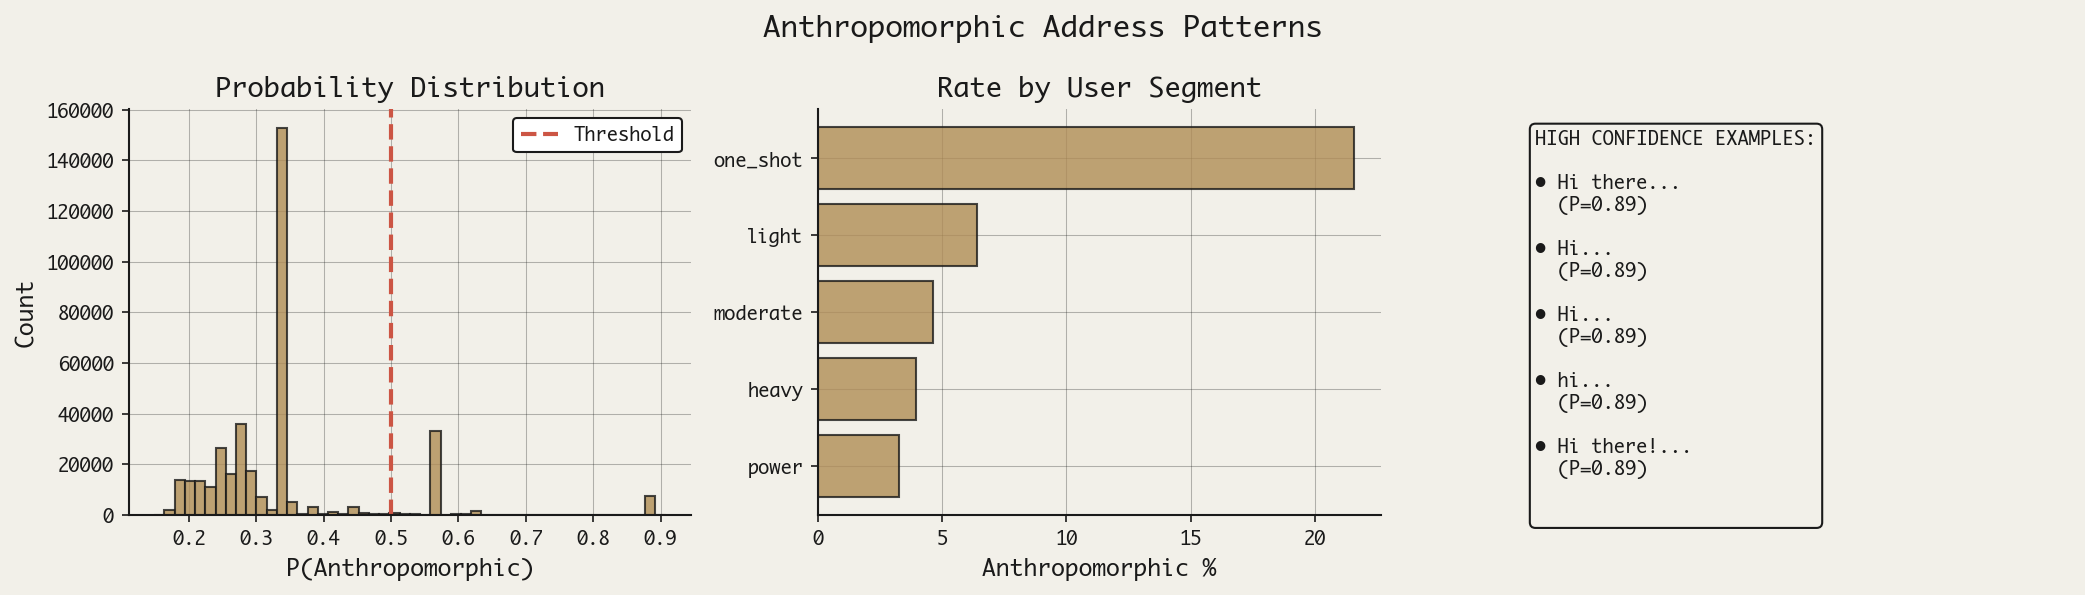


✓ Analysis complete. 'sample_with_anthro' contains predictions.


In [53]:
# ============================================================
# 7.8 Apply Classifier to Full Dataset & Analyze Patterns
# ============================================================

if 'anthro_classifier' in dir() and anthro_classifier is not None:
    print("="*70)
    print("APPLYING CLASSIFIER TO FULL DATASET")
    print("="*70)
    
    # Get English samples from the full dataset
    if 'sample_with_segment' in dir():
        full_texts = sample_with_segment['first_turn'].to_list()
        
        print(f"\nClassifying {len(full_texts):,} conversations...")
        
        # Transform and predict
        X_full = anthro_classifier['vectorizer'].transform(full_texts)
        predictions = anthro_classifier['classifier'].predict(X_full)
        probabilities = anthro_classifier['classifier'].predict_proba(X_full)[:, 1]
        
        # Add predictions to dataframe
        sample_with_anthro = sample_with_segment.with_columns([
            pl.Series('anthro_predicted', predictions),
            pl.Series('anthro_probability', probabilities)
        ])
        
        # Overall rate
        anthro_rate = predictions.mean()
        print(f"\nAnthropomorphic address rate: {anthro_rate:.1%}")
        print(f"  (Training base rate was: {anthro_classifier['base_rate']:.1%})")
        
        # By user segment
        print("\n" + "-"*70)
        print("ANTHROPOMORPHIC ADDRESS BY USER SEGMENT")
        print("-"*70)
        
        # Use user_segment (column name in this dataset)
        segment_rates = sample_with_anthro.group_by('user_segment').agg([
            pl.col('anthro_predicted').mean().alias('anthro_rate'),
            pl.col('anthro_probability').mean().alias('avg_probability'),
            pl.len().alias('n')
        ]).sort('anthro_rate', descending=True)
        
        print("\nRate by user segment:")
        for row in segment_rates.iter_rows(named=True):
            print(f"  {row['user_segment']:<12}: {row['anthro_rate']:.1%} (n={row['n']:,})")
        
        # By return status
        if 'returned' in sample_with_anthro.columns:
            print("\n" + "-"*70)
            print("ANTHROPOMORPHIC ADDRESS BY RETURN BEHAVIOR")
            print("-"*70)
            
            return_rates = sample_with_anthro.group_by('returned').agg([
                pl.col('anthro_predicted').mean().alias('anthro_rate'),
                pl.len().alias('n')
            ])
            
            for row in return_rates.iter_rows(named=True):
                status = "Returners" if row['returned'] else "One-shot"
                print(f"  {status}: {row['anthro_rate']:.1%} (n={row['n']:,})")
        
        # Visualize
        fig, axes = plt.subplots(1, 3, figsize=(14, 4))
        fig.suptitle('Anthropomorphic Address Patterns', fontsize=14, fontweight='bold', color=BRAND['ink'])
        
        # 1. Overall distribution
        ax = axes[0]
        ax.hist(probabilities, bins=50, color=BRAND['gold'], edgecolor=BRAND['ink'], alpha=0.8)
        ax.axvline(0.5, color=BRAND['alert'], linestyle='--', linewidth=2, label='Threshold')
        apply_phronos_style(ax, title='Probability Distribution', xlabel='P(Anthropomorphic)', ylabel='Count')
        ax.legend(facecolor=BRAND['white'], edgecolor=BRAND['ink'])
        
        # 2. By segment
        ax = axes[1]
        segments = segment_rates['user_segment'].to_list()
        rates = [r * 100 for r in segment_rates['anthro_rate'].to_list()]
        bars = ax.barh(segments, rates, color=BRAND['gold'], edgecolor=BRAND['ink'], alpha=0.8)
        ax.invert_yaxis()
        apply_phronos_style(ax, title='Rate by User Segment', xlabel='Anthropomorphic %', ylabel='')
        
        # 3. Example anthropomorphic messages
        ax = axes[2]
        ax.axis('off')
        high_prob = sample_with_anthro.filter(pl.col('anthro_probability') > 0.8).head(5)
        examples_text = "HIGH CONFIDENCE EXAMPLES:\n\n"
        for row in high_prob.iter_rows(named=True):
            text = row['first_turn'][:60].replace('\n', ' ')
            examples_text += f"• {text}...\n  (P={row['anthro_probability']:.2f})\n\n"
        ax.text(0.05, 0.95, examples_text, transform=ax.transAxes, fontsize=9,
                verticalalignment='top', fontfamily='monospace',
                bbox=dict(boxstyle='round', facecolor=BRAND['paper'], edgecolor=BRAND['ink']))
        
        plt.tight_layout()
        save_figure(fig, 'anthropomorphic_address_analysis')
        plt.show()
        
        print("\n✓ Analysis complete. 'sample_with_anthro' contains predictions.")
        
    else:
        print("⚠ 'sample_with_segment' not found. Run earlier cells first.")
else:
    print("⚠ Classifier not trained. Run the previous cell first.")


In [ ]:
# Cell removed - English-only sampling used instead
